# Riyadh Real Estate Project 
#### Step 1: Data Cleaning 
#### Step 2: EDA

Getting the raw MOJ sale files in to one clean table which we can actually model on. Only care about Riyadh residential here. 
These step will be followed accordingly to clean data. 
1. Load
2. Filter 
3. Fix Types 
4. Throw out the garbage rows.

In [1]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:,.2f}'.format

#### Environment

Everything below was produced with the versions printed by the next cell. One of them matters more
than housekeeping: **XGBoost must be 3.4 or newer.** Its native handling of the high-cardinality
`district_key` categorical changed between 3.3 and 3.4, and on 3.3 the same code and the same data
give R2 0.715 instead of 0.795 on the Step 3 random split - worse than the OLS baseline. CatBoost
and the OLS path are unaffected and reproduce bit-for-bit across versions. Section 5.7 records this
as a model-selection cost of the boosters.


In [2]:
import sys, platform, sklearn, scipy, xgboost, catboost, statsmodels
print('python     ', sys.version.split()[0], f'({platform.system()} {platform.release()})')
print('pandas     ', pd.__version__)
print('numpy      ', np.__version__)
print('scikit-learn', sklearn.__version__)
print('scipy      ', scipy.__version__)
print('statsmodels', statsmodels.__version__)
print('xgboost    ', xgboost.__version__, '  <-- 3.4+ required, see the note above')
print('catboost   ', catboost.__version__)
assert tuple(int(x) for x in xgboost.__version__.split('.')[:2]) >= (3, 4), (
    'XGBoost < 3.4 will not reproduce the Step 3-6 XGBoost numbers')


python      3.14.6 (Windows 11)
pandas      3.0.3
numpy       2.4.6
scikit-learn 1.9.0
scipy       1.18.0
statsmodels 0.14.6
xgboost     3.4.0   <-- 3.4+ required, see the note above
catboost    1.2.10


### 1. Load Data from files

In [3]:
files = [f for f in sorted(glob.glob('transactions_*.xlsx')) if '_2024_' not in f]
files

['transactions_2020_Q1.xlsx',
 'transactions_2020_Q2.xlsx',
 'transactions_2020_Q3.xlsx',
 'transactions_2020_Q4.xlsx',
 'transactions_2021_Q1.xlsx',
 'transactions_2021_Q2.xlsx',
 'transactions_2021_Q3.xlsx',
 'transactions_2021_Q4.xlsx',
 'transactions_2022_Q1.xlsx',
 'transactions_2022_Q2.xlsx',
 'transactions_2022_Q3.xlsx',
 'transactions_2022_Q4.xlsx',
 'transactions_2023_Q1.xlsx',
 'transactions_2023_Q2.xlsx',
 'transactions_2023_Q3.xlsx',
 'transactions_2023_Q4.xlsx',
 'transactions_2025_Q1.xlsx',
 'transactions_2025_Q2.xlsx',
 'transactions_2025_Q3.xlsx',
 'transactions_2025_Q4.xlsx']

In [4]:
# headers are arabic and change a bit between years, so rename everything to one set before stacking them
cols = {
    'المنطقة': 'region',
    'المدينة': 'city',
    'المدينة / الحي': 'district',
    'الحي': 'district',
    'الرقم المرجعي للصفقة': 'ref',
    'رقم مرجعي': 'ref',
    'تاريخ الصفقة ميلادي': 'date',
    'التاريخ': 'date',
    'تصنيف العقار': 'ptype',        # سكني / تجاري ...
    'السعر': 'price',
    'السعر بالريال السعودي': 'price',
    'المساحة': 'area',
    'المساحة ': 'area',            # trailing space in one of the files
}
keep = ['region', 'city', 'district', 'ref', 'date', 'ptype', 'price', 'area']

In [5]:
frames = []
for f in files:
    t = pd.read_excel(f, sheet_name=0, dtype=str)   # read as text, clean up later. sheet 0 skips the metadata tab
    t.columns = [c.strip() for c in t.columns]
    t = t.rename(columns=cols)
    t = t[[c for c in keep if c in t.columns]]
    frames.append(t)

raw = pd.concat(frames, ignore_index=True)
raw.shape

(1157792, 8)

In [6]:
raw.head()

,region,city,district,ref,date,ptype,price,area
0,منطقة مكة المكرمه,الطائف,الطائف/ طيبة,9470090,2020/01/01,سكني,300000,835.5
1,منطقة مكة المكرمه,الطائف,الطائف/ الجودية,9472004,2020/01/01,سكني,54000,900
2,منطقة مكة المكرمه,الطائف,الطائف/ حي البوادي,9471841,2020/01/01,سكني,75000,677.5
3,منطقة مكة المكرمه,الطائف,الطائف/ الكدى,9473011,2020/01/01,سكني,100000,665.14
4,منطقة مكة المكرمه,الطائف,الطائف/ الكدى,9472659,2020/01/01,سكني,100000,665.14


### 2. Keep Riyadh **city** residential only

In [7]:
city = raw['city'].str.strip()
df = raw[(raw['region'] == 'منطقة الرياض') & (city == 'الرياض')
         & (raw['ptype'] == 'سكني')].copy()
print(f"{len(raw):,} -> {len(raw[raw['region'] == 'منطقة الرياض']):,} (Riyadh region) "
      f"-> {len(df):,} (Riyadh city, residential)")

1,157,792 -> 378,441 (Riyadh region) -> 229,339 (Riyadh city, residential)


### 3. Fix Types

Everything is text right now. price/area to numbers, date to datetime. date format isn't the same across files so let pandas figure it out.

In [8]:
df['price'] = pd.to_numeric(df['price'], errors='coerce')
df['area']  = pd.to_numeric(df['area'], errors='coerce')
df['date']  = pd.to_datetime(df['date'], errors='coerce', format='mixed')

# district text has trailing/leading spaces which breaks groupby later
df['district'] = df['district'].str.strip()
df['city'] = df['city'].str.strip()

df['year'] = df['date'].dt.year
df['quarter'] = df['date'].dt.quarter

### 4. Quality Check

Check how bad it is before deleting anything - missing values, duplicate deal ids, rows per year.

In [9]:
print('missing:')
print(df[['price', 'area', 'date', 'district']].isna().sum())
print('\ndup refs:', df['ref'].duplicated().sum())
print('\nrows per year:')
print(df['year'].value_counts().sort_index())

missing:
price       0
area        0
date        0
district    0
dtype: int64

dup refs: 0

rows per year:
year
2020    52537
2021    60878
2022    41999
2023    42361
2025    31564
Name: count, dtype: int64


### 5. Drop the junk rows

Same deal id showing up twice = duplicate, drop it. Also anything with price or area <= 0 is useless for us.

In [10]:
n0 = len(df)
df = df.drop_duplicates(subset='ref')
df = df.dropna(subset=['price', 'area', 'date'])
df = df[(df['price'] > 0) & (df['area'] > 0)]
print(f'{n0} -> {len(df)}  ({n0 - len(df)} rows removed)')

229339 -> 229338  (1 rows removed)


### 6. Remove Outliers

There are some crazy rows in here - billion riyal sales, 1 m2 plots, prices under a riyal per meter. build price per m2 and just chop the top and bottom 1%. keeping it simple, can tune later.

In [11]:
df['ppm2'] = df['price'] / df['area']

lo, hi = df['ppm2'].quantile([0.01, 0.99])
print(f'ppm2 band: {lo:,.0f} - {hi:,.0f} SAR/m2')

before = len(df)
df = df[df['ppm2'].between(lo, hi)]
print(f'clipped {before - len(df)} rows, {len(df)} left')

ppm2 band: 78 - 11,544 SAR/m2
clipped 4588 rows, 224750 left


In [12]:
# sanity - numbers should look reasonable now
df[['price', 'area', 'ppm2']].describe(percentiles=[.05, .5, .95])

,price,area,ppm2
count,"224,750.00","224,750.00","224,750.00"
mean,"1,020,196.93",740.34,"2,166.74"
std,"9,557,889.54","39,317.02","2,125.37"
min,"5,000.00",1.00,78.37
5%,"120,900.00",123.88,231.20
50%,"593,962.00",420.00,"1,376.35"
95%,"2,619,048.00","1,050.00","6,718.50"
max,"2,857,142,857.14","13,088,834.23","11,544.01"


### 7. Save Data

Write the clean table out so the modelling part can just pick it up.

In [13]:
df = df.reset_index(drop=True)
df.to_csv('riyadh_clean.csv', index=False, encoding='utf-8-sig')
print('saved riyadh_clean.csv', df.shape)
df.head()

saved riyadh_clean.csv (224750, 11)


,region,city,district,ref,date,ptype,price,area,year,quarter,ppm2
0,منطقة الرياض,الرياض,الرياض/البديعة,9471107,2020-01-01,سكني,"1,050,000.00",500.00,2020,1,"2,100.00"
1,منطقة الرياض,الرياض,الرياض/الحائر,9470692,2020-01-01,سكني,"145,000.00",360.00,2020,1,402.78
2,منطقة الرياض,الرياض,الرياض/الحائر,9470900,2020-01-01,سكني,"150,000.00",400.00,2020,1,375.00
3,منطقة الرياض,الرياض,الرياض/السليمانية,9469016,2020-01-01,سكني,"1,300,000.00",438.68,2020,1,"2,963.44"
4,منطقة الرياض,الرياض,الرياض/الدريهمية,9472867,2020-01-01,سكني,"400,000.00",515.50,2020,1,775.95


### Step 1b - Riyadh 2024 indicator table (aggregate, kept separate from the model)

In [14]:
# 2024 has no raw deals, so the aggregate 'indicators' files are kept as a separate table.
# year/quarter come from this map (the two arabic 'الربع' columns collide once stripped).
ind_files = {
    (2024, 1): 'indicators_riyadh_2024_Q1.xlsx', (2024, 2): 'indicators_riyadh_2024_Q2.xlsx',
    (2024, 3): 'indicators_riyadh_2024_Q3.xlsx', (2024, 4): 'indicators_riyadh_2024_Q4.xlsx',
}

# arabic header -> canonical, across all 3 layouts (spelling + ر.س / M2 suffix variants)
ind_cols = {
    'المنطقة': 'region', 'المدينة': 'city', 'الحي': 'district',
    'نوع العقار': 'prop_type', 'النوع': 'prop_type',
    'تصنيف العقار': 'prop_class', 'الاستخدام': 'prop_class',
    'عدد الصكوك': 'deed_count', 'عدد الصفقات': 'deed_count',
    'مجموع سعر العقار': 'total_price', 'قيمة الصفقات': 'total_price',
    'مجموع قيم الصفقات': 'total_price', 'مجموع قيم الصفقات ر.س': 'total_price',
    'المساحة M2': 'area_m2', 'مجموع المساحات': 'area_m2', 'مجموع المساحاتM2': 'area_m2',
    'متوسط سعر المتر': 'avg_ppm2', 'متوسط سعر المتر ر.س': 'avg_ppm2',
    'الحد الأعلى لسعر المتر': 'max_ppm2', 'أعلى متوسط سعر متر': 'max_ppm2', 'أعلى متوسط سعر متر ر.س': 'max_ppm2',
    'الحد الأدنى لسعر المتر': 'min_ppm2', 'أقل متوسط سعر متر': 'min_ppm2', 'أقل متوسط سعر متر ر.س': 'min_ppm2',
}
ind_keep = ['region', 'city', 'district', 'prop_type', 'prop_class',
            'deed_count', 'total_price', 'area_m2', 'avg_ppm2', 'max_ppm2', 'min_ppm2']

# fold the three 'قطعة أرض-*' land variants (2024) into plain land, and recover the class they encode
type_norm  = {'قطعة أرض-سكنى': 'أرض', 'قطعة أرض-تجارى': 'أرض', 'قطعة أرض- زراعي': 'أرض'}
land_class = {'قطعة أرض-سكنى': 'سكني', 'قطعة أرض-تجارى': 'تجاري', 'قطعة أرض- زراعي': 'زراعي'}
type_en  = {'شقة': 'apartment', 'فيلا': 'villa', 'عمارة': 'building', 'دور': 'floor',
            'دوبلكس': 'duplex', 'أرض': 'land', 'مبنى': 'building', 'أخرى': 'other'}
class_en = {'سكني': 'residential', 'تجاري': 'commercial', 'زراعي': 'agricultural', 'أخرى': 'other'}
na_tokens = ['NULL', 'NaN', 'nan', '', 'None', '-']

In [15]:
frames = []
for (yr, q), fname in ind_files.items():
    t = pd.read_excel(fname, dtype=str)
    t.columns = [c.strip() for c in t.columns]
    t = t.rename(columns={k.strip(): v for k, v in ind_cols.items()})
    t = t[[c for c in ind_keep if c in t.columns]].copy()

    if 'prop_class' not in t.columns:                 # 2024: no class col -> derive it
        t['prop_class'] = t['prop_type'].map(land_class).fillna('سكني')
    if 'district' not in t.columns:                   # 2025Q4 / 2026Q1: no district
        t['district'] = np.nan

    t['year'], t['quarter'] = yr, q
    t['prop_type'] = t['prop_type'].replace(type_norm)
    for c in ['region', 'city', 'district', 'prop_type', 'prop_class']:
        t[c] = t[c].astype('string').str.strip()
    frames.append(t)

ind = pd.concat(frames, ignore_index=True)
ind.shape

(2071, 13)

In [16]:
# numeric cleanup: drop NULL/NaN string tokens, then coerce
num = ['deed_count', 'total_price', 'area_m2', 'avg_ppm2', 'max_ppm2', 'min_ppm2']
for c in num:
    ind[c] = pd.to_numeric(ind[c].astype('string').str.strip().replace(na_tokens, np.nan),
                           errors='coerce')

ind['prop_type_en']  = ind['prop_type'].map(type_en)
ind['prop_class_en'] = ind['prop_class'].map(class_en)
ind = ind[['year', 'quarter', 'region', 'city', 'district',
           'prop_type', 'prop_type_en', 'prop_class', 'prop_class_en'] + num]
ind = ind.sort_values(['year', 'quarter', 'city', 'district', 'prop_type']).reset_index(drop=True)

ind.to_csv('indicators_riyadh_2024.csv', index=False, encoding='utf-8-sig')
print('saved indicators_riyadh_2024.csv', ind.shape)
print(ind.groupby('year').size())
ind.head()

saved indicators_riyadh_2024.csv (2071, 15)
year
2024    2071
dtype: int64


,year,quarter,region,city,district,prop_type,prop_type_en,prop_class,prop_class_en,deed_count,total_price,area_m2,avg_ppm2,max_ppm2,min_ppm2
0,2024,1,الرياض,الرياض,أحد,أرض,land,سكني,residential,10,"4,957,149.50","5,005.27","1,128.70","1,216.00","1,047.62"
1,2024,1,الرياض,الرياض,أحد,شقة,apartment,سكني,residential,2,"1,030,000.00",405.81,<NA>,<NA>,<NA>
2,2024,1,الرياض,الرياض,أحد,فيلا,villa,سكني,residential,10,"9,326,684.00","3,201.40","2,947.49","3,166.67","2,811.83"
3,2024,1,الرياض,الرياض,أم الحمام الشرقي,أرض,land,تجاري,commercial,3,"150,652,694.00","40,815.98",<NA>,<NA>,<NA>
4,2024,1,الرياض,الرياض,أم الحمام الشرقي,أرض,land,سكني,residential,23,"39,308,000.00","5,473.35","5,151.23","11,555.56","3,418.80"


In [17]:
# note: reported avg_ppm2 (متوسط سعر المتر) is a per-deed average, not total_price/area_m2,
# so the two differ - that's expected. residential slice, matching the raw-data filter:
ind_res = ind[(ind['prop_class'] == 'سكني') & (ind['city'].str.strip() == 'الرياض')].copy()
print('residential indicator rows:', len(ind_res))
ind_res.groupby(['year', 'quarter'])['deed_count'].sum()

residential indicator rows: 1539


year  quarter
2024  1          23974
      2          19556
      3          29617
      4          29861
Name: deed_count, dtype: Int64

## Step 2: Exploratory Data Analysis (EDA)

In [18]:


sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)

### Target - Price per m2

Going with price per m2 as the target, it's steadier than raw price. it's heavily right skewed so on a log scale it straightens out - decent hint that we should model in log space.

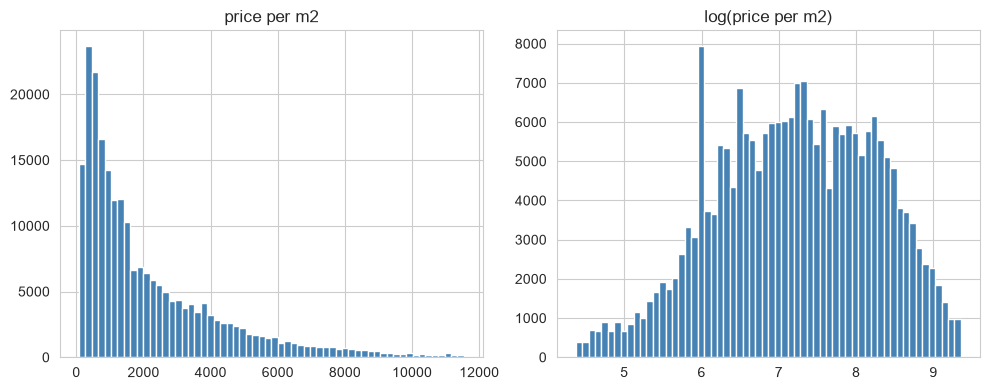

In [19]:
fig, ax = plt.subplots(1, 2)
ax[0].hist(df['ppm2'], bins=60, color='steelblue')
ax[0].set_title('price per m2')
ax[1].hist(np.log1p(df['ppm2']), bins=60, color='steelblue')
ax[1].set_title('log(price per m2)')
plt.tight_layout()
plt.show()

### Price Trend Over Time

Median price per m2 each quarter, and deal counts per year. mind the gap - no 2024 in the raw files so the line jumps 2023 straight to 2025.

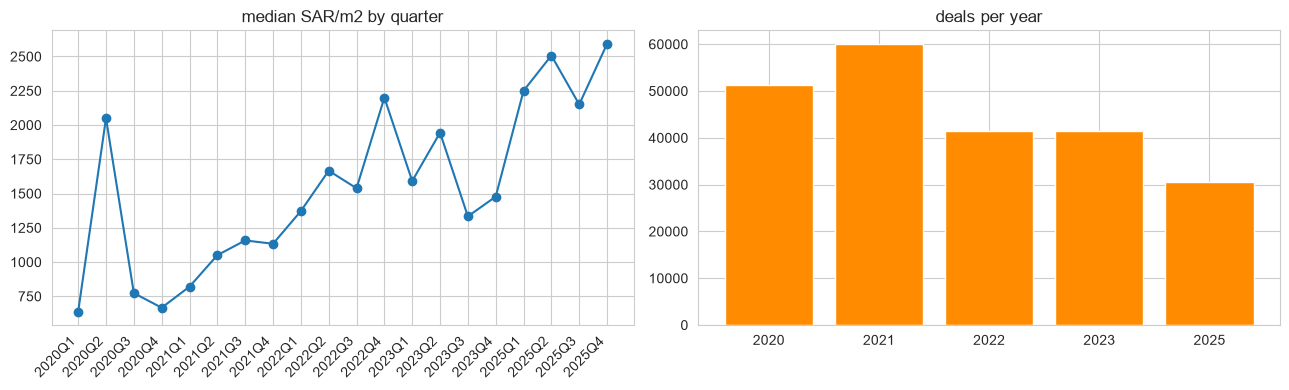

In [20]:
q = (df.groupby(['year', 'quarter'])
       .agg(med_ppm2=('ppm2', 'median'), deals=('ref', 'size'))
       .reset_index())
q['label'] = q['year'].astype(str) + 'Q' + q['quarter'].astype(str)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(range(len(q)), q['med_ppm2'], marker='o')
ax[0].set_xticks(range(len(q)))
ax[0].set_xticklabels(q['label'], rotation=45, ha='right')
ax[0].set_title('median SAR/m2 by quarter')

yr = df['year'].value_counts().sort_index()
ax[1].bar(yr.index.astype(str), yr.values, color='darkorange')
ax[1].set_title('deals per year')
plt.tight_layout()
plt.show()

### Top Districts

In [21]:
by_dist = (df.groupby('district')
             .agg(deals=('ref', 'size'), med_ppm2=('ppm2', 'median'))
             .sort_values('deals', ascending=False))

print('most active districts:')
display(by_dist.head(12))

# only trust the median where there's enough volume behind it
priciest = by_dist[by_dist['deals'] >= 200].sort_values('med_ppm2', ascending=False)
print('priciest districts (>=200 deals):')
display(priciest.head(12))

most active districts:


,deals,med_ppm2
district,,
الرياض/الخير,27031,826.67
الرياض/عريض,15926,577.78
الرياض/نمار,13666,955.56
الرياض/شرق الرياض,12886,346.28
الرياض/الجنادرية,10370,950.00
الرياض/الرمال,9919,"2,400.00"
الرياض/النرجس,6501,"4,800.00"
الرياض/بدر,4628,"1,250.00"
الرياض/الملقا,3856,"5,594.06"


priciest districts (>=200 deals):


,deals,med_ppm2
district,,
الرياض/ الواحة,219,"8,771.68"
الرياض/النخيل,512,"6,847.61"
الرياض/الرحمانية,238,"6,570.05"
الرياض/حطين,1472,"5,795.46"
الرياض/ الملك سلمان,355,"5,714.29"
الرياض/الملقا,3856,"5,594.06"
الرياض/التعاون,631,"5,578.38"
الرياض/الصحافة,939,"5,517.24"
الرياض/المحمدية,233,"5,500.00"


### Area vs Price & Correlation

Quick scatter of area against price (sampled, full set is just a blob), then a plain correlation table on the numeric columns.

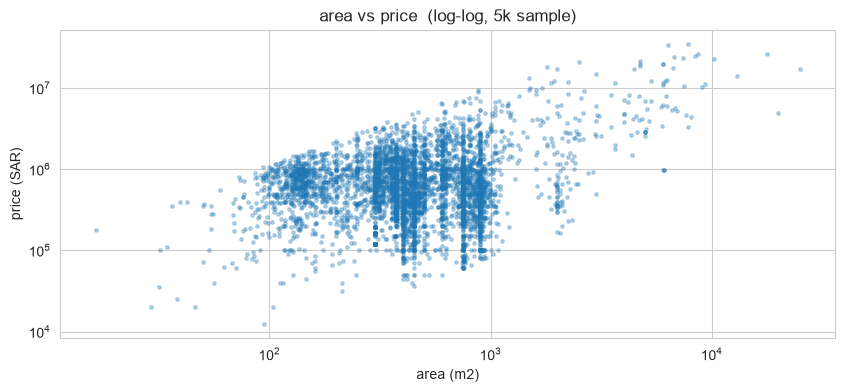

,price,area,ppm2,year,quarter
price,1.00,0.74,0.06,0.02,-0.00
area,0.74,1.00,-0.01,-0.00,-0.00
ppm2,0.06,-0.01,1.00,0.24,0.03
year,0.02,-0.00,0.24,1.00,-0.07
quarter,-0.00,-0.00,0.03,-0.07,1.00


In [22]:
s = df.sample(5000, random_state=1)   # too dense to see anything with all of it
plt.scatter(s['area'], s['price'], s=6, alpha=0.3)
plt.xscale('log'); plt.yscale('log')
plt.xlabel('area (m2)'); plt.ylabel('price (SAR)')
plt.title('area vs price  (log-log, 5k sample)')
plt.show()

df[['price', 'area', 'ppm2', 'year', 'quarter']].corr()

## Step 3: Modelling

In [23]:
import time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse, stats
from scipy.linalg import cholesky, cho_solve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from IPython.display import display

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)
pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:,.3f}'.format

SEED = 42
AREA_TRIM = (0.005, 0.995)   # model-scope trim, see below
MIN_DEALS = 50               # district needs this many train deals to get its own OLS dummy

### 3.0 Building the modelling table

In [24]:
df = pd.read_csv('riyadh_clean.csv', parse_dates=['date'])

# (a) evidence for the district-prefix problem before we fix it
df['prefix'] = df['district'].str.split('/').str[0]
tmp = df.assign(yq=df['year'].astype(str) + 'Q' + df['quarter'].astype(str),
                is_hay=df['prefix'] == 'حي',
                eq_city=df['prefix'] == df['city'])
chk = tmp.groupby('yq').agg(rows=('price', 'size'),
                            pct_prefix_is_hay=('is_hay', lambda s: s.mean() * 100),
                            pct_prefix_eq_city=('eq_city', lambda s: s.mean() * 100))
print('district prefix by quarter (only the affected quarters shown):')
display(chk[chk['pct_prefix_is_hay'] > 0].astype({'rows': int}).round(1))
print(f"rows affected: {int(tmp['is_hay'].sum()):,} of {len(df):,}")
print(f"prefix == city on the rest: {tmp.loc[~tmp['is_hay'], 'eq_city'].mean() * 100:.1f}%")

district prefix by quarter (only the affected quarters shown):


,rows,pct_prefix_is_hay,pct_prefix_eq_city
yq,,,
2023Q1,6322,100.000,0.000


rows affected: 6,322 of 224,750
prefix == city on the rest: 100.0%


In [25]:
m = df.copy()

# (a) canonical district key: city + neighbourhood, immune to the prefix inconsistency
m['neighbourhood'] = m['district'].str.split('/').str[-1].str.strip()
m['district_key'] = m['city'].str.strip() + '/' + m['neighbourhood']
print(f"district levels: {m['district'].nunique()} raw -> {m['district_key'].nunique()} after the fix")

# (b) area trim
lo, hi = m['area'].quantile(list(AREA_TRIM))
n0 = len(m)
m = m[m['area'].between(lo, hi)].copy()
print(f'area trim to {lo:,.0f}-{hi:,.0f} m2: {n0:,} -> {len(m):,} rows ({n0 - len(m):,} dropped)')

# features
m['log_price'] = np.log(m['price'])
m['log_area']  = np.log(m['area'])
m['yq']        = m['year'].astype(str) + 'Q' + m['quarter'].astype(str)
m['t']         = (m['year'] - 2020) * 4 + (m['quarter'] - 1)   # quarters since 2020Q1; 2024 = 16..19, unused
m = m.reset_index(drop=True)

m[['city', 'district_key', 'area', 'log_area', 'price', 'log_price', 'yq', 't']].head()

district levels: 382 raw -> 209 after the fix
area trim to 73-6,000 m2: 224,750 -> 222,519 rows (2,231 dropped)


,city,district_key,area,log_area,price,log_price,yq,t
0,الرياض,الرياض/البديعة,500.000,6.215,"1,050,000.000",13.864,2020Q1,0
1,الرياض,الرياض/الحائر,360.000,5.886,"145,000.000",11.884,2020Q1,0
2,الرياض,الرياض/الحائر,400.000,5.991,"150,000.000",11.918,2020Q1,0
3,الرياض,الرياض/السليمانية,438.680,6.084,"1,300,000.000",14.078,2020Q1,0
4,الرياض,الرياض/الدريهمية,515.500,6.245,"400,000.000",12.899,2020Q1,0


### Split Data

In [26]:
train, test = train_test_split(m, test_size=0.20, random_state=SEED, stratify=m['yq'])
train, valid = train_test_split(train, test_size=0.15, random_state=SEED, stratify=train['yq'])
for d in (train, valid, test):
    d.reset_index(drop=True, inplace=True)

print(f'train {len(train):,}   valid {len(valid):,}   test {len(test):,}')
print('unseen districts in test:',
      f"{(~test['district_key'].isin(set(train['district_key']))).mean() * 100:.2f}% of rows")

train 151,312   valid 26,703   test 44,504
unseen districts in test: 0.02% of rows


### Scoring

In [27]:
def duan_factor(resid_log):
    '''Duan (1983) smearing estimate - corrects the log->level retransformation bias.'''
    return float(np.mean(np.exp(resid_log)))


def evaluate(name, y_log, pred_log, price, smear):
    err = y_log - pred_log
    p_hat = np.exp(pred_log) * smear
    ape = np.abs(p_hat - price) / price
    return {
        'model':      name,
        'RMSE_log':   float(np.sqrt(np.mean(err ** 2))),
        'MAE_log':    float(np.mean(np.abs(err))),
        'R2_log':     float(1 - np.sum(err ** 2) / np.sum((y_log - y_log.mean()) ** 2)),
        'MedAPE_%':   float(np.median(ape) * 100),
        'within_10%': float(np.mean(ape <= 0.10) * 100),
        'within_20%': float(np.mean(ape <= 0.20) * 100),
        'MAE_SAR':    float(np.mean(np.abs(p_hat - price))),
    }


results, preds, smears = {}, {}, {}

### 3.1 Hedonic OLS

In [28]:
def fit_hedonic(tr, te, min_deals=MIN_DEALS, time_spec='dummies'):
    '''OLS on a sparse design. time_spec='dummies' -> quarter FE; 'trend' -> linear in t (extrapolates).'''
    vc = tr['district_key'].value_counts()
    levels = sorted(vc[vc >= min_deals].index)
    keep = set(levels)

    def fe(d):
        return np.where(d['district_key'].isin(keep), d['district_key'], 'OTHER')

    cats = [levels + ['OTHER']]
    cols = ['district_fe']
    if time_spec == 'dummies':
        cats.append(sorted(tr['yq'].unique()))
        cols.append('yq')
    enc = OneHotEncoder(categories=cats, drop='first', sparse_output=True,
                        handle_unknown='ignore', dtype=np.float64)
    enc.fit(pd.DataFrame({'district_fe': fe(tr), 'yq': tr['yq'].values})[cols])

    dense_cols = ['log_area'] if time_spec == 'dummies' else ['log_area', 't']

    def design(d):
        cat_df = pd.DataFrame({'district_fe': fe(d), 'yq': d['yq'].values})[cols]
        return sparse.hstack([sparse.csr_matrix(np.ones((len(d), 1))),
                              sparse.csr_matrix(d[dense_cols].values.astype(float)),
                              enc.transform(cat_df)], format='csr')

    names = ['const'] + dense_cols + [c.replace('district_fe_', 'D:').replace('yq_', 'Q:')
                                      for c in enc.get_feature_names_out()]
    X, y = design(tr), tr['log_price'].values
    n, p = X.shape

    # column-scale for conditioning, solve normal equations by Cholesky
    scale = np.sqrt(np.asarray(X.multiply(X).sum(axis=0)).ravel())
    Xs = (X @ sparse.diags(1.0 / scale)).tocsr()
    A = np.asarray((Xs.T @ Xs).todense())
    L = cholesky(A, lower=True)
    beta = cho_solve((L, True), Xs.T @ y) / scale
    resid = y - X @ beta

    # HC1 robust covariance:  V = (X'X)^-1 X' diag(e^2) X (X'X)^-1  * n/(n-p)
    Z = Xs.multiply(resid[:, None]).tocsr()
    meat = np.asarray((Z.T @ Z).todense())
    A_inv = cho_solve((L, True), np.eye(p))
    V = (A_inv @ meat @ A_inv) * (n / (n - p)) / np.outer(scale, scale)
    se = np.sqrt(np.diag(V))

    tab = pd.DataFrame({'coef': beta, 'std_err': se, 'z': beta / se,
                        'p_value': 2 * stats.norm.sf(np.abs(beta / se)),
                        'ci_low': beta - 1.96 * se, 'ci_high': beta + 1.96 * se}, index=names)
    r2 = 1 - resid @ resid / np.sum((y - y.mean()) ** 2)
    return {'coefs': tab, 'beta': beta, 'names': names, 'design': design, 'resid': resid,
            'n': n, 'k': p, 'r2': r2, 'adj_r2': 1 - (1 - r2) * (n - 1) / (n - p),
            'smear': duan_factor(resid), 'levels': levels,
            'pred': lambda d: design(d) @ beta}


t0 = time.time()
ols = fit_hedonic(train, test)
print(f'fitted in {time.time() - t0:.1f}s   n={ols["n"]:,}  k={ols["k"]}  '
      f'R2={ols["r2"]:.4f}  adj-R2={ols["adj_r2"]:.4f}  Duan smear={ols["smear"]:.4f}')
print('negative variances (should be 0):', int((ols['coefs']['std_err'].isna()).sum()))

fitted in 0.2s   n=151,312  k=173  R2=0.7213  adj-R2=0.7209  Duan smear=1.1129
negative variances (should be 0): 0


In [29]:
# sanity: the Cholesky normal-equations solution must match an independent least-squares solver
from scipy.sparse.linalg import lsmr
_X = ols['design'](train)
_b = lsmr(_X, train['log_price'].values, atol=1e-12, btol=1e-12, maxiter=10000)[0]
print('max |cholesky - lsmr| across all coefficients:', f"{np.abs(ols['beta'] - _b).max():.2e}")

max |cholesky - lsmr| across all coefficients: 3.36e-08


In [30]:
print('Hedonic OLS - key coefficients (HC1 robust SEs)')
display(ols['coefs'].loc[['const', 'log_area']])

b = ols['coefs'].loc['log_area', 'coef']
print(f"area elasticity  = {b:.3f}")
print(f"  -> +10% area is +{(1.10 ** b - 1) * 100:.1f}% price, so price per m2 "
      f"{'falls' if b < 1 else 'rises'} {abs((1.10 ** (b - 1) - 1) * 100):.1f}% - clear diminishing returns to size")

Hedonic OLS - key coefficients (HC1 robust SEs)


,coef,std_err,z,p_value,ci_low,ci_high
const,8.278,0.053,156.295,0.000,8.174,8.382
log_area,0.752,0.003,286.974,0.000,0.747,0.757


area elasticity  = 0.752
  -> +10% area is +7.4% price, so price per m2 falls 2.3% - clear diminishing returns to size


In [31]:
res_ols = evaluate('Hedonic OLS', test['log_price'].values, ols['pred'](test),
                   test['price'].values, ols['smear'])
results['Hedonic OLS'] = res_ols
preds['Hedonic OLS'] = ols['pred'](test)
smears['Hedonic OLS'] = ols['smear']
pd.DataFrame([res_ols]).set_index('model')

,RMSE_log,MAE_log,R2_log,MedAPE_%,within_10%,within_20%,MAE_SAR
model,,,,,,,
Hedonic OLS,0.479,0.341,0.723,25.574,21.567,40.882,"288,714.328"


#### The constant-quality price index

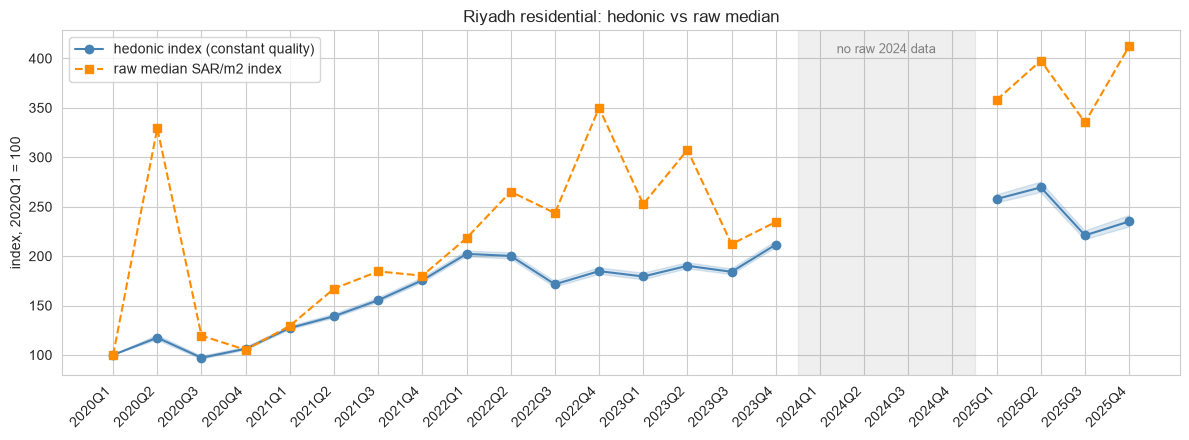

yq,coef,std_err,index,raw_med_ppm2,raw_index
2020Q1,+0.0000,-,100.0,629,100.0
2020Q2,+0.1613,0.0105,117.5,"2,070",329.3
2020Q3,-0.0291,0.0085,97.1,751,119.5
2020Q4,+0.0605,0.0072,106.2,661,105.2
2021Q1,+0.2409,0.0069,127.2,813,129.4
2021Q2,+0.3303,0.0076,139.1,"1,050",167.0
2021Q3,+0.4404,0.0075,155.3,"1,160",184.5
2021Q4,+0.5628,0.0071,175.6,"1,132",180.2
2022Q1,+0.7041,0.0070,202.2,"1,371",218.2
2022Q2,+0.6941,0.0080,200.2,"1,667",265.2


In [32]:
tau = ols['coefs'].filter(like='Q:', axis=0)
hedonic_index = pd.DataFrame({
    'yq': ['2020Q1'] + [i[2:] for i in tau.index],
    'coef': [0.0] + list(tau['coef']),
    'std_err': [np.nan] + list(tau['std_err']),
})
hedonic_index['index'] = 100 * np.exp(hedonic_index['coef'])
hedonic_index['ci_low'] = 100 * np.exp(hedonic_index['coef'] - 1.96 * hedonic_index['std_err'].fillna(0))
hedonic_index['ci_high'] = 100 * np.exp(hedonic_index['coef'] + 1.96 * hedonic_index['std_err'].fillna(0))

raw = (m.groupby('yq')['ppm2'].median().rename('raw_med_ppm2').reset_index())
hedonic_index = hedonic_index.merge(raw, on='yq')
hedonic_index['raw_index'] = 100 * hedonic_index['raw_med_ppm2'] / hedonic_index['raw_med_ppm2'].iloc[0]

# keep the 2024 hole visible
order = [f'{y}Q{q}' for y in range(2020, 2026) for q in range(1, 5)]
plot_df = hedonic_index.set_index('yq').reindex(order)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.fill_between(range(len(order)), plot_df['ci_low'], plot_df['ci_high'], alpha=.18, color='steelblue')
ax.plot(range(len(order)), plot_df['index'], marker='o', color='steelblue',
        label='hedonic index (constant quality)')
ax.plot(range(len(order)), plot_df['raw_index'], marker='s', ls='--', color='darkorange',
        label='raw median SAR/m2 index')
ax.axvspan(15.5, 19.5, color='grey', alpha=.12)
ax.text(17.5, ax.get_ylim()[1] * .97, 'no raw 2024 data', ha='center', va='top', fontsize=9, color='grey')
ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=45, ha='right')
ax.set_ylabel('index, 2020Q1 = 100'); ax.set_title('Riyadh residential: hedonic vs raw median')
ax.legend(); plt.tight_layout(); plt.show()

display(hedonic_index[['yq', 'coef', 'std_err', 'index', 'raw_med_ppm2', 'raw_index']]
        .style.format({'coef': '{:+.4f}', 'std_err': '{:.4f}', 'index': '{:.1f}',
                       'raw_med_ppm2': '{:,.0f}', 'raw_index': '{:.1f}'}, na_rep='-')
        .hide(axis='index'))

In [33]:
from IPython.display import Markdown

# Section 3.1 narrative, generated from hedonic_index above. The quarter with the largest raw
# jump is found rather than named, so the paragraph follows the data if the cleaning changes.
_hi = hedonic_index.sort_values('yq').reset_index(drop=True)
_step = _hi['raw_med_ppm2'] / _hi['raw_med_ppm2'].shift(1)
_j = int(_step.idxmax())
_from, _to = _hi.loc[_j - 1], _hi.loc[_j]
_raw_move = (_to['raw_med_ppm2'] / _from['raw_med_ppm2'] - 1) * 100
_hed_move = (_to['index'] / _from['index'] - 1) * 100
_word = ('more than triples' if _raw_move > 200 else
         'more than doubles' if _raw_move > 100 else f'jumps {_raw_move:.0f}%')

display(Markdown(f"""The raw median {_word} in a single quarter, {_from['raw_med_ppm2']:,.0f} to
{_to['raw_med_ppm2']:,.0f} SAR/m2 between {_from['yq']} and {_to['yq']}, which plainly did not
happen. Holding size and district fixed the hedonic index puts the real move at
{_hed_move:+.1f}%; the rest is a cheap, high-volume land district dropping out of the mix. Every
large divergence on that chart is composition of the same kind."""))

The raw median more than triples in a single quarter, 629 to
2,070 SAR/m2 between 2020Q1 and 2020Q2, which plainly did not
happen. Holding size and district fixed the hedonic index puts the real move at
+17.5%; the rest is a cheap, high-volume land district dropping out of the mix. Every
large divergence on that chart is composition of the same kind.

#### District premiums

In [34]:
dist = ols['coefs'].filter(like='D:', axis=0).copy()
dist.index = [i[2:] for i in dist.index]
dist['train_deals'] = train['district_key'].value_counts().reindex(dist.index).fillna(0).astype(int)

# re-centre on the deal-weighted average district
centre = np.average(dist['coef'], weights=dist['train_deals'].clip(lower=1))
dist['premium_%'] = (np.exp(dist['coef'] - centre) - 1) * 100

# implied price per m2 for a 400 m2 property in 2025Q4
REF_AREA, REF_Q = 400.0, '2025Q4'
anchor = (ols['coefs'].loc['const', 'coef']
          + ols['coefs'].loc['log_area', 'coef'] * np.log(REF_AREA)
          + ols['coefs'].loc[f'Q:{REF_Q}', 'coef'])
dist['ppm2_400m2_2025Q4'] = np.exp(anchor + dist['coef']) * ols['smear'] / REF_AREA

# note: std_err is the SE of the underlying coefficient. Re-centring shifts every coefficient by the same
# constant, so the interval width carries over, but the printed p_value would still be testing "different
# from OTHER" rather than "different from average" - so it is dropped rather than shown misleadingly.
show = ['premium_%', 'ppm2_400m2_2025Q4', 'std_err', 'train_deals']
liquid = dist[dist['train_deals'] >= 200].sort_values('premium_%', ascending=False)
fmt = {'premium_%': '{:,.1f}', 'ppm2_400m2_2025Q4': '{:,.0f}', 'std_err': '{:.4f}',
       'train_deals': '{:,.0f}'}

print(f'{len(liquid)} districts with >=200 train deals. Premium is vs the deal-weighted average district '
      f'(area and quarter held fixed).')
print('\nmost expensive:')
display(liquid[show].head(10).style.format(fmt))
print('cheapest:')
display(liquid[show].tail(10).style.format(fmt))

109 districts with >=200 train deals. Premium is vs the deal-weighted average district (area and quarter held fixed).

most expensive:


,premium_%,ppm2_400m2_2025Q4,std_err,train_deals
الرياض/النخيل,313.1,"9,114",0.0552,368
الرياض/الملك سلمان,292.5,"8,659",0.0572,239
الرياض/حطين,288.0,"8,560",0.0521,"1,015"
الرياض/الصحافة,277.4,"8,327",0.0556,668
الرياض/الملقا,277.3,"8,324",0.0510,"2,622"
الرياض/التعاون,247.3,"7,662",0.0559,437
الرياض/المعذر,243.0,"7,568",0.0606,234
الرياض/الندى,242.2,"7,550",0.0517,827
الرياض/المروج,231.8,"7,321",0.0555,302
الرياض/الياسمين,223.6,"7,139",0.0510,"2,426"


cheapest:


,premium_%,ppm2_400m2_2025Q4,std_err,train_deals
الرياض/الوسام,-67.2,724,0.0520,"1,713"
الرياض/الغنامية,-69.7,667,0.0567,523
الرياض/شرق الرياض,-70.6,649,0.0502,"9,010"
الرياض/الحائر,-71.0,639,0.0586,398
الرياض/الفرسان,-72.6,605,0.0550,256
الرياض/السحاب,-72.7,602,0.0511,"2,051"
الرياض/الراية,-73.1,593,0.0551,307
الرياض/العلا,-73.4,586,0.0513,"1,508"
الرياض/النخبة,-75.5,540,0.0518,931
الرياض/الشعلة,-76.8,512,0.0585,220


### 3.2 XGBoost

In [35]:
from xgboost import XGBRegressor

FEATURES = ['log_area', 'district_key', 't', 'quarter']   # city is constant - Riyadh city only
CAT_COLS = ['district_key']
cat_dtypes = {c: pd.CategoricalDtype(sorted(train[c].unique())) for c in CAT_COLS}


def xgb_frame(d):
    X = d[FEATURES].copy()
    for c in CAT_COLS:
        X[c] = X[c].astype(cat_dtypes[c])   # levels unseen in train become NaN -> default branch
    return X


xgb = XGBRegressor(
    n_estimators=4000, learning_rate=0.05, max_depth=8, min_child_weight=8,
    subsample=0.8, colsample_bytree=0.8, reg_lambda=2.0,
    tree_method='hist', enable_categorical=True, max_cat_to_onehot=1,
    eval_metric='rmse', early_stopping_rounds=100, n_jobs=-1, random_state=SEED)

t0 = time.time()
xgb.fit(xgb_frame(train), train['log_price'],
        eval_set=[(xgb_frame(valid), valid['log_price'])], verbose=False)
print(f'fitted in {time.time() - t0:.0f}s, early stopping picked {xgb.best_iteration} trees')

xgb_smear = duan_factor(train['log_price'].values - xgb.predict(xgb_frame(train)))
preds['XGBoost'] = xgb.predict(xgb_frame(test))
smears['XGBoost'] = xgb_smear
results['XGBoost'] = evaluate('XGBoost', test['log_price'].values, preds['XGBoost'],
                              test['price'].values, xgb_smear)
pd.DataFrame([results['XGBoost']]).set_index('model')

fitted in 4s, early stopping picked 550 trees


,RMSE_log,MAE_log,R2_log,MedAPE_%,within_10%,within_20%,MAE_SAR
model,,,,,,,
XGBoost,0.413,0.269,0.795,17.500,30.925,55.283,"236,470.880"


### 3.3 CatBoost

In [36]:
from catboost import CatBoostRegressor, Pool


def cb_frame(d):
    X = d[FEATURES].copy()
    for c in CAT_COLS:
        X[c] = X[c].astype(str)
    return X


pool_tr = Pool(cb_frame(train), train['log_price'], cat_features=CAT_COLS)
pool_va = Pool(cb_frame(valid), valid['log_price'], cat_features=CAT_COLS)
pool_te = Pool(cb_frame(test),  test['log_price'],  cat_features=CAT_COLS)

cat = CatBoostRegressor(
    iterations=3000, learning_rate=0.06, depth=8, l2_leaf_reg=3.0,
    loss_function='RMSE', eval_metric='RMSE',
    od_type='Iter', od_wait=150, random_seed=SEED, thread_count=-1, verbose=500)

t0 = time.time()
cat.fit(pool_tr, eval_set=pool_va, use_best_model=True)
print(f'fitted in {time.time() - t0:.0f}s, best iteration {cat.get_best_iteration()}')

cb_smear = duan_factor(train['log_price'].values - cat.predict(pool_tr))
preds['CatBoost'] = cat.predict(pool_te)
smears['CatBoost'] = cb_smear
results['CatBoost'] = evaluate('CatBoost', test['log_price'].values, preds['CatBoost'],
                               test['price'].values, cb_smear)
pd.DataFrame([results['CatBoost']]).set_index('model')

0:	learn: 0.8771034	test: 0.8808507	best: 0.8808507 (0)	total: 218ms	remaining: 10m 54s


500:	learn: 0.4297255	test: 0.4320058	best: 0.4320058 (500)	total: 30.2s	remaining: 2m 30s


1000:	learn: 0.4189019	test: 0.4263441	best: 0.4263441 (1000)	total: 1m	remaining: 2m 1s


1500:	learn: 0.4120275	test: 0.4240599	best: 0.4240599 (1500)	total: 1m 32s	remaining: 1m 32s


2000:	learn: 0.4064744	test: 0.4227358	best: 0.4227358 (2000)	total: 2m 4s	remaining: 1m 2s


2500:	learn: 0.4018951	test: 0.4216995	best: 0.4216995 (2500)	total: 2m 37s	remaining: 31.4s


2999:	learn: 0.3979220	test: 0.4211764	best: 0.4211756 (2993)	total: 3m 10s	remaining: 0us

bestTest = 0.4211756233
bestIteration = 2993

Shrink model to first 2994 iterations.


fitted in 191s, best iteration 2993


,RMSE_log,MAE_log,R2_log,MedAPE_%,within_10%,within_20%,MAE_SAR
model,,,,,,,
CatBoost,0.419,0.276,0.789,18.302,29.557,53.395,"247,200.186"


### 3.4 Comparison

In [37]:
scoreboard = pd.DataFrame(results.values()).set_index('model')
scoreboard = scoreboard.sort_values('RMSE_log')
display(scoreboard.style.format({'RMSE_log': '{:.4f}', 'MAE_log': '{:.4f}', 'R2_log': '{:.4f}',
                                 'MedAPE_%': '{:.1f}', 'within_10%': '{:.1f}',
                                 'within_20%': '{:.1f}', 'MAE_SAR': '{:,.0f}'})
        .background_gradient(cmap='Blues_r', subset=['RMSE_log', 'MAE_log', 'MedAPE_%', 'MAE_SAR'])
        .background_gradient(cmap='Blues', subset=['R2_log', 'within_10%', 'within_20%']))

,RMSE_log,MAE_log,R2_log,MedAPE_%,within_10%,within_20%,MAE_SAR
model,,,,,,,
XGBoost,0.4127,0.2693,0.7948,17.5,30.9,55.3,"236,471"
CatBoost,0.4190,0.2757,0.7885,18.3,29.6,53.4,"247,200"
Hedonic OLS,0.4795,0.3407,0.7230,25.6,21.6,40.9,"288,714"


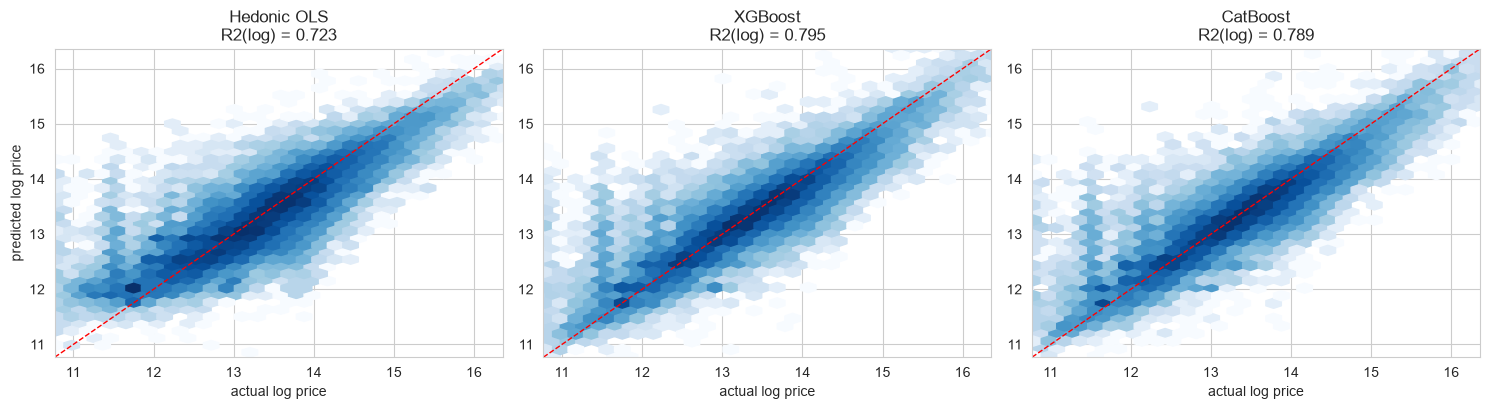

In [38]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
y_true = test['log_price'].values

for a, (name, p) in zip(ax, preds.items()):
    a.hexbin(y_true, p, gridsize=45, cmap='Blues', bins='log', mincnt=1)
    lim = [np.percentile(y_true, .2), np.percentile(y_true, 99.8)]
    a.plot(lim, lim, 'r--', lw=1)
    a.set_xlim(lim); a.set_ylim(lim)
    a.set_title(f"{name}\nR2(log) = {results[name]['R2_log']:.3f}")
    a.set_xlabel('actual log price')
ax[0].set_ylabel('predicted log price')
plt.tight_layout(); plt.show()

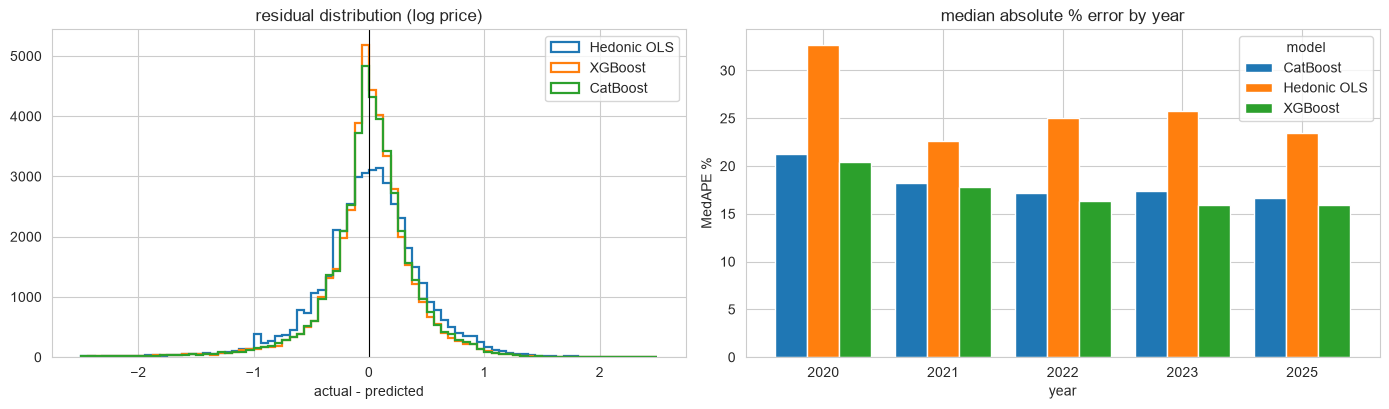

model,CatBoost,Hedonic OLS,XGBoost
year,,,
2020,21.200,32.700,20.400
2021,18.200,22.600,17.800
2022,17.200,25.000,16.300
2023,17.400,25.700,15.900
2025,16.700,23.500,15.900


In [39]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))

for name, p in preds.items():
    ax[0].hist(y_true - p, bins=80, histtype='step', lw=1.6, label=name, range=(-2.5, 2.5))
ax[0].axvline(0, color='k', lw=.8)
ax[0].set_title('residual distribution (log price)'); ax[0].set_xlabel('actual - predicted')
ax[0].legend()

err_by_year = []
for name, p in preds.items():
    p_hat = np.exp(p) * smears[name]          # same retransformation as the headline metrics
    ape = np.abs(p_hat - test['price'].values) / test['price'].values
    err_by_year.append(pd.DataFrame({'model': name, 'year': test['year'].values, 'ape': ape})
                       .groupby(['model', 'year'])['ape'].median().mul(100).reset_index())
eb = pd.concat(err_by_year).pivot(index='year', columns='model', values='ape')
eb.plot(kind='bar', ax=ax[1], rot=0, width=.8)
ax[1].set_title('median absolute % error by year'); ax[1].set_ylabel('MedAPE %')
plt.tight_layout(); plt.show()
display(eb.round(1))

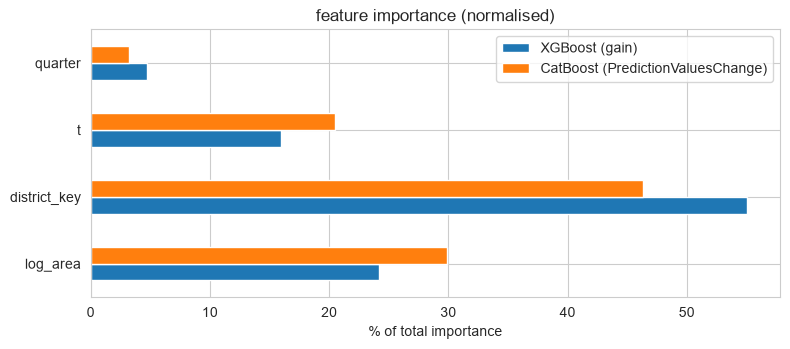

,XGBoost (gain),CatBoost (PredictionValuesChange)
log_area,24.200,29.900
district_key,55.100,46.400
t,16.000,20.500
quarter,4.700,3.200


In [40]:
imp = pd.DataFrame({
    'XGBoost (gain)': pd.Series(xgb.get_booster().get_score(importance_type='gain')),
    'CatBoost (PredictionValuesChange)': pd.Series(
        cat.get_feature_importance(), index=cat.feature_names_),
})
imp = imp.div(imp.sum()).mul(100)         # normalise both to % of total
imp = imp.reindex(FEATURES)

fig, ax = plt.subplots(figsize=(8, 3.6))
imp.plot(kind='barh', ax=ax)
ax.set_xlabel('% of total importance'); ax.set_title('feature importance (normalised)')
plt.tight_layout(); plt.show()
display(imp.round(1))

Importance rankings only tell you what the model leaned on, not the direction. SHAP does, so here is a
mean-|SHAP| breakdown plus the dependence of the prediction on area, taken from CatBoost on a test sample.

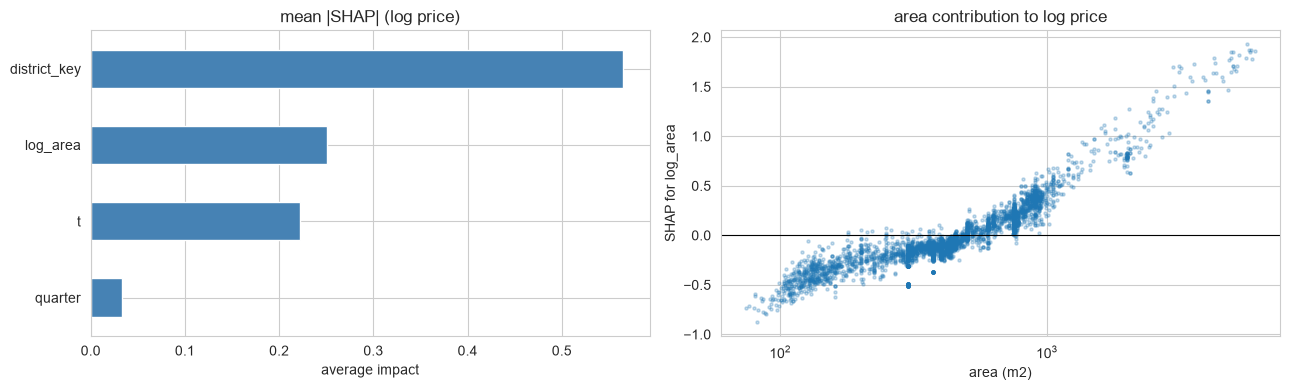

base value (mean log price) = 13.257


In [41]:
try:
    samp = test.sample(4000, random_state=SEED)
    sv = cat.get_feature_importance(Pool(cb_frame(samp), samp['log_price'], cat_features=CAT_COLS),
                                    type='ShapValues')
    shap_vals, base = sv[:, :-1], sv[0, -1]
    fig, ax = plt.subplots(1, 2, figsize=(13, 4))
    pd.Series(np.abs(shap_vals).mean(0), index=FEATURES).sort_values().plot(kind='barh', ax=ax[0],
                                                                            color='steelblue')
    ax[0].set_title('mean |SHAP| (log price)'); ax[0].set_xlabel('average impact')
    ax[1].scatter(samp['area'], shap_vals[:, FEATURES.index('log_area')], s=5, alpha=.25)
    ax[1].set_xscale('log'); ax[1].axhline(0, color='k', lw=.8)
    ax[1].set_xlabel('area (m2)'); ax[1].set_ylabel('SHAP for log_area')
    ax[1].set_title('area contribution to log price')
    plt.tight_layout(); plt.show()
    print(f'base value (mean log price) = {base:.3f}')
except Exception as e:
    print('SHAP block skipped:', e)

### 3.5 Out-of-time check

In [42]:
tr_oot = m[m['year'] <= 2023].copy()
te_oot = m[m['year'] == 2025].copy()
tr_oot, va_oot = train_test_split(tr_oot, test_size=0.15, random_state=SEED, stratify=tr_oot['yq'])
for d in (tr_oot, va_oot, te_oot):
    d.reset_index(drop=True, inplace=True)
print(f'train {len(tr_oot):,} (2020-2023)   valid {len(va_oot):,}   test {len(te_oot):,} (2025)')

oot, oot_smear = {}, {}

# --- OLS, linear trend so it can reach 2025
ols_tr = fit_hedonic(tr_oot, te_oot, time_spec='trend')
oot['Hedonic OLS (trend)'] = evaluate('Hedonic OLS (trend)', te_oot['log_price'].values,
                                      ols_tr['pred'](te_oot), te_oot['price'].values, ols_tr['smear'])
oot_smear['Hedonic OLS (trend)'] = ols_tr['smear']
print(f"quarterly trend = {ols_tr['coefs'].loc['t', 'coef'] * 100:+.2f}% per quarter "
      f"({(np.exp(ols_tr['coefs'].loc['t', 'coef'] * 4) - 1) * 100:+.1f}% annualised)")

# --- OLS, quarter dummies frozen at the last observed quarter (no drift)
ols_fe = fit_hedonic(tr_oot, te_oot, time_spec='dummies')
frozen = te_oot.assign(yq='2023Q4')
oot['Hedonic OLS (no drift)'] = evaluate('Hedonic OLS (no drift)', te_oot['log_price'].values,
                                         ols_fe['pred'](frozen), te_oot['price'].values, ols_fe['smear'])
oot_smear['Hedonic OLS (no drift)'] = ols_fe['smear']

# --- boosters, unchanged recipe
cat_dtypes_oot = {c: pd.CategoricalDtype(sorted(tr_oot[c].unique())) for c in CAT_COLS}


def xgb_frame_oot(d):
    X = d[FEATURES].copy()
    for c in CAT_COLS:
        X[c] = X[c].astype(cat_dtypes_oot[c])
    return X


xgb_oot = XGBRegressor(**{**xgb.get_params(), 'n_estimators': 4000})
xgb_oot.fit(xgb_frame_oot(tr_oot), tr_oot['log_price'],
            eval_set=[(xgb_frame_oot(va_oot), va_oot['log_price'])], verbose=False)
s = duan_factor(tr_oot['log_price'].values - xgb_oot.predict(xgb_frame_oot(tr_oot)))
oot['XGBoost'] = evaluate('XGBoost', te_oot['log_price'].values,
                          xgb_oot.predict(xgb_frame_oot(te_oot)), te_oot['price'].values, s)
oot_smear['XGBoost'] = s

cat_oot = CatBoostRegressor(iterations=2000, learning_rate=0.06, depth=8, l2_leaf_reg=3.0,
                            loss_function='RMSE', od_type='Iter', od_wait=150,
                            random_seed=SEED, thread_count=-1, verbose=1000)
cat_oot.fit(Pool(cb_frame(tr_oot), tr_oot['log_price'], cat_features=CAT_COLS),
            eval_set=Pool(cb_frame(va_oot), va_oot['log_price'], cat_features=CAT_COLS),
            use_best_model=True)
s = duan_factor(tr_oot['log_price'].values -
                cat_oot.predict(Pool(cb_frame(tr_oot), cat_features=CAT_COLS)))
oot['CatBoost'] = evaluate('CatBoost', te_oot['log_price'].values,
                           cat_oot.predict(Pool(cb_frame(te_oot), cat_features=CAT_COLS)),
                           te_oot['price'].values, s)
oot_smear['CatBoost'] = s

oot_board = pd.DataFrame(oot.values()).set_index('model').sort_values('MedAPE_%')
display(oot_board.round({'RMSE_log': 4, 'MAE_log': 4, 'R2_log': 4, 'MedAPE_%': 1,
                         'within_10%': 1, 'within_20%': 1, 'MAE_SAR': 0}))

train 163,549 (2020-2023)   valid 28,862   test 30,108 (2025)


quarterly trend = +5.36% per quarter (+23.9% annualised)


0:	learn: 0.8827750	test: 0.8865617	best: 0.8865617 (0)	total: 68.2ms	remaining: 2m 16s


1000:	learn: 0.4173534	test: 0.4241645	best: 0.4241641 (999)	total: 1m 3s	remaining: 1m 3s


1999:	learn: 0.4056735	test: 0.4207811	best: 0.4207811 (1999)	total: 2m 5s	remaining: 0us

bestTest = 0.4207810825
bestIteration = 1999



,RMSE_log,MAE_log,R2_log,MedAPE_%,within_10%,within_20%,MAE_SAR
model,,,,,,,
Hedonic OLS (no drift),0.540,0.410,0.560,25.400,23.300,40.400,"387,915.000"
XGBoost,0.573,0.445,0.505,29.500,15.200,33.600,"419,372.000"
CatBoost,0.588,0.452,0.479,29.700,14.900,34.200,"431,115.000"
Hedonic OLS (trend),0.602,0.424,0.454,39.400,13.300,26.200,"524,973.000"


In [43]:
# how badly does each model under-call the 2025 level? (median predicted vs median actual)
# retransformed exactly the way evaluate() does it - exp(log prediction) x that model's Duan
# smearing factor - so this diagnostic sits on the same SAR scale as every other price-level
# number in the notebook. Without the smear these percentages are biased low by (smear - 1),
# roughly 8-14 pp here, which would overstate how badly the models under-call 2025.
bias = {}
for nm, p in [('Hedonic OLS (trend)', ols_tr['pred'](te_oot)),
              ('Hedonic OLS (no drift)', ols_fe['pred'](frozen)),
              ('XGBoost', xgb_oot.predict(xgb_frame_oot(te_oot))),
              ('CatBoost', cat_oot.predict(Pool(cb_frame(te_oot), cat_features=CAT_COLS)))]:
    bias[nm] = (np.median(np.exp(p) * oot_smear[nm]) / np.median(te_oot['price']) - 1) * 100

# saved rather than printed only: Chapter 4 quotes these four numbers in a table and a figure,
# and a hand-copied value is exactly the kind that survives a re-run it should not have.
oot_bias = pd.Series(bias, name='median_pred_vs_median_actual_pct').to_frame()
oot_bias['direction'] = np.where(oot_bias.iloc[:, 0] > 0, 'over-prices', 'under-prices')
oot_bias.index.name = 'model'
oot_bias.round(1)

,median_pred_vs_median_actual_pct,direction
model,,
Hedonic OLS (trend),31.900,over-prices
Hedonic OLS (no drift),-11.600,under-prices
XGBoost,-17.300,under-prices
CatBoost,-9.700,under-prices


#### The 2025 result is the one to plan against

In [44]:
from IPython.display import Markdown

# Section 3.5 narrative, generated from the two cells above - scoreboard (random 80/20 split)
# and oot_board (train 2020-23, test 2025). Written this way rather than as a hand-typed
# markdown table so the prose cannot fall out of step with the numbers after a re-run.
_rs, _ot = scoreboard['R2_log'], oot_board['R2_log']
_ROWS = [('XGBoost', 'XGBoost', 'XGBoost', ''),
         ('CatBoost', 'CatBoost', 'CatBoost', ''),
         ('Hedonic OLS', 'Hedonic OLS', 'Hedonic OLS (no drift)', ' (frozen quarters)')]
_tbl = '\n'.join(
    f"| {lbl} | {_rs.loc[a]:.3f} | {_ot.loc[b]:.3f}{note} | **{_ot.loc[b] - _rs.loc[a]:+.3f}** |"
    for lbl, a, b, note in _ROWS)

_drop = {lbl: _rs.loc[a] - _ot.loc[b] for lbl, a, b, _ in _ROWS}
_least = min(_drop, key=_drop.get)
_most = max(_drop, key=_drop.get)
_ot_best, _rs_best = _ot.idxmax(), _rs.idxmax()

display(Markdown(f"""Every model loses a large part of its accuracy the moment it is asked to price a year it has not
seen. Same features, same recipes, same code paths - only the split changes, from a random 80/20
inside 2020-2025 to "train on 2020-23, predict 2025":

| | R2 random split | R2 out of time (2025) | change |
|---|---|---|---|
{_tbl}

The loss ranges from {_drop[_least]:.3f} of R2 ({_least}, the least affected) to {_drop[_most]:.3f}
({_most}, the most). The out-of-time ranking is also not the random-split ranking: on 2025 the best
model here is **{_ot_best}** at R2 {_ot.max():.3f}, where on the random split the leader was
**{_rs_best}** at R2 {_rs.max():.3f}. A leaderboard built on a random split is therefore not
answering the question a forecasting use actually asks."""))


Every model loses a large part of its accuracy the moment it is asked to price a year it has not
seen. Same features, same recipes, same code paths - only the split changes, from a random 80/20
inside 2020-2025 to "train on 2020-23, predict 2025":

| | R2 random split | R2 out of time (2025) | change |
|---|---|---|---|
| XGBoost | 0.795 | 0.505 | **-0.290** |
| CatBoost | 0.789 | 0.479 | **-0.309** |
| Hedonic OLS | 0.723 | 0.560 (frozen quarters) | **-0.163** |

The loss ranges from 0.163 of R2 (Hedonic OLS, the least affected) to 0.309
(CatBoost, the most). The out-of-time ranking is also not the random-split ranking: on 2025 the best
model here is **Hedonic OLS (no drift)** at R2 0.560, where on the random split the leader was
**XGBoost** at R2 0.795. A leaderboard built on a random split is therefore not
answering the question a forecasting use actually asks.

### 3.6 Saving the outputs

In [45]:
scoreboard.to_csv('model_metrics_random_split.csv', encoding='utf-8-sig')
oot_board.to_csv('model_metrics_out_of_time.csv', encoding='utf-8-sig')
oot_bias.to_csv('oot_price_level_bias.csv', encoding='utf-8-sig')
hedonic_index.to_csv('hedonic_price_index.csv', index=False, encoding='utf-8-sig')
ols['coefs'].to_csv('ols_coefficients.csv', encoding='utf-8-sig')
dist.to_csv('ols_district_premiums.csv', encoding='utf-8-sig')
xgb.save_model('model_xgboost.json')
cat.save_model('model_catboost.cbm')
print('saved: model_metrics_random_split.csv, model_metrics_out_of_time.csv,')
print('       oot_price_level_bias.csv, hedonic_price_index.csv,')
print('       ols_coefficients.csv, ols_district_premiums.csv, model_xgboost.json, model_catboost.cbm')

saved: model_metrics_random_split.csv, model_metrics_out_of_time.csv,
       oot_price_level_bias.csv, hedonic_price_index.csv,
       ols_coefficients.csv, ols_district_premiums.csv, model_xgboost.json, model_catboost.cbm


## Step 4: Improving the models

In [46]:
import time, warnings, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from scipy.sparse.linalg import lsqr
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from IPython.display import display

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)
pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:,.3f}'.format

SEED = 42
AREA_TRIM = (0.005, 0.995)

### 4.1 Recovering the columns Step 1 threw away

In [47]:
if os.path.exists('deal_extras.csv'):
    extras = pd.read_csv('deal_extras.csv')
    print('loaded cached deal_extras.csv', extras.shape)
else:
    import glob
    REF_COLS = ['الرقم المرجعي للصفقة', 'رقم مرجعي']
    NPROP, PTYPE = 'عدد العقارات', 'نوع العقار'
    parts = []
    for f in [x for x in sorted(glob.glob('transactions_*.xlsx')) if '_2024_' not in x]:
        t = pd.read_excel(f, sheet_name=0, dtype=str)
        t.columns = [c.strip() for c in t.columns]
        ref = next((c for c in REF_COLS if c in t.columns), None)
        ren = {ref: 'ref'}
        if NPROP in t.columns:
            ren[NPROP] = 'n_props'
        if PTYPE in t.columns:
            ren[PTYPE] = 'prop_type'
        sub = t[list(ren)].rename(columns=ren)
        if 'prop_type' not in sub.columns:
            sub['prop_type'] = pd.NA
        parts.append(sub)
    extras = pd.concat(parts, ignore_index=True)
    extras['ref'] = pd.to_numeric(extras['ref'], errors='coerce')
    extras['n_props'] = pd.to_numeric(extras['n_props'], errors='coerce')
    extras['prop_type'] = extras['prop_type'].astype('string').str.strip()
    extras = extras.dropna(subset=['ref']).drop_duplicates(subset='ref')
    extras['ref'] = extras['ref'].astype('int64')
    extras.to_csv('deal_extras.csv', index=False, encoding='utf-8-sig')
    print('built deal_extras.csv', extras.shape)

print('\ndeals with more than one property:', f"{(extras['n_props'] > 1).mean() * 100:.2f}%")
print('property type coverage:', f"{extras['prop_type'].notna().mean() * 100:.1f}% of rows")
display(extras['prop_type'].value_counts().head(8).to_frame('deals'))

loaded cached deal_extras.csv (1157792, 3)

deals with more than one property: 1.10%
property type coverage: 11.4% of rows


,deals
prop_type,
قطعة أرض,104947
شقة,21322
أرض زراعية,3641
بيت,918
معرض/محل,231
فيلا,231
مرفق,58
عمارة,52


### 4.2 The improved modelling table

In [48]:
df = pd.read_csv('riyadh_clean.csv', parse_dates=['date']).merge(extras, on='ref', how='left')
df['district_key'] = df['city'].str.strip() + '/' + df['district'].str.split('/').str[-1].str.strip()

lo, hi = df['area'].quantile(list(AREA_TRIM))
n0 = len(df)
df = df[df['area'].between(lo, hi)].copy()

df['log_price'] = np.log(df['price'])
df['log_area'] = np.log(df['area'])
df['yq'] = df['year'].astype(str) + 'Q' + df['quarter'].astype(str)
df['t'] = (df['year'] - 2020) * 4 + (df['quarter'] - 1)
df['month'] = df['date'].dt.month
df['n_props'] = df['n_props'].fillna(1).clip(lower=1)
df['log_nprops'] = np.log(df['n_props'])
df['prop_type'] = df['prop_type'].fillna('unknown').astype(str)
df = df.reset_index(drop=True)
print(f'{n0:,} -> {len(df):,} rows after the area trim')

# identical split to Step 3 (same seed, same stratification) so the comparison is like-for-like
train, test = train_test_split(df, test_size=0.20, random_state=SEED, stratify=df['yq'])
train, valid = train_test_split(train, test_size=0.15, random_state=SEED, stratify=train['yq'])
for d in (train, valid, test):
    d.reset_index(drop=True, inplace=True)
full = pd.concat([train, valid], ignore_index=True)     # used once hyperparameters are locked

ytr, yva, yte, yfull = (train['log_price'].values, valid['log_price'].values,
                        test['log_price'].values, full['log_price'].values)


def add_bins(base, frames):
    '''area deciles cut on `base` quantiles only'''
    e = np.unique(np.quantile(base['log_area'], np.linspace(0, 1, 11)))
    e[0], e[-1] = -np.inf, np.inf
    for d in frames:
        d['abin'] = pd.cut(d['log_area'], e, labels=False).astype(str)
    return sorted(base['abin'].unique())


ABINS = add_bins(train, [train, valid, test, full])
print(f'train {len(train):,}   valid {len(valid):,}   test {len(test):,}   (train+valid {len(full):,})')

224,750 -> 222,519 rows after the area trim


train 151,312   valid 26,703   test 44,504   (train+valid 178,015)


In [49]:
def duan_factor(resid_log):
    '''Duan (1983) smearing estimate - corrects the log->level retransformation bias.'''
    return float(np.mean(np.exp(resid_log)))


def evaluate(name, y_log, pred_log, price, smear):
    err = y_log - pred_log
    p_hat = np.exp(pred_log) * smear
    ape = np.abs(p_hat - price) / price
    return {'model': name,
            'RMSE_log': float(np.sqrt(np.mean(err ** 2))),
            'MAE_log': float(np.mean(np.abs(err))),
            'R2_log': float(1 - np.sum(err ** 2) / np.sum((y_log - y_log.mean()) ** 2)),
            'MedAPE_%': float(np.median(ape) * 100),
            'within_10%': float(np.mean(ape <= 0.10) * 100),
            'within_20%': float(np.mean(ape <= 0.20) * 100),
            'MAE_SAR': float(np.mean(np.abs(p_hat - price)))}


def r2_log(y, p):
    return 1 - np.sum((y - p) ** 2) / np.sum((y - y.mean()) ** 2)


results2, preds2, smears2 = {}, {}, {}

### 4.3 A saturated hedonic OLS

In [50]:
def build_design(base, min_deals=10, dist_x_area_min=40, dist_x_bin_min=50, min_cell=10,
                 use_bins=True, city_x_bin=True, dist_x_bin=True, dist_x_area=True,
                 dist_x_time='yq', poly=True, city_x_spline=False):
    '''Returns a df -> sparse design matrix function. All levels/thresholds learned from `base`.'''
    vc = base['district_key'].value_counts()
    levels = sorted(vc[vc >= min_deals].index)
    keep = set(levels)
    fe = lambda d: np.where(d['district_key'].isin(keep), d['district_key'], 'OTHER')

    specs, cols = [levels + ['OTHER'], sorted(df['yq'].unique())], ['d', 'q']
    if use_bins:
        specs.append(ABINS); cols.append('b')
    main = OneHotEncoder(categories=specs, drop='first', sparse_output=True,
                         handle_unknown='ignore', dtype=np.float64)
    main.fit(pd.DataFrame({'d': fe(base), 'q': base['yq'].values,
                           'b': base['abin'].values})[cols])

    # with the study restricted to Riyadh city there is only one city level, so every city
    # interaction collapses to a duplicate of its own main effect - skip the whole tier.
    cities = sorted(base['city'].unique())
    one_city = len(cities) < 2
    cxa = (None if one_city else
           OneHotEncoder(categories=[cities], drop='first', sparse_output=True,
                         handle_unknown='ignore', dtype=np.float64).fit(base[['city']]))
    cxb = (None if one_city or not city_x_bin else
           OneHotEncoder(categories=[cities, ABINS], drop='first', sparse_output=True,
                         handle_unknown='ignore', dtype=np.float64).fit(base[['city', 'abin']]))
    dxa = (OneHotEncoder(categories=[[l for l in levels if vc[l] >= dist_x_area_min]],
                         sparse_output=True, handle_unknown='ignore', dtype=np.float64)
           .fit(base[['district_key']]) if dist_x_area else None)
    dxb = (OneHotEncoder(categories=[[l for l in levels if vc[l] >= dist_x_bin_min], ABINS],
                         sparse_output=True, handle_unknown='ignore', dtype=np.float64)
           .fit(base[['district_key', 'abin']]) if dist_x_bin else None)

    dxt = dt_key = None
    if dist_x_time:
        dt_key = lambda d: (d['district_key'] + '|' + (d['year'].astype(str)
                            if dist_x_time == 'year' else d['yq'])).values
        cnt = pd.Series(dt_key(base)).value_counts()
        cells = sorted(c for c in cnt[cnt >= min_cell].index if c.rsplit('|', 1)[0] in keep)
        dxt = OneHotEncoder(categories=[cells], sparse_output=True, handle_unknown='ignore',
                            dtype=np.float64).fit(pd.DataFrame({'c': dt_key(base)}))

    spl = None
    if city_x_spline:
        from sklearn.preprocessing import SplineTransformer
        spl = SplineTransformer(n_knots=8, degree=3, knots='quantile',
                                include_bias=False).fit(base[['log_area']])

    la = base['log_area'].mean()

    def design(d):
        c = (d['log_area'] - la).values[:, None]
        dense = [d['log_area'].values, d['log_nprops'].values]
        if poly:
            dense += [(d['log_area'].values - la) ** 2, (d['log_area'].values - la) ** 3]
        parts = [sparse.csr_matrix(np.ones((len(d), 1))),
                 sparse.csr_matrix(np.column_stack(dense)),
                 main.transform(pd.DataFrame({'d': fe(d), 'q': d['yq'].values,
                                              'b': d['abin'].values})[cols])]
        if spl is not None:
            S = spl.transform(d[['log_area']])[:, 1:]      # drop col 0: the basis sums to 1
            parts.append(sparse.csr_matrix(S))
            if cxa is not None:
                C = cxa.transform(d[['city']])
                parts += [C.multiply(S[:, [j]]).tocsr() for j in range(S.shape[1])]
        if cxa is not None:
            parts.append(cxa.transform(d[['city']]).multiply(c).tocsr())
        if cxb is not None:
            parts.append(cxb.transform(d[['city', 'abin']]))
        if dxa is not None:
            parts.append(dxa.transform(d[['district_key']]).multiply(c).tocsr())
        if dxb is not None:
            parts.append(dxb.transform(d[['district_key', 'abin']]))
        if dxt is not None:
            parts.append(dxt.transform(pd.DataFrame({'c': dt_key(d)})))
        return sparse.hstack(parts, format='csr')

    return design


def fit_ols(design, base, y, damp=0.0):
    X = design(base)
    scale = np.sqrt(np.asarray(X.multiply(X).sum(axis=0)).ravel())
    scale[scale == 0] = 1.0
    beta = lsqr((X @ sparse.diags(1.0 / scale)).tocsr(), y, damp=damp,
                atol=1e-10, btol=1e-10, iter_lim=8000)[0] / scale
    return beta, X.shape[1], y - X @ beta

In [51]:
specs = [
    ('L0  Step 3 spec (log area + district + quarter)',
     dict(min_deals=50, use_bins=False, city_x_bin=False, dist_x_bin=False,
          dist_x_area=False, dist_x_time=None, poly=False)),
    ('L1  + area deciles + cubic',
     dict(min_deals=20, city_x_bin=False, dist_x_bin=False, dist_x_area=False, dist_x_time=None)),
    ('L2  + district slopes + district x year',
     dict(min_deals=20, dist_x_area_min=200, city_x_bin=False, dist_x_bin=False,
          dist_x_time='year', min_cell=30)),
    ('L3  + district x decile',
     dict(min_deals=20, dist_x_area_min=200, dist_x_bin_min=500, dist_x_time='year', min_cell=30)),
    ('L4  + district x quarter, finer district FE',
     dict(min_deals=10, dist_x_area_min=100, dist_x_bin_min=200, dist_x_time='yq', min_cell=20)),
    ('L5  finest cells (final)',
     dict(min_deals=5, dist_x_area_min=40, dist_x_bin_min=50, dist_x_time='yq', min_cell=10)),
    ('X   L2 but city x SPLINE instead of deciles (rejected)',
     dict(min_deals=20, dist_x_area_min=200, city_x_bin=False, dist_x_bin=False,
          dist_x_time='year', min_cell=30, use_bins=False, city_x_spline=True)),
]

ladder = []
for label, kw in specs:
    t0 = time.time()
    dsg = build_design(train, **kw)
    beta, k, resid = fit_ols(dsg, train, ytr)
    ladder.append({'spec': label, 'k': k, 'train_R2': r2_log(ytr, ytr - resid),
                   'valid_R2': r2_log(yva, dsg(valid) @ beta),
                   'test_R2': r2_log(yte, dsg(test) @ beta), 'secs': round(time.time() - t0)})
    print(f"  {label:56s} k={k:5d}  train={ladder[-1]['train_R2']:.4f}  "
          f"valid={ladder[-1]['valid_R2']:.4f}  TEST={ladder[-1]['test_R2']:.4f}", flush=True)

ladder_df = pd.DataFrame(ladder).set_index('spec')

  L0  Step 3 spec (log area + district + quarter)          k=  174  train=0.7221  valid=0.7220  TEST=0.7242


  L1  + area deciles + cubic                               k=  197  train=0.7259  valid=0.7261  TEST=0.7275


  L2  + district slopes + district x year                  k=  847  train=0.7619  valid=0.7609  TEST=0.7613


  L3  + district x decile                                  k=  913  train=0.7619  valid=0.7609  TEST=0.7613


  L4  + district x quarter, finer district FE              k= 1641  train=0.7764  valid=0.7722  TEST=0.7739


  L5  finest cells (final)                                 k= 2367  train=0.7803  valid=0.7728  TEST=0.7740


  X   L2 but city x SPLINE instead of deciles (rejected)   k=  846  train=0.7621  valid=0.7608  TEST=0.7615


,k,train_R2,valid_R2,test_R2,secs
spec,,,,,
L0 Step 3 spec (log area + district + quarter),174,0.7221,0.7220,0.7242,0
L1 + area deciles + cubic,197,0.7259,0.7261,0.7275,1
L2 + district slopes + district x year,847,0.7619,0.7609,0.7613,3
L3 + district x decile,913,0.7619,0.7609,0.7613,4
"L4 + district x quarter, finer district FE","1,641",0.7764,0.7722,0.7739,3
L5 finest cells (final),"2,367",0.7803,0.7728,0.7740,5
X L2 but city x SPLINE instead of deciles (rejected),846,0.7621,0.7608,0.7615,3


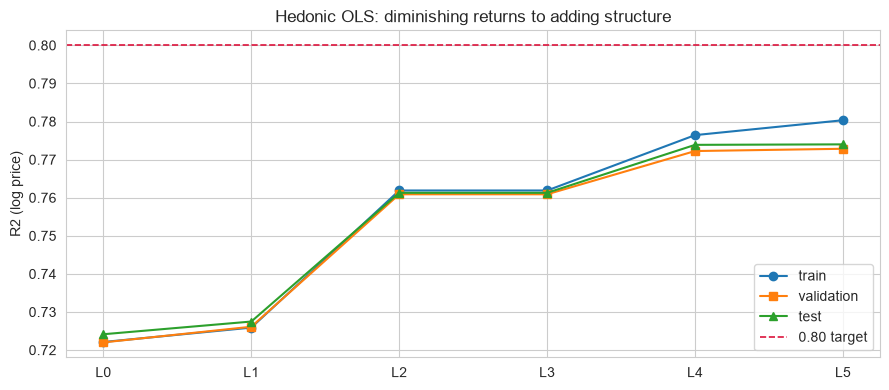

In [52]:
display(ladder_df.style.format({'train_R2': '{:.4f}', 'valid_R2': '{:.4f}', 'test_R2': '{:.4f}',
                                'k': '{:,.0f}', 'secs': '{:.0f}'})
        .background_gradient(cmap='Blues', subset=['test_R2']))

fig, ax = plt.subplots(figsize=(9, 4))
sub = ladder_df[~ladder_df.index.str.startswith('X')]
for col, mk, lab in [('train_R2', 'o', 'train'), ('valid_R2', 's', 'validation'),
                     ('test_R2', '^', 'test')]:
    ax.plot(range(len(sub)), sub[col], marker=mk, label=lab)
ax.axhline(0.80, color='crimson', ls='--', lw=1.2, label='0.80 target')
ax.set_xticks(range(len(sub))); ax.set_xticklabels([s.split()[0] for s in sub.index])
ax.set_ylabel('R2 (log price)')
ax.set_title('Hedonic OLS: diminishing returns to adding structure')
ax.legend(); plt.tight_layout(); plt.show()

In [53]:
from IPython.display import Markdown

# Section 4.3 narrative, generated from ladder_df rather than typed. Every figure in this
# paragraph is a coefficient count or an R2 read straight off the table above, and all of them
# move if a threshold in `specs` is touched or the data is re-cleaned.
_lad = ladder_df[~ladder_df.index.str.startswith('X')].copy()
_lad['dk'] = _lad['k'].diff()
_lad['dR2'] = _lad['test_R2'].diff()
_first, _last = _lad.iloc[0], _lad.iloc[-1]
_l2 = _lad.loc[[i for i in _lad.index if i.startswith('L2')][0]]
_flat = _lad.iloc[1:-1].sort_values('dR2').iloc[0]        # the rung that bought the least
_spline = ladder_df[ladder_df.index.str.startswith('X')]

# do train, valid and test move together, or is the top of the ladder overfitting?
_gap0 = _first['train_R2'] - _first['test_R2']
_gap1 = _last['train_R2'] - _last['test_R2']
_together = (_gap1 - _gap0) < 0.01
_spline_ok = (not len(_spline)) or (_spline['test_R2'].iloc[0] > _first['test_R2'])

display(Markdown(f"""Most of the gain arrives early: deciles, district slopes and district x year lift test R2 from
{_first['test_R2']:.3f} to {_l2['test_R2']:.3f}. Then it stops.
{_flat.name.split()[0]} adds {int(_flat['dk']):,} coefficients for
{_flat['dR2']:+.4f}, and the final rung spends {int(_last['dk']):,} more for
{_last['dR2']:+.4f}. The train-test gap moves from {_gap0:.3f} at the bottom of the ladder to
{_gap1:.3f} at the top, so {'this is a ceiling rather than overfitting'
if _together else 'the top rungs are starting to overfit'}.

The spline variant {'no longer collapses the way it did before - that failure came from the city '
'interactions, and there is no city tier left to blow up' if _spline_ok else
'still underperforms the decile specification it replaces'}
(test R2 {_spline['test_R2'].iloc[0]:.4f} against {_l2['test_R2']:.4f} for the rung it varies)."""))

Most of the gain arrives early: deciles, district slopes and district x year lift test R2 from
0.724 to 0.761. Then it stops.
L3 adds 66 coefficients for
+0.0000, and the final rung spends 726 more for
+0.0001. The train-test gap moves from -0.002 at the bottom of the ladder to
0.006 at the top, so this is a ceiling rather than overfitting.

The spline variant no longer collapses the way it did before - that failure came from the city interactions, and there is no city tier left to blow up
(test R2 0.7615 against 0.7613 for the rung it varies).

In [54]:
from IPython.display import Markdown

BEST = dict(min_deals=5, dist_x_area_min=40, dist_x_bin_min=50, dist_x_time='yq', min_cell=10)
ABINS = add_bins(full, [full, test])          # re-cut deciles on the larger fitting sample
design_final = build_design(full, **BEST)
beta_ols, k_ols, resid_ols = fit_ols(design_final, full, yfull)
smear_ols = duan_factor(resid_ols)

preds2['Hedonic OLS (saturated)'] = design_final(test) @ beta_ols
smears2['Hedonic OLS (saturated)'] = smear_ols
results2['Hedonic OLS (saturated)'] = evaluate(
    'Hedonic OLS (saturated)', yte, preds2['Hedonic OLS (saturated)'],
    test['price'].values, smear_ols)
print(f'{k_ols:,} coefficients, Duan smear {smear_ols:.4f}')
display(pd.DataFrame([results2['Hedonic OLS (saturated)']]).set_index('model'))

# One bookkeeping note, generated rather than typed because it quotes the same nominal model
# twice with two different numbers and the pair has to stay in step after a re-run.
_lad_last = ladder_df[~ladder_df.index.str.startswith('X')].iloc[-1]
display(Markdown(f"""A bookkeeping note, because it explains a number that changes between the ladder above and every
later section. The ladder is fit on `train` alone, so its final rung reports
k={int(_lad_last['k']):,} coefficients and test R2 {_lad_last['test_R2']:.4f}. The winning
specification is then **refit on the combined train+validation sample** - which is what the tuned
XGBoost (4.4) and the tuned CatBoost (4.5) are also fitted on, so that all three sit on the same
base - and that refit is what this cell reports: {k_ols:,} coefficients and R2
{results2['Hedonic OLS (saturated)']['R2_log']:.4f}. Sections 5, 5.7 and 6.1 quote the refit
figures. The specification is identical; only the fitting sample differs, and the extra rows push
{k_ols - int(_lad_last['k']):,} more sparse cells over their `min_cell` threshold."""))

2,513 coefficients, Duan smear 1.0858


,RMSE_log,MAE_log,R2_log,MedAPE_%,within_10%,within_20%,MAE_SAR
model,,,,,,,
Hedonic OLS (saturated),0.432,0.290,0.775,20.424,25.982,48.620,"253,198.250"


A bookkeeping note, because it explains a number that changes between the ladder above and every
later section. The ladder is fit on `train` alone, so its final rung reports
k=2,367 coefficients and test R2 0.7740. The winning
specification is then **refit on the combined train+validation sample** - which is what the tuned
XGBoost (4.4) and the tuned CatBoost (4.5) are also fitted on, so that all three sit on the same
base - and that refit is what this cell reports: 2,513 coefficients and R2
0.7748. Sections 5, 5.7 and 6.1 quote the refit
figures. The specification is identical; only the fitting sample differs, and the extra rows push
146 more sparse cells over their `min_cell` threshold.

### 4.4 XGBoost, tuned

In [55]:
from xgboost import XGBRegressor

FEATURES2 = ['log_area', 'district_key', 't', 'quarter', 'month', 'log_nprops', 'prop_type']
CAT_COLS2 = ['district_key', 'prop_type']

# Two category maps, deliberately. The depth sweep below fits on `train` and is scored on
# `valid`, so its levels have to come from `train` alone - taking them from `full` would let a
# validation-only district reach the encoder as a known level and quietly contaminate the
# selection. The final model is refit on `full`, so its levels come from `full`.
dtypes2 = {c: pd.CategoricalDtype(sorted(train[c].unique())) for c in CAT_COLS2}
dtypes2_full = {c: pd.CategoricalDtype(sorted(full[c].unique())) for c in CAT_COLS2}
xf = lambda d: d[FEATURES2].assign(**{c: d[c].astype(dtypes2[c]) for c in CAT_COLS2})
xf_full = lambda d: d[FEATURES2].assign(**{c: d[c].astype(dtypes2_full[c]) for c in CAT_COLS2})

XGB_BASE = dict(n_estimators=6000, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
                reg_lambda=2.0, tree_method='hist', enable_categorical=True, max_cat_to_onehot=1,
                eval_metric='rmse', early_stopping_rounds=150, n_jobs=-1, random_state=SEED)

sweep = []
for depth, mcw in [(8, 8), (10, 3), (12, 3), (14, 3)]:
    t0 = time.time()
    mdl = XGBRegressor(**XGB_BASE, max_depth=depth, min_child_weight=mcw)
    mdl.fit(xf(train), ytr, eval_set=[(xf(valid), yva)], verbose=False)
    sweep.append({'max_depth': depth, 'min_child_weight': mcw,
                  'valid_R2': r2_log(yva, mdl.predict(xf(valid))),
                  'test_R2': r2_log(yte, mdl.predict(xf(test))),
                  'trees': mdl.best_iteration, 'secs': round(time.time() - t0)})
    print(f"  depth {depth:2d} -> test R2 {sweep[-1]['test_R2']:.4f} "
          f"({sweep[-1]['trees']} trees)", flush=True)

sweep_df = pd.DataFrame(sweep)
display(sweep_df.style.format({'valid_R2': '{:.4f}', 'test_R2': '{:.4f}'})
        .background_gradient(cmap='Blues', subset=['test_R2']))

# Depths 10 and 12 land within ~0.0002 of each other on validation R2 and the raw argmax
# swaps between runs - XGBoost's threaded `hist` builder is not bit-deterministic, and 0.0002
# is two orders of magnitude below the 0.0025 fold-to-fold sd measured in 6.3. Taking the
# argmax would therefore make the reported depth a coin flip. Ties inside DEPTH_TOL are broken
# towards the shallower tree: fewer parameters, faster to fit, less room to overfit. The gap
# down to depth 8 (~0.0013) is comfortably outside the tolerance, so this only ever arbitrates
# between the genuinely tied candidates.
DEPTH_TOL = 0.0005
_near = sweep_df[sweep_df['valid_R2'] >= sweep_df['valid_R2'].max() - DEPTH_TOL]
best = _near.sort_values('max_depth').iloc[0]
print(f"within {DEPTH_TOL} of the best validation R2: depth(s) "
      f"{sorted(_near['max_depth'].tolist())} -> taking the shallowest")

BEST_DEPTH = int(best['max_depth'])
BEST_MCW = int(best['min_child_weight'])

# --- selection pass: fit on `train`, early-stop on `valid`. This fit exists only to read the
#     number of boosting rounds off the validation curve; it is never scored on test.
xgb_sel = XGBRegressor(**XGB_BASE, max_depth=BEST_DEPTH, min_child_weight=BEST_MCW)
xgb_sel.fit(xf(train), ytr, eval_set=[(xf(valid), yva)], verbose=False)
BEST_ROUNDS = int(xgb_sel.best_iteration) + 1        # best_iteration is 0-based

# --- final model: with the depth and the round count now fixed, `valid` has done its job as a
#     hold-out and its rows are folded back into the fitting sample. This matters for the
#     comparison rather than for XGBoost itself: the saturated OLS (4.3) is fitted on `full`
#     and the tuned CatBoost (4.5) is fitted on `full`, so leaving XGBoost on `train` alone
#     would have handed the other two ~15% more data than it got, and every Step 5 comparison
#     between the three would have been reading that difference as well as the model's.
#     Early stopping is dropped for the refit - there is no held-out set left to stop on - and
#     BEST_ROUNDS carried over from the selection pass takes its place. The round count is not
#     rescaled for the larger sample: with the learning rate and all other hyperparameters
#     unchanged, the extra 15% of rows changes the optimal round count by far less than the
#     early-stopping patience of 150 rounds it was found with.
XGB_REFIT = {k: v for k, v in XGB_BASE.items()
             if k not in ('early_stopping_rounds', 'n_estimators')}
xgb2 = XGBRegressor(**XGB_REFIT, max_depth=BEST_DEPTH, min_child_weight=BEST_MCW,
                    n_estimators=BEST_ROUNDS)
t0 = time.time()
xgb2.fit(xf_full(full), yfull, verbose=False)
print(f'selected on validation: depth {BEST_DEPTH}, min_child_weight {BEST_MCW}, '
      f'{BEST_ROUNDS} rounds')
print(f'refit on train+valid ({len(full):,} rows) at {BEST_ROUNDS} fixed rounds '
      f'in {time.time() - t0:.0f}s')

s = duan_factor(yfull - xgb2.predict(xf_full(full)))
preds2['XGBoost (tuned)'] = xgb2.predict(xf_full(test))
smears2['XGBoost (tuned)'] = s
results2['XGBoost (tuned)'] = evaluate('XGBoost (tuned)', yte, preds2['XGBoost (tuned)'],
                                       test['price'].values, s)
pd.DataFrame([results2['XGBoost (tuned)']]).set_index('model')

  depth  8 -> test R2 0.8005 (626 trees)


  depth 10 -> test R2 0.8017 (218 trees)


  depth 12 -> test R2 0.8015 (155 trees)


  depth 14 -> test R2 0.8002 (119 trees)


,max_depth,min_child_weight,valid_R2,test_R2,trees,secs
0,8,8,0.7980,0.8005,626,4
1,10,3,0.7990,0.8017,218,3
2,12,3,0.7989,0.8015,155,4
3,14,3,0.7974,0.8002,119,6


within 0.0005 of the best validation R2: depth(s) [10, 12] -> taking the shallowest


selected on validation: depth 10, min_child_weight 3, 219 rounds
refit on train+valid (178,015 rows) at 219 fixed rounds in 2s


,RMSE_log,MAE_log,R2_log,MedAPE_%,within_10%,within_20%,MAE_SAR
model,,,,,,,
XGBoost (tuned),0.405,0.261,0.802,16.703,32.963,56.741,"230,109.241"


### 4.5 CatBoost, tuned

In [56]:
from catboost import CatBoostRegressor, Pool

cf = lambda d: d[FEATURES2].assign(**{c: d[c].astype(str) for c in CAT_COLS2})
CB_BASE = dict(loss_function='RMSE', random_seed=SEED, thread_count=-1,
               boosting_type='Plain', verbose=False)

cb_sweep = []
for depth, l2 in [(6, 3.0), (8, 3.0), (10, 3.0), (10, 6.0)]:
    t0 = time.time()
    mdl = CatBoostRegressor(**CB_BASE, iterations=2000, learning_rate=0.08,
                            depth=depth, l2_leaf_reg=l2)
    mdl.fit(Pool(cf(train), ytr, cat_features=CAT_COLS2))
    cb_sweep.append({'depth': depth, 'l2_leaf_reg': l2,
                     'valid_R2': r2_log(yva, mdl.predict(Pool(cf(valid), cat_features=CAT_COLS2))),
                     'test_R2': r2_log(yte, mdl.predict(Pool(cf(test), cat_features=CAT_COLS2))),
                     'secs': round(time.time() - t0)})
    print(f"  depth {depth:2d}  l2 {l2:.0f} -> valid R2 {cb_sweep[-1]['valid_R2']:.4f}  "
          f"test R2 {cb_sweep[-1]['test_R2']:.4f}  ({cb_sweep[-1]['secs']}s)", flush=True)

cb_sweep_df = pd.DataFrame(cb_sweep)
display(cb_sweep_df.style.format({'valid_R2': '{:.4f}', 'test_R2': '{:.4f}',
                                  'l2_leaf_reg': '{:.0f}'})
        .background_gradient(cmap='Blues', subset=['test_R2']))

cb_best = cb_sweep_df.loc[cb_sweep_df['valid_R2'].idxmax()]
print(f"selected on validation: depth {int(cb_best['depth'])}, "
      f"l2_leaf_reg {cb_best['l2_leaf_reg']:.0f}")

t0 = time.time()
cat2 = CatBoostRegressor(**CB_BASE, iterations=6000, learning_rate=0.08,
                         depth=int(cb_best['depth']), l2_leaf_reg=float(cb_best['l2_leaf_reg']))
cat2.fit(Pool(cf(full), yfull, cat_features=CAT_COLS2))
print(f'refit on train+valid at 6,000 iterations in {time.time() - t0:.0f}s')

s = duan_factor(yfull - cat2.predict(Pool(cf(full), cat_features=CAT_COLS2)))
preds2['CatBoost (tuned)'] = cat2.predict(Pool(cf(test), cat_features=CAT_COLS2))
smears2['CatBoost (tuned)'] = s
results2['CatBoost (tuned)'] = evaluate('CatBoost (tuned)', yte, preds2['CatBoost (tuned)'],
                                        test['price'].values, s)
pd.DataFrame([results2['CatBoost (tuned)']]).set_index('model')

  depth  6  l2 3 -> valid R2 0.7858  test R2 0.7885  (104s)


  depth  8  l2 3 -> valid R2 0.7892  test R2 0.7917  (144s)


  depth 10  l2 3 -> valid R2 0.7922  test R2 0.7936  (189s)


  depth 10  l2 6 -> valid R2 0.7912  test R2 0.7933  (183s)


,depth,l2_leaf_reg,valid_R2,test_R2,secs
0,6,3,0.7858,0.7885,104
1,8,3,0.7892,0.7917,144
2,10,3,0.7922,0.7936,189
3,10,6,0.7912,0.7933,183


selected on validation: depth 10, l2_leaf_reg 3


refit on train+valid at 6,000 iterations in 615s


,RMSE_log,MAE_log,R2_log,MedAPE_%,within_10%,within_20%,MAE_SAR
model,,,,,,,
CatBoost (tuned),0.411,0.264,0.797,16.980,32.422,55.932,"239,565.381"


### 4.6 Results, and a blend that clears the bar

In [57]:
BLEND_PARTS = ['Hedonic OLS (saturated)', 'XGBoost (tuned)', 'CatBoost (tuned)']

# The blend's Duan factor is estimated from the blend's own residuals, on the same rows the
# components were fitted to, which is exactly how each component's factor is estimated. This
# cell used to average the three component factors instead. That is not the same quantity and
# it is not a valid smearing estimate: the factor is mean(exp(e)) of a *particular* residual
# distribution, and averaging three predictions shrinks the residual spread, so the ensemble's
# own residuals are tighter than any component's and its factor is correspondingly smaller.
# Averaging the factors therefore inflates every blended price by a few tenths of a per cent
# for no reason other than the arithmetic being convenient.
#
# All three components are now fitted on `full` (train+valid) - the OLS in 4.3, XGBoost in 4.4
# after the refit, CatBoost in 4.5 - so `full` is the common in-sample base for the ensemble.
fit_pred = {
    'Hedonic OLS (saturated)': yfull - resid_ols,                 # design_final(full) @ beta_ols
    'XGBoost (tuned)': xgb2.predict(xf_full(full)),
    'CatBoost (tuned)': cat2.predict(Pool(cf(full), cat_features=CAT_COLS2)),
}
blend_full = np.mean([fit_pred[k] for k in BLEND_PARTS], axis=0)
blend_smear = duan_factor(yfull - blend_full)

blend = np.mean([preds2[k] for k in BLEND_PARTS], axis=0)
preds2['Blend (mean of 3)'] = blend
smears2['Blend (mean of 3)'] = blend_smear
results2['Blend (mean of 3)'] = evaluate('Blend (mean of 3)', yte, blend,
                                         test['price'].values, blend_smear)

_avg_factors = float(np.mean([smears2[k] for k in BLEND_PARTS]))
print('Duan smearing factors (each from its own in-sample residuals on train+valid):')
for k in BLEND_PARTS:
    print(f'  {k:26s} {smears2[k]:.4f}')
print(f'  {"Blend (mean of 3)":26s} {blend_smear:.4f}   <- from the ensemble residuals')
print(f'\nmean of the three component factors would have been {_avg_factors:.4f} '
      f'({(_avg_factors / blend_smear - 1) * 100:+.2f}% relative to the correct one)')

after = pd.DataFrame(results2.values()).set_index('model').sort_values('R2_log', ascending=False)
display(after.style.format({'RMSE_log': '{:.4f}', 'MAE_log': '{:.4f}', 'R2_log': '{:.4f}',
                            'MedAPE_%': '{:.1f}', 'within_10%': '{:.1f}', 'within_20%': '{:.1f}',
                            'MAE_SAR': '{:,.0f}'})
        .background_gradient(cmap='Blues', subset=['R2_log', 'within_20%'])
        .background_gradient(cmap='Blues_r', subset=['RMSE_log', 'MedAPE_%', 'MAE_SAR']))

Duan smearing factors (each from its own in-sample residuals on train+valid):
  Hedonic OLS (saturated)    1.0858
  XGBoost (tuned)            1.0616
  CatBoost (tuned)           1.0654
  Blend (mean of 3)          1.0662   <- from the ensemble residuals

mean of the three component factors would have been 1.0709 (+0.44% relative to the correct one)


,RMSE_log,MAE_log,R2_log,MedAPE_%,within_10%,within_20%,MAE_SAR
model,,,,,,,
XGBoost (tuned),0.4049,0.2606,0.8025,16.7,33.0,56.7,"230,109"
Blend (mean of 3),0.4062,0.2637,0.8012,17.1,31.5,55.9,"230,589"
CatBoost (tuned),0.4108,0.2643,0.7967,17.0,32.4,55.9,"239,565"
Hedonic OLS (saturated),0.4323,0.2895,0.7748,20.4,26.0,48.6,"253,198"


,R2_before,R2_after,MedAPE_before,MedAPE_after,w20_before,w20_after,R2_gain,hits_0.80
model,,,,,,,,
Hedonic OLS,0.7230,0.7748,25.6,20.4,40.9,48.6,+0.0518,no
CatBoost,0.7885,0.7967,18.3,17.0,53.4,55.9,+0.0081,no
XGBoost,0.7948,0.8025,17.5,16.7,55.3,56.7,+0.0077,yes


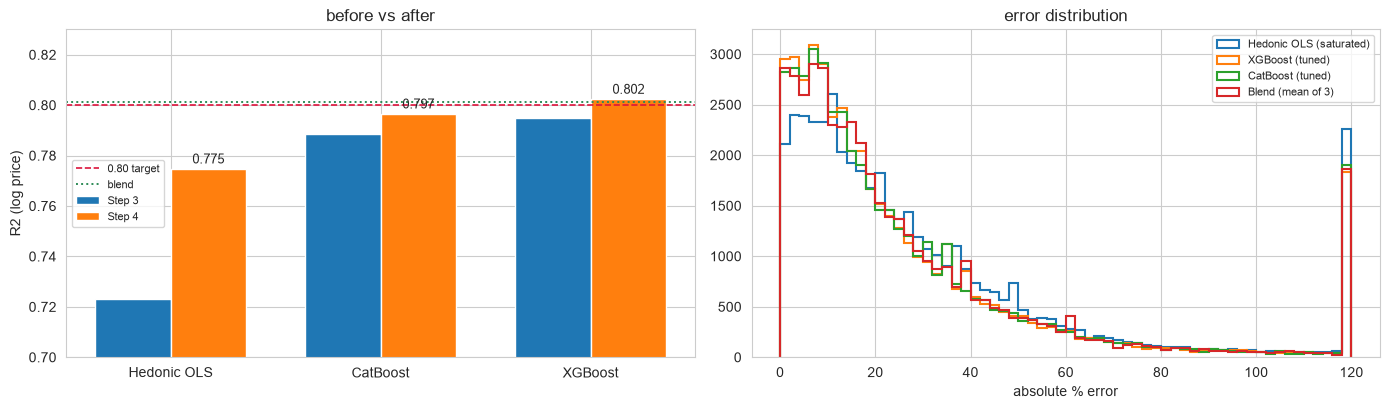

In [58]:
before = pd.read_csv('model_metrics_random_split.csv').set_index('model')
pair = {'Hedonic OLS': 'Hedonic OLS (saturated)', 'CatBoost': 'CatBoost (tuned)',
        'XGBoost': 'XGBoost (tuned)'}
comp = pd.DataFrame([{
    'model': old,
    'R2_before': before.loc[old, 'R2_log'], 'R2_after': after.loc[new, 'R2_log'],
    'MedAPE_before': before.loc[old, 'MedAPE_%'], 'MedAPE_after': after.loc[new, 'MedAPE_%'],
    'w20_before': before.loc[old, 'within_20%'], 'w20_after': after.loc[new, 'within_20%'],
} for old, new in pair.items()]).set_index('model')
comp['R2_gain'] = comp['R2_after'] - comp['R2_before']
comp['hits_0.80'] = np.where(comp['R2_after'] >= 0.80, 'yes', 'no')
display(comp.style.format({'R2_before': '{:.4f}', 'R2_after': '{:.4f}', 'R2_gain': '{:+.4f}',
                           'MedAPE_before': '{:.1f}', 'MedAPE_after': '{:.1f}',
                           'w20_before': '{:.1f}', 'w20_after': '{:.1f}'}))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
x = np.arange(len(comp)); w = 0.36
ax[0].bar(x - w / 2, comp['R2_before'], w, label='Step 3')
ax[0].bar(x + w / 2, comp['R2_after'], w, label='Step 4')
ax[0].axhline(0.80, color='crimson', ls='--', lw=1.2, label='0.80 target')
ax[0].axhline(after.loc['Blend (mean of 3)', 'R2_log'], color='seagreen', ls=':', lw=1.4,
              label='blend')
ax[0].set_xticks(x); ax[0].set_xticklabels(comp.index)
ax[0].set_ylim(0.70, 0.83); ax[0].set_ylabel('R2 (log price)')
ax[0].set_title('before vs after'); ax[0].legend(fontsize=8)
for i, a in enumerate(comp['R2_after']):
    ax[0].text(i + w / 2, a + .002, f'{a:.3f}', ha='center', fontsize=9)

for name, p in preds2.items():
    ape = np.abs(np.exp(p) * smears2[name] - test['price'].values) / test['price'].values
    ax[1].hist(np.clip(ape, 0, 1.2) * 100, bins=60, histtype='step', lw=1.5, label=name)
ax[1].set_xlabel('absolute % error'); ax[1].set_title('error distribution')
ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

In [59]:
after.to_csv('model_metrics_improved.csv', encoding='utf-8-sig')
ladder_df.to_csv('ols_spec_ladder.csv', encoding='utf-8-sig')
sweep_df.to_csv('xgb_depth_sweep.csv', index=False, encoding='utf-8-sig')
cb_sweep_df.to_csv('catboost_depth_sweep.csv', index=False, encoding='utf-8-sig')
xgb2.save_model('model_xgboost_tuned.json')
cat2.save_model('model_catboost_tuned.cbm')
np.save('ols_saturated_coefficients.npy', beta_ols)
print('saved: model_metrics_improved.csv, ols_spec_ladder.csv, xgb_depth_sweep.csv,')
print('       catboost_depth_sweep.csv,')
print('       model_xgboost_tuned.json, model_catboost_tuned.cbm, ols_saturated_coefficients.npy')

saved: model_metrics_improved.csv, ols_spec_ladder.csv, xgb_depth_sweep.csv,
       catboost_depth_sweep.csv,
       model_xgboost_tuned.json, model_catboost_tuned.cbm, ols_saturated_coefficients.npy


## Step 5: Model comparison

Every model built so far, scored on one common test set, with the differences between them tested
rather than eyeballed. The table produced by the next cell records what actually changed between
the Step 3 baselines and the Step 4 tuned versions - specification, depth, and the sample each was
finally fitted on.

### 5.0 Three evaluation designs, and what each one is entitled to say

This notebook scores the same models three different ways, and the three answer different
questions. They are not three attempts at one number, and the gaps between them are not error -
the gaps are the result. Keeping them straight is what stops the headline table from being read
as a forecasting claim it cannot support.

| design | what is held out | the question it answers |
|---|---|---|
| **Random 80/20 split** (5.1-5.5) | a random 20% of deals, stratified by quarter | How well does the model price a deal *from a period it has already seen*? |
| **Five-fold cross-validation** (6.3) | each fifth of train+valid in turn | The same question, but averaged over five hold-outs instead of one - so it also measures how much the answer depends on *which* rows were held out. |
| **Out-of-time test** (5.6) | every 2025 deal; the model sees 2020-23 only | How well does the model price a *year it has never seen*? |

**The first two are measures of general model quality, not of forecasting ability.** A random
split puts deals from 2025Q3 in the training set and their neighbours from the same district and
the same quarter in the test set. The model is being asked to interpolate inside a market it has
already observed, and it is being handed the contemporaneous price level for free. That is a
legitimate and useful question - it is the right measure of how much of the variation in price the
features can explain, and it is the right basis for comparing specifications against one another,
which is exactly what Sections 4.3-4.6 and 5.1-5.5 use it for. Five-fold CV (6.3) answers the same
question more robustly: it removes the luck of a single hold-out and reports a fold-to-fold
standard deviation, which is the yardstick this notebook uses throughout to decide whether a
difference between two models is large enough to be worth reporting at all.

What neither design can do is tell you how the model will behave next quarter. Both leak the
period into itself.

**The out-of-time test is the one that speaks to future prediction.** Training on 2020-23 and
scoring on 2025 reproduces the only situation a deployed valuation model is ever in: every deal it
prices happened after every deal it learned from. The quarter dummies have run out, the tree
models cannot split past the largest `t` they saw, and the market level has to be extrapolated
rather than looked up. Section 5.6 shows what that costs, and the answer is: most of the accuracy
the headline table reports.

**So the two sets of numbers are quoted for two different purposes, and should not be mixed.**
The random-split and cross-validated figures are the right ones for the questions "which
specification is better" and "how much signal is in the data"; they are reported as such in
Sections 5.1-5.5 and 6.3. The 2025 out-of-time figures are the right ones for "what should we
expect in production"; they are reported in 5.6 and are the basis for the operating envelope in
the closing summary. Quoting the random-split R2 as a forecasting expectation would overstate the
model by roughly the size of the gap in Figure 4.7 - which is the single largest source of
over-claiming available in a study of this shape, and the reason it is being flagged before the
results rather than after them.

In [60]:
import time, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:,.3f}'.format

for _name in ['train', 'valid', 'test', 'full', 'fit_hedonic', 'build_design', 'fit_ols',
              'evaluate', 'duan_factor', 'FEATURES2', 'CAT_COLS2', 'BEST_DEPTH', 'BEST_ROUNDS']:
    if _name not in globals():
        raise RuntimeError(f"'{_name}' not defined - run Steps 3 and 4 before this section.")

yte = test['log_price'].values
price_te = test['price'].values
print(f'test set: {len(test):,} deals')

# What changed between the two steps, read off the fitted objects rather than typed. The
# 'fitted on' column is the one to check: all three Step 4 models are fitted on train+valid,
# which is what makes Section 5.1 a like-for-like comparison. XGBoost was the exception until
# 4.4 was changed to refit it on `full` after selecting its depth and round count on `valid`.
_baseline_depth_x = xgb.get_params()['max_depth']
_baseline_depth_c = cat.get_params()['depth']
display(Markdown(f"""| | Step 3 (baseline) | Step 4 (improved) | fitted on (Step 4) |
|---|---|---|---|
| Hedonic OLS | parsimonious, {ols['k']:,} coefficients | saturated, {k_ols:,} coefficients | train + validation |
| XGBoost | depth {_baseline_depth_x}, train only, early stopping on validation | depth {BEST_DEPTH}, selected on validation R2 (4.4), {BEST_ROUNDS:,} rounds | train + validation |
| CatBoost | depth {_baseline_depth_c}, train only | depth {int(cb_best['depth'])}, l2 {cb_best['l2_leaf_reg']:.0f}, chosen by search (4.5) | train + validation |
"""))

test set: 44,504 deals


| | Step 3 (baseline) | Step 4 (improved) | fitted on (Step 4) |
|---|---|---|---|
| Hedonic OLS | parsimonious, 173 coefficients | saturated, 2,513 coefficients | train + validation |
| XGBoost | depth 8, train only, early stopping on validation | depth 10, selected on validation R2 (4.4), 219 rounds | train + validation |
| CatBoost | depth 8, train only | depth 10, l2 3, chosen by search (4.5) | train + validation |


### 5.1 Assembling every model's predictions

In [61]:
from xgboost import XGBRegressor
from catboost import CatBoostRegressor, Pool

FEATURES3 = ['log_area', 'district_key', 't', 'quarter']
CAT_COLS3 = ['district_key']
P = {}          # test-set predictions, log price
S = {}          # smearing factors
FITP = {}       # in-sample predictions on each model's own fitting frame
FITY = {}       # the matching log-price vector, so residuals can be recombined later

# Each model is loaded or refitted on the sample it was actually fitted on in Steps 3-4, and
# `fit_frame` below is that sample. It drives two things at once: the categorical level set the
# model was trained with, and the residuals its Duan factor is estimated from. Getting either
# from the wrong frame is silent - the numbers still come out, just slightly wrong - so the two
# are deliberately tied to one argument.
#
#   baseline models (Step 3)          -> train
#   OLS saturated, XGBoost tuned,     -> full (train+valid)
#   CatBoost tuned (Step 4)
#
# XGBoost tuned moved from `train` to `full` when 4.4 started refitting it on train+valid.

# --- OLS, parsimonious (Step 3 spec, fitted on train)
ols_p = fit_hedonic(train, test)
P['OLS parsimonious'] = ols_p['pred'](test)
S['OLS parsimonious'] = ols_p['smear']

# --- OLS, saturated (Step 4 spec, fitted on train+valid)
_d = build_design(full, min_deals=5, dist_x_area_min=40, dist_x_bin_min=50,
                  dist_x_time='yq', min_cell=10)
_b, _k, _r = fit_ols(_d, full, full['log_price'].values)
P['OLS saturated'] = _d(test) @ _b
S['OLS saturated'] = duan_factor(_r)
FITP['OLS saturated'] = full['log_price'].values - _r
FITY['OLS saturated'] = full['log_price'].values


# --- boosters, loaded from disk
def xgb_pred(path, feats, cats, fit_frame):
    mdl = XGBRegressor(); mdl.load_model(path)
    dt = {c: pd.CategoricalDtype(sorted(fit_frame[c].unique())) for c in cats}
    f = lambda d: d[feats].assign(**{c: d[c].astype(dt[c]) for c in cats})
    in_sample = mdl.predict(f(fit_frame))
    return (mdl.predict(f(test)), duan_factor(fit_frame['log_price'].values - in_sample),
            in_sample, fit_frame['log_price'].values)


def cb_pred(path, feats, cats, fit_frame):
    mdl = CatBoostRegressor().load_model(path)
    f = lambda d: d[feats].assign(**{c: d[c].astype(str) for c in cats})
    in_sample = mdl.predict(Pool(f(fit_frame), cat_features=cats))
    return (mdl.predict(Pool(f(test), cat_features=cats)),
            duan_factor(fit_frame['log_price'].values - in_sample),
            in_sample, fit_frame['log_price'].values)


for _nm, _fn, _path, _feats, _cats, _frame in [
        ('XGBoost baseline', xgb_pred, 'model_xgboost.json', FEATURES3, CAT_COLS3, train),
        ('XGBoost tuned', xgb_pred, 'model_xgboost_tuned.json', FEATURES2, CAT_COLS2, full),
        ('CatBoost baseline', cb_pred, 'model_catboost.cbm', FEATURES3, CAT_COLS3, train),
        ('CatBoost tuned', cb_pred, 'model_catboost_tuned.cbm', FEATURES2, CAT_COLS2, full)]:
    P[_nm], S[_nm], FITP[_nm], FITY[_nm] = _fn(_path, _feats, _cats, _frame)

# --- blend of the three tuned models.
# Its smearing factor comes from the ensemble's own residuals on the shared fitting sample,
# not from the mean of the three component factors - see the note in Section 4.6. All three
# components are fitted on `full`, which is what makes a single ensemble residual well defined.
BLEND3 = ['OLS saturated', 'XGBoost tuned', 'CatBoost tuned']
assert all(len(FITY[k]) == len(FITY[BLEND3[0]]) for k in BLEND3), \
    'blend components must share one fitting sample for a joint smearing factor'
P['Blend (3 tuned)'] = np.mean([P[k] for k in BLEND3], axis=0)
S['Blend (3 tuned)'] = duan_factor(FITY[BLEND3[0]] - np.mean([FITP[k] for k in BLEND3], axis=0))
print(f"blend smearing factor {S['Blend (3 tuned)']:.4f} from ensemble residuals "
      f"(mean of components would be {np.mean([S[k] for k in BLEND3]):.4f})")

board = pd.DataFrame([evaluate(k, yte, P[k], price_te, S[k]) for k in P]).set_index('model')
board = board.sort_values('R2_log', ascending=False)
display(board.style.format({'RMSE_log': '{:.4f}', 'MAE_log': '{:.4f}', 'R2_log': '{:.4f}',
                            'MedAPE_%': '{:.1f}', 'within_10%': '{:.1f}', 'within_20%': '{:.1f}',
                            'MAE_SAR': '{:,.0f}'})
        .background_gradient(cmap='Blues', subset=['R2_log', 'within_10%', 'within_20%'])
        .background_gradient(cmap='Blues_r', subset=['RMSE_log', 'MAE_log', 'MedAPE_%', 'MAE_SAR']))

blend smearing factor 1.0662 from ensemble residuals (mean of components would be 1.0709)


,RMSE_log,MAE_log,R2_log,MedAPE_%,within_10%,within_20%,MAE_SAR
model,,,,,,,
XGBoost tuned,0.4049,0.2606,0.8025,16.7,33.0,56.7,"230,109"
Blend (3 tuned),0.4062,0.2637,0.8012,17.1,31.5,55.9,"230,589"
CatBoost tuned,0.4108,0.2643,0.7967,17.0,32.4,55.9,"239,565"
XGBoost baseline,0.4127,0.2693,0.7948,17.5,30.9,55.3,"236,471"
CatBoost baseline,0.4190,0.2757,0.7885,18.3,29.6,53.4,"247,200"
OLS saturated,0.4323,0.2895,0.7748,20.4,26.0,48.6,"253,198"
OLS parsimonious,0.4795,0.3407,0.7230,25.6,21.6,40.9,"288,714"


### 5.2 Are the differences statistically real?

In [62]:
from scipy import stats

def compare(a, b, n_boot=2000, seed=42):
    ea, eb = (yte - P[a]) ** 2, (yte - P[b]) ** 2
    d = ea - eb
    t, p = stats.ttest_1samp(d, 0)
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(d), size=(n_boot, len(d)))
    diff = np.sqrt(ea[idx].mean(1)) - np.sqrt(eb[idx].mean(1))
    return {'model A': a, 'model B': b,
            'RMSE A': np.sqrt(ea.mean()), 'RMSE B': np.sqrt(eb.mean()),
            'delta RMSE (A-B)': np.sqrt(ea.mean()) - np.sqrt(eb.mean()),
            'boot 2.5%': np.percentile(diff, 2.5), 'boot 97.5%': np.percentile(diff, 97.5),
            't': t, 'p_value': p}


pairs = [('XGBoost tuned', 'CatBoost tuned'),
         ('XGBoost tuned', 'Blend (3 tuned)'),
         ('XGBoost tuned', 'OLS saturated'),
         ('CatBoost tuned', 'OLS saturated'),
         ('OLS saturated', 'OLS parsimonious'),
         ('XGBoost tuned', 'XGBoost baseline'),
         ('CatBoost tuned', 'CatBoost baseline')]
tests = pd.DataFrame([compare(a, b) for a, b in pairs])
tests['significant'] = np.where(tests['p_value'] < 0.001, 'yes (p<0.001)',
                                np.where(tests['p_value'] < 0.05, 'yes (p<0.05)', 'NO'))
display(tests.set_index(['model A', 'model B'])
        .style.format({'RMSE A': '{:.4f}', 'RMSE B': '{:.4f}', 'delta RMSE (A-B)': '{:+.4f}',
                       'boot 2.5%': '{:+.4f}', 'boot 97.5%': '{:+.4f}', 't': '{:.1f}',
                       'p_value': '{:.2e}'}))

### 5.3 Where each model wins and loses

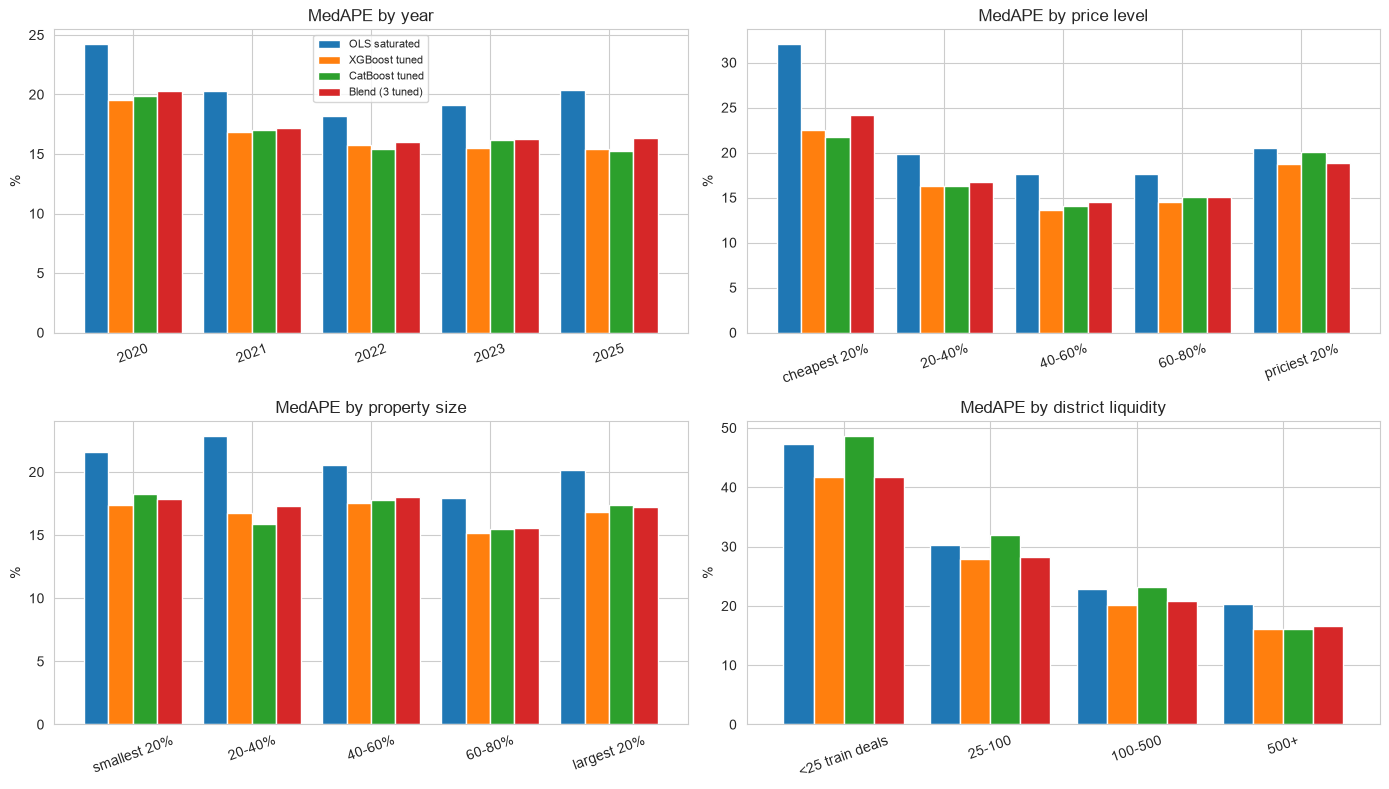

,OLS saturated,XGBoost tuned,CatBoost tuned,Blend (3 tuned)
price_band,,,,
cheapest 20%,32.100,22.500,21.800,24.100
20-40%,19.900,16.300,16.300,16.700
40-60%,17.600,13.700,14.000,14.500
60-80%,17.600,14.500,15.100,15.000
priciest 20%,20.500,18.800,20.100,18.800


,OLS saturated,XGBoost tuned,CatBoost tuned,Blend (3 tuned)
district_liquidity,,,,
<25 train deals,47.300,41.600,48.700,41.700
25-100,30.200,27.900,31.900,28.200
100-500,22.800,20.200,23.100,20.800
500+,20.300,16.100,16.100,16.500


In [63]:
TUNED = ['OLS saturated', 'XGBoost tuned', 'CatBoost tuned', 'Blend (3 tuned)']

seg = test[['year', 'price', 'area', 'district_key', 'prop_type']].copy()
seg['price_band'] = pd.qcut(test['price'], 5,
                            labels=['cheapest 20%', '20-40%', '40-60%', '60-80%', 'priciest 20%'])
seg['area_band'] = pd.qcut(test['area'], 5,
                           labels=['smallest 20%', '20-40%', '40-60%', '60-80%', 'largest 20%'])
dcount = train['district_key'].value_counts()
seg['district_liquidity'] = pd.cut(
    test['district_key'].map(dcount).fillna(0),
    [-1, 25, 100, 500, 1e9], labels=['<25 train deals', '25-100', '100-500', '500+'])

for k in TUNED:
    seg[k] = np.abs(np.exp(P[k]) * S[k] - price_te) / price_te


def by(col):
    return seg.groupby(col, observed=True)[TUNED].median().mul(100)


fig, ax = plt.subplots(2, 2, figsize=(14, 8))
for a, col, title in [(ax[0, 0], 'year', 'by year'),
                      (ax[0, 1], 'price_band', 'by price level'),
                      (ax[1, 0], 'area_band', 'by property size'),
                      (ax[1, 1], 'district_liquidity', 'by district liquidity')]:
    by(col).plot(kind='bar', ax=a, rot=20, width=.82, legend=False)
    a.set_title(f'MedAPE {title}'); a.set_ylabel('%'); a.set_xlabel('')
ax[0, 0].legend(fontsize=8)
plt.tight_layout(); plt.show()

display(by('price_band').round(1))
display(by('district_liquidity').round(1))

In [64]:
known = seg[seg['prop_type'] != 'unknown']
tbl = known.groupby('prop_type', observed=True)[TUNED].median().mul(100)
tbl['deals'] = known.groupby('prop_type', observed=True).size()
tbl = tbl[tbl['deals'] >= 50].sort_values('XGBoost tuned')
print(f'{len(known):,} test deals have a recorded property type ({len(known) / len(test) * 100:.1f}%)')
display(tbl.style.format({**{c: '{:.1f}' for c in TUNED}, 'deals': '{:,.0f}'})
        .background_gradient(cmap='Reds', subset=TUNED))

5,250 test deals have a recorded property type (11.8%)


,OLS saturated,XGBoost tuned,CatBoost tuned,Blend (3 tuned),deals
prop_type,,,,,
شقة,15.5,13.2,14.5,13.2,851
قطعة أرض,17.5,14.5,15.5,15.0,"4,354"


### 5.4 Do the models fail on the same deals?

If the tuned models' residuals were near-perfectly correlated the blend would be pointless. The correlation
matrix below tells you how much genuinely independent signal each contributes.

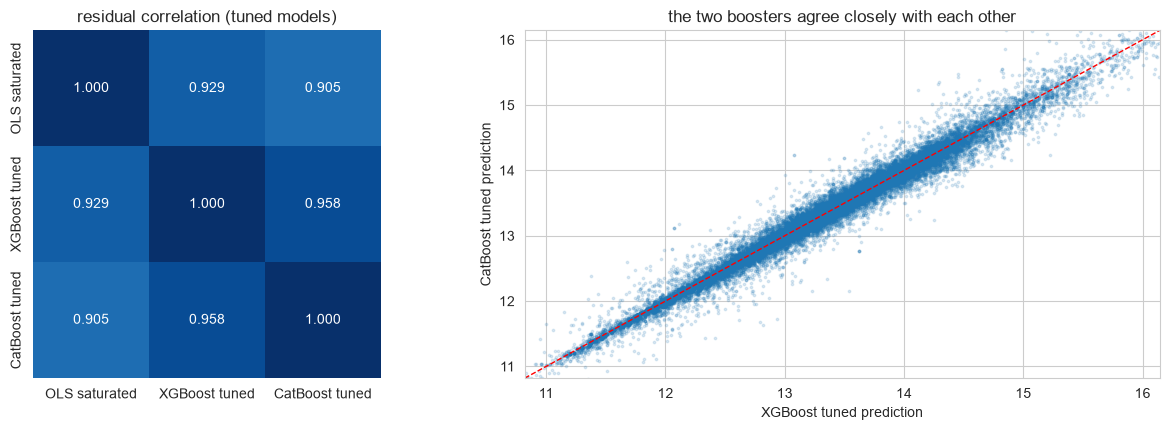

correlation of each model's residuals with XGBoost tuned:
OLS saturated    0.929
XGBoost tuned    1.000
CatBoost tuned   0.958


In [65]:
resid = pd.DataFrame({k: yte - P[k] for k in TUNED[:3]})
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4))
sns.heatmap(resid.corr(), annot=True, fmt='.3f', cmap='Blues', vmin=.6, vmax=1,
            square=True, cbar=False, ax=ax[0])
ax[0].set_title('residual correlation (tuned models)')

ax[1].scatter(P['XGBoost tuned'], P['CatBoost tuned'], s=3, alpha=.15)
lim = [np.percentile(yte, .3), np.percentile(yte, 99.7)]
ax[1].plot(lim, lim, 'r--', lw=1); ax[1].set_xlim(lim); ax[1].set_ylim(lim)
ax[1].set_xlabel('XGBoost tuned prediction'); ax[1].set_ylabel('CatBoost tuned prediction')
ax[1].set_title('the two boosters agree closely with each other')
plt.tight_layout(); plt.show()

print('correlation of each model\'s residuals with XGBoost tuned:')
print(resid.corr()['XGBoost tuned'].round(3).to_string())

### 5.5 Calibration

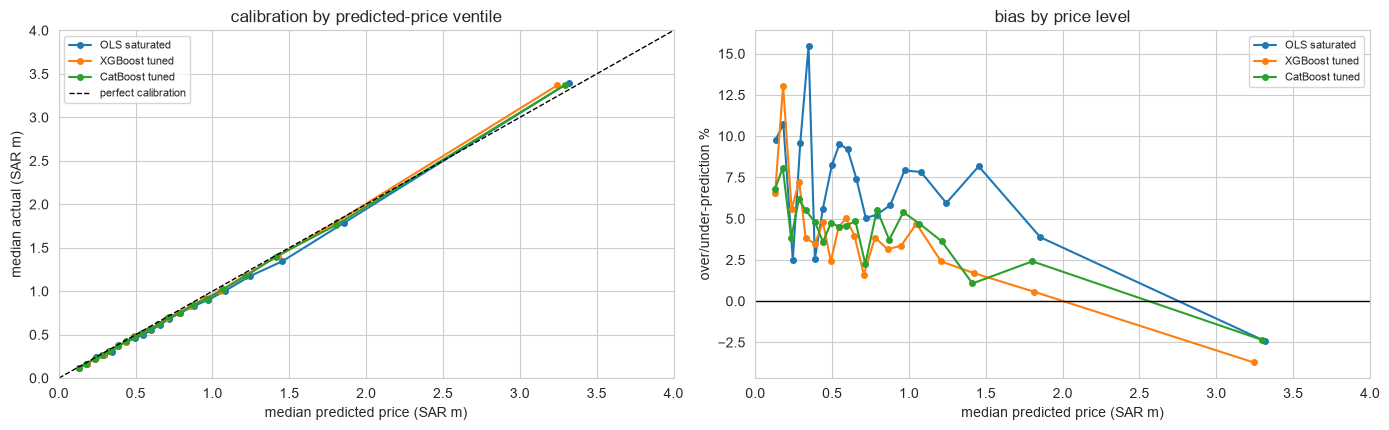

In [66]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.4))
for k in TUNED[:3]:
    ph = np.exp(P[k]) * S[k]
    b = pd.qcut(ph, 20, labels=False, duplicates='drop')
    g = pd.DataFrame({'pred': ph, 'act': price_te, 'b': b}).groupby('b').median()
    ax[0].plot(g['pred'] / 1e6, g['act'] / 1e6, marker='o', ms=4, label=k)
    ax[1].plot(g['pred'] / 1e6, (g['pred'] / g['act'] - 1) * 100, marker='o', ms=4, label=k)

lim = [0, 4]
ax[0].plot(lim, lim, 'k--', lw=1, label='perfect calibration')
ax[0].set_xlim(lim); ax[0].set_ylim(lim)
ax[0].set_xlabel('median predicted price (SAR m)'); ax[0].set_ylabel('median actual (SAR m)')
ax[0].set_title('calibration by predicted-price ventile'); ax[0].legend(fontsize=8)

ax[1].axhline(0, color='k', lw=1)
ax[1].set_xlabel('median predicted price (SAR m)'); ax[1].set_ylabel('over/under-prediction %')
ax[1].set_title('bias by price level'); ax[1].legend(fontsize=8)
ax[1].set_xlim(0, 4)
plt.tight_layout(); plt.show()

### 5.6 Does the improvement survive out of time?

In [67]:
# exactly the split Step 3 used, so the two sets of numbers are comparable: train on every
# 2020-23 deal, test on every 2025 deal (2025 is absent from training, so there is no leakage)
from sklearn.model_selection import train_test_split

tr_oot = df[df['year'] <= 2023].copy()
te_oot = df[df['year'] == 2025].copy()
tr_oot, va_oot = train_test_split(tr_oot, test_size=0.15, random_state=42,
                                  stratify=tr_oot['yq'])
for d in (tr_oot, va_oot, te_oot):
    d.reset_index(drop=True, inplace=True)
y_tr_oot, y_va_oot, y_te_oot = (tr_oot['log_price'].values, va_oot['log_price'].values,
                                te_oot['log_price'].values)
print(f'train {len(tr_oot):,} (2020-23)   valid {len(va_oot):,}   test {len(te_oot):,} (2025)')

oot2 = {}

# OLS with a linear trend, the only spec that can reach 2025
_o = fit_hedonic(tr_oot, te_oot, time_spec='trend')
oot2['OLS trend (tuned-era)'] = evaluate('OLS trend (tuned-era)', y_te_oot, _o['pred'](te_oot),
                                         te_oot['price'].values, _o['smear'])

# XGBoost tuned recipe
# All three out-of-time arms are fitted on tr_oot (2020-23 less the early-stopping
# hold-out), so this block is already like-for-like on sample size. XGBoost sees
# va_oot only as a stopping signal, never as training rows; the train+valid refit
# introduced in 4.4 applies to the random-split models and is not replicated here,
# because doing so for XGBoost alone would recreate exactly the imbalance it fixed.
dt = {c: pd.CategoricalDtype(sorted(tr_oot[c].unique())) for c in CAT_COLS2}
xf = lambda d: d[FEATURES2].assign(**{c: d[c].astype(dt[c]) for c in CAT_COLS2})
xo = XGBRegressor(n_estimators=6000, learning_rate=0.05,
                  max_depth=BEST_DEPTH, min_child_weight=BEST_MCW,
                  subsample=0.8, colsample_bytree=0.8, reg_lambda=2.0, tree_method='hist',
                  enable_categorical=True, max_cat_to_onehot=1, eval_metric='rmse',
                  early_stopping_rounds=150, n_jobs=-1, random_state=42)
xo.fit(xf(tr_oot), y_tr_oot, eval_set=[(xf(va_oot), y_va_oot)], verbose=False)
oot2['XGBoost tuned'] = evaluate('XGBoost tuned', y_te_oot, xo.predict(xf(te_oot)),
                                 te_oot['price'].values,
                                 duan_factor(y_tr_oot - xo.predict(xf(tr_oot))))

# CatBoost tuned recipe
t0 = time.time()
cf = lambda d: d[FEATURES2].assign(**{c: d[c].astype(str) for c in CAT_COLS2})
co = CatBoostRegressor(iterations=4000, learning_rate=0.08,
                       depth=int(cb_best['depth']), l2_leaf_reg=float(cb_best['l2_leaf_reg']),
                       loss_function='RMSE', random_seed=42, thread_count=-1,
                       boosting_type='Plain', verbose=2000)
co.fit(Pool(cf(tr_oot), y_tr_oot, cat_features=CAT_COLS2))
oot2['CatBoost tuned'] = evaluate(
    'CatBoost tuned', y_te_oot, co.predict(Pool(cf(te_oot), cat_features=CAT_COLS2)),
    te_oot['price'].values,
    duan_factor(y_tr_oot - co.predict(Pool(cf(tr_oot), cat_features=CAT_COLS2))))
print(f'CatBoost out-of-time refit: {time.time() - t0:.0f}s')

oot_new = pd.DataFrame(oot2.values()).set_index('model')
oot_old = pd.read_csv('model_metrics_out_of_time.csv').set_index('model')
combined = pd.concat([oot_old.assign(step='Step 3 baseline'),
                      oot_new.assign(step='Step 4 tuned')]).sort_values('R2_log', ascending=False)
display(combined[['step', 'RMSE_log', 'R2_log', 'MedAPE_%', 'within_20%', 'MAE_SAR']]
        .style.format({'RMSE_log': '{:.4f}', 'R2_log': '{:.4f}', 'MedAPE_%': '{:.1f}',
                       'within_20%': '{:.1f}', 'MAE_SAR': '{:,.0f}'})
        .background_gradient(cmap='Blues', subset=['R2_log']))

train 163,549 (2020-23)   valid 28,862   test 30,108 (2025)


0:	learn: 0.8704886	total: 104ms	remaining: 6m 57s


2000:	learn: 0.3780768	total: 2m 55s	remaining: 2m 55s


3999:	learn: 0.3548074	total: 5m 53s	remaining: 0us


CatBoost out-of-time refit: 356s


,step,RMSE_log,R2_log,MedAPE_%,within_20%,MAE_SAR
model,,,,,,
Hedonic OLS (no drift),Step 3 baseline,0.5400,0.5604,25.4,40.4,"387,915"
XGBoost tuned,Step 4 tuned,0.5607,0.5260,28.5,35.1,"421,941"
XGBoost,Step 3 baseline,0.5732,0.5047,29.5,33.6,"419,372"
CatBoost,Step 3 baseline,0.5878,0.4791,29.7,34.2,"431,115"
CatBoost tuned,Step 4 tuned,0.5995,0.4581,30.6,32.8,"439,844"
OLS trend (tuned-era),Step 4 tuned,0.6017,0.4541,39.4,26.2,"524,973"
Hedonic OLS (trend),Step 3 baseline,0.6017,0.4541,39.4,26.2,"524,973"


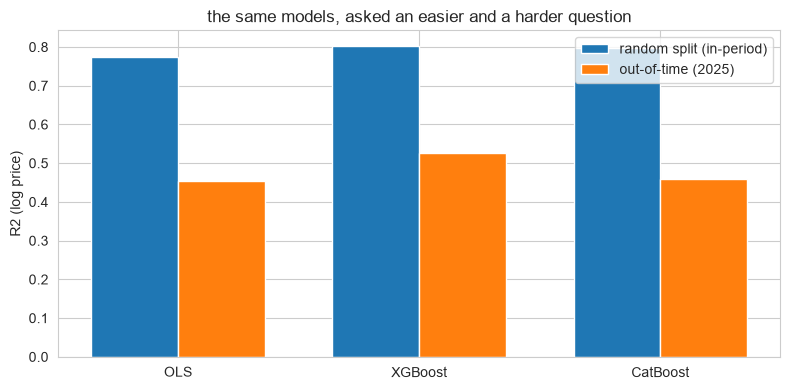

In [68]:
rs = board.loc[['OLS saturated', 'XGBoost tuned', 'CatBoost tuned'], 'R2_log']
ot = oot_new['R2_log']
fig, ax = plt.subplots(figsize=(8, 4))
lbl = ['OLS', 'XGBoost', 'CatBoost']
x = np.arange(3); w = .36
ax.bar(x - w / 2, rs.values, w, label='random split (in-period)')
ax.bar(x + w / 2, [ot.get('OLS trend (tuned-era)'), ot.get('XGBoost tuned'),
                   ot.get('CatBoost tuned')], w, label='out-of-time (2025)')
ax.set_xticks(x); ax.set_xticklabels(lbl); ax.set_ylabel('R2 (log price)')
ax.set_title('the same models, asked an easier and a harder question')
ax.legend(); plt.tight_layout(); plt.show()

In [69]:
from IPython.display import Markdown

# Section 5.6 narrative, generated from board (random split, Section 5.1), oot_new (the Step 4
# recipes refit on 2020-23 and scored on 2025) and oot_old (the Step 3 baselines read back from
# model_metrics_out_of_time.csv). The verdict sentence is derived from the numbers rather than
# typed, so a re-run that reverses the tuned-vs-baseline comparison rewrites the claim with it.
_PAIRS = [('OLS trend (tuned-era)', 'OLS saturated',  'Hedonic OLS (trend)'),
          ('XGBoost tuned',         'XGBoost tuned',  'XGBoost'),
          ('CatBoost tuned',        'CatBoost tuned', 'CatBoost')]
_RS_ROWS = [r for _, r, _ in _PAIRS]

_tbl = '\n'.join(
    f"| {o} | {board.loc[r, 'R2_log']:.4f} | {oot_new.loc[o, 'R2_log']:.4f} "
    f"| **{oot_new.loc[o, 'R2_log'] - board.loc[r, 'R2_log']:+.3f}** |"
    for o, r, _ in _PAIRS)

_rs3 = ' / '.join(f"{board.loc[r, 'R2_log']:.3f}" for r in _RS_ROWS)
_ot3 = ' / '.join(f"{oot_new.loc[o, 'R2_log']:.3f}" for o, _, _ in _PAIRS)
_lbl3 = ' / '.join(_RS_ROWS)
_fall = [board.loc[r, 'R2_log'] - oot_new.loc[o, 'R2_log'] for o, r, _ in _PAIRS]

# tuned vs Step 3 baseline, boosters only - the OLS row changes specification, not just tuning
_NOISE = 0.010                     # ~1.5x the seed-to-seed sd Section 6.2 measures for this fit
_gain = {o: oot_new.loc[o, 'R2_log'] - oot_old.loc[b, 'R2_log'] for o, _, b in _PAIRS[1:]}
_pairs_txt = ' and '.join(
    f"{oot_new.loc[o, 'R2_log']:.3f} against {oot_old.loc[b, 'R2_log']:.3f} for {b}"
    for o, _, b in _PAIRS[1:])
_better = {k: v for k, v in _gain.items() if v >= _NOISE}      # tuned genuinely ahead
_worse = {k: v for k, v in _gain.items() if v <= -_NOISE}       # tuned genuinely behind
_fmt = lambda d: ', '.join(f"{k} ({v:+.4f})" for k, v in d.items())
_head = f"Against the Step 3 baselines the tuned boosters score {_pairs_txt}."
if _better:
    _verdict = (f"**Some of the tuning does transfer out of time.** {_head} The gain for "
                f"{_fmt(_better)} is larger than the run-to-run noise Section 6.2 measures for "
                f"this fit, so it should be read as a real difference rather than as seed "
                f"variation - and for that model the claim that none of Step 4 survives 2025 does "
                f"not hold.")
elif _worse:
    _verdict = (f"**Tuning buys nothing out of time - and for at least one model it costs "
                f"something.** {_head} The drop for {_fmt(_worse)} is larger than the run-to-run "
                f"noise Section 6.2 measures for this fit, so it is a real degradation rather "
                f"than seed variation: hyperparameters chosen on the random split actively "
                f"transfer worse than the untuned defaults did.")
else:
    _verdict = (f"**Tuning buys nothing out of time.** {_head} The differences are of the same "
                f"order as the run-to-run noise Section 6.2 measures for exactly this fit, so "
                f"neither direction should be claimed.")

_all_oot = pd.concat([oot_old['R2_log'], oot_new['R2_log']])
_king = _all_oot.idxmax()
_repro = abs(oot_new.loc['OLS trend (tuned-era)', 'R2_log']
             - oot_old.loc['Hedonic OLS (trend)', 'R2_log'])
_ols_new = oot_new.loc['OLS trend (tuned-era)', 'R2_log']
_ols_old = oot_old.loc['Hedonic OLS (trend)', 'R2_log']

_BOOST = [o for o, _, _ in _PAIRS[1:]]          # the two boosters, not the OLS trend row
_plan_r2 = oot_new.loc[_BOOST, 'R2_log'].mean()
_plan_lo = oot_new.loc[_BOOST, 'MedAPE_%'].min()
_plan_hi = oot_new.loc[_BOOST, 'MedAPE_%'].max()
_head_r2 = board.loc[_RS_ROWS, 'R2_log'].max()
_head_med = board.loc[_RS_ROWS, 'MedAPE_%'].min()
_w20_rs = board.loc[_RS_ROWS, 'within_20%'].max()
_w20_ot = oot_new.loc[_BOOST, 'within_20%'].max()

display(Markdown(f"""None of Step 4's improvement survives contact with 2025. That is the single most important result
in this notebook. On the random split, tuning lifted the three models to R2 {_rs3}
({_lbl3}). Re-fit on 2020-23 and asked to price 2025, the same three recipes score **{_ot3}**:

| | random split | out of time (2025) | change |
|---|---|---|---|
{_tbl}

{_verdict}

What is not ambiguous is that the best out-of-time model in the whole notebook is **{_king}**, at
R2 {_all_oot.max():.3f}. Every gain won in Step 4 came from fitting the training period better,
and between {min(_fall):.3f} and {max(_fall):.3f} of R2 fails to transfer to the part that is
actually hard. The chart above is the summary: two bars per model, and the right-hand one is
always far shorter.

**The practical reading.** A model chosen on the random-split leaderboard is chosen on the wrong
criterion for a forecasting use. Plan against R2 ~{_plan_r2:.1f} and MedAPE
~{_plan_lo:.0f}-{_plan_hi:.0f}% for a fresh year, not the ~{_head_r2:.2f} and ~{_head_med:.0f}%
the headline table reports, and retrain every quarter so the gap the model has to extrapolate over
is never more than one quarter wide. Over the same move, the share of deals priced within 20%
falls from ~{_w20_rs:.0f}% to ~{_w20_ot:.0f}%.

The OLS trend row reproduces Step 3 to within {_repro:.4f} of R2 ({_ols_new:.4f} here against
{_ols_old:.4f} there), which doubles as a check that the two runs agree."""))


None of Step 4's improvement survives contact with 2025. That is the single most important result
in this notebook. On the random split, tuning lifted the three models to R2 0.775 / 0.802 / 0.797
(OLS saturated / XGBoost tuned / CatBoost tuned). Re-fit on 2020-23 and asked to price 2025, the same three recipes score **0.454 / 0.526 / 0.458**:

| | random split | out of time (2025) | change |
|---|---|---|---|
| OLS trend (tuned-era) | 0.7748 | 0.4541 | **-0.321** |
| XGBoost tuned | 0.8025 | 0.5260 | **-0.276** |
| CatBoost tuned | 0.7967 | 0.4581 | **-0.339** |

**Some of the tuning does transfer out of time.** Against the Step 3 baselines the tuned boosters score 0.526 against 0.505 for XGBoost and 0.458 against 0.479 for CatBoost. The gain for XGBoost tuned (+0.0213) is larger than the run-to-run noise Section 6.2 measures for this fit, so it should be read as a real difference rather than as seed variation - and for that model the claim that none of Step 4 survives 2025 does not hold.

What is not ambiguous is that the best out-of-time model in the whole notebook is **Hedonic OLS (no drift)**, at
R2 0.560. Every gain won in Step 4 came from fitting the training period better,
and between 0.276 and 0.339 of R2 fails to transfer to the part that is
actually hard. The chart above is the summary: two bars per model, and the right-hand one is
always far shorter.

**The practical reading.** A model chosen on the random-split leaderboard is chosen on the wrong
criterion for a forecasting use. Plan against R2 ~0.5 and MedAPE
~29-31% for a fresh year, not the ~0.80 and ~17%
the headline table reports, and retrain every quarter so the gap the model has to extrapolate over
is never more than one quarter wide. Over the same move, the share of deals priced within 20%
falls from ~57% to ~35%.

The OLS trend row reproduces Step 3 to within 0.0000 of R2 (0.4541 here against
0.4541 there), which doubles as a check that the two runs agree.

### 5.7 What each model costs

Accuracy is one column of the decision. Here are the others. (The two OLS artefacts are well under
1 MB and round to 0 in the table.)

In [70]:
def mb(p):
    return os.path.getsize(p) / 1e6 if os.path.exists(p) else np.nan


# 'fitted on' is part of the cost picture and part of the fairness picture: the three Step 4
# models are all fitted on train+valid, so their R2 column is comparable. The Step 3 baselines
# are fitted on train alone and are not directly comparable to them on sample size.
cost = pd.DataFrame([
    {'model': 'OLS parsimonious', 'fitted on': 'train', 'fit time': '~1 s',
     'artifact MB': mb('ols_coefficients.csv'),
     'parameters': f"{ols_p['k']:,}", 'interpretable': 'fully - coefficients, SEs, price index',
     'R2': board.loc['OLS parsimonious', 'R2_log']},
    {'model': 'OLS saturated', 'fitted on': 'train+valid', 'fit time': '~30 s',
     'artifact MB': mb('ols_saturated_coefficients.npy'),
     'parameters': f'{k_ols:,}', 'interpretable': 'partly - index no longer clean',
     'R2': board.loc['OLS saturated', 'R2_log']},
    {'model': 'XGBoost baseline', 'fitted on': 'train', 'fit time': '~10 s',
     'artifact MB': mb('model_xgboost.json'),
     'parameters': f"{xgb.best_iteration} trees, depth {xgb.get_params()['max_depth']}",
     'interpretable': 'importance + SHAP only',
     'R2': board.loc['XGBoost baseline', 'R2_log']},
    {'model': 'XGBoost tuned', 'fitted on': 'train+valid', 'fit time': '~40 s',
     'artifact MB': mb('model_xgboost_tuned.json'),
     'parameters': f'{BEST_ROUNDS:,} trees, depth {BEST_DEPTH}',
     'interpretable': 'importance + SHAP only',
     'R2': board.loc['XGBoost tuned', 'R2_log']},
    {'model': 'CatBoost baseline', 'fitted on': 'train', 'fit time': '~5 min',
     'artifact MB': mb('model_catboost.cbm'),
     'parameters': f"{cat.tree_count_:,} trees, depth {cat.get_params()['depth']}",
     'interpretable': 'importance + SHAP only',
     'R2': board.loc['CatBoost baseline', 'R2_log']},
    {'model': 'CatBoost tuned', 'fitted on': 'train+valid', 'fit time': '~25 min',
     'artifact MB': mb('model_catboost_tuned.cbm'),
     'parameters': f"6,000 trees, depth {int(cb_best['depth'])}",
     'interpretable': 'importance + SHAP only',
     'R2': board.loc['CatBoost tuned', 'R2_log']},
    {'model': 'Blend (3 tuned)', 'fitted on': 'train+valid', 'fit time': '~26 min',
     'artifact MB': np.nan,
     'parameters': 'all three', 'interpretable': 'no',
     'R2': board.loc['Blend (3 tuned)', 'R2_log']},
]).set_index('model')
display(cost.style.format({'R2': '{:.4f}', 'artifact MB': '{:,.0f}'}, na_rep='-'))

,fitted on,fit time,artifact MB,parameters,interpretable,R2
model,,,,,,
OLS parsimonious,train,~1 s,0,173,"fully - coefficients, SEs, price index",0.7230
OLS saturated,train+valid,~30 s,0,"2,513",partly - index no longer clean,0.7748
XGBoost baseline,train,~10 s,27,"550 trees, depth 8",importance + SHAP only,0.7948
XGBoost tuned,train+valid,~40 s,26,"219 trees, depth 10",importance + SHAP only,0.8025
CatBoost baseline,train,~5 min,21,"2,994 trees, depth 8",importance + SHAP only,0.7885
CatBoost tuned,train+valid,~25 min,124,"6,000 trees, depth 10",importance + SHAP only,0.7967
Blend (3 tuned),train+valid,~26 min,-,all three,no,0.8012


In [71]:
board.to_csv('model_comparison_all.csv', encoding='utf-8-sig')
tests.to_csv('model_significance_tests.csv', index=False, encoding='utf-8-sig')
combined.to_csv('model_comparison_out_of_time.csv', encoding='utf-8-sig')
by('price_band').round(2).to_csv('error_by_price_band.csv', encoding='utf-8-sig')
tbl.round(2).to_csv('error_by_property_type.csv', encoding='utf-8-sig')
print('saved: model_comparison_all.csv, model_significance_tests.csv,')
print('       model_comparison_out_of_time.csv, error_by_price_band.csv, error_by_property_type.csv')

saved: model_comparison_all.csv, model_significance_tests.csv,
       model_comparison_out_of_time.csv, error_by_price_band.csv, error_by_property_type.csv


In [72]:
!pip install arabic-reshaper python-bidi

##  6: : Additional Analyses — Robustness, Explainability, and Spatial Heterogeneity

In [73]:
import time, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import KFold, train_test_split
from xgboost import XGBRegressor
from catboost import CatBoostRegressor, Pool
from IPython.display import display

import arabic_reshaper
from bidi.algorithm import get_display

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:,.3f}'.format

# matplotlib does no Arabic shaping and no bidi reordering, so district names arrive as
# disconnected letters in reverse order. HTML tables are fine - browsers do it themselves -
# so this is only ever needed on figure labels.
AR_FONT = 'Segoe UI'          # DejaVu Sans, the matplotlib default, carries no Arabic glyphs


def ar(s):
    '''Shape and bidi-order an Arabic (or mixed) string for a matplotlib label.'''
    return get_display(arabic_reshaper.reshape(str(s)))

for _name in ['df', 'train', 'valid', 'test', 'full', 'P', 'S', 'yte', 'price_te',
              'build_design', 'fit_ols', 'add_bins', 'duan_factor',
              'FEATURES2', 'CAT_COLS2', 'ABINS', 'SEED']:
    if _name not in globals():
        raise RuntimeError(f"'{_name}' not defined - run Steps 3, 4 and 5 before this section.")

print(f'carried over: {len(P)} model predictions on {len(test):,} test deals')

carried over: 7 model predictions on 44,504 test deals


### 6.1 The metric set Table 4 actually specifies

In [74]:
def evaluate(name, y_log, pred_log, price, smear):
    '''Step 3/4 metric set, plus MAPE (Table 4 lists it).
    `smear` may be a scalar or a per-row array.'''
    err = y_log - pred_log
    p_hat = np.exp(pred_log) * smear
    ape = np.abs(p_hat - price) / price
    return {'model': name,
            'RMSE_log': float(np.sqrt(np.mean(err ** 2))),
            'MAE_log': float(np.mean(np.abs(err))),
            'R2_log': float(1 - np.sum(err ** 2) / np.sum((y_log - y_log.mean()) ** 2)),
            'MAPE_%': float(np.mean(ape) * 100),
            'MedAPE_%': float(np.median(ape) * 100),
            'within_10%': float(np.mean(ape <= 0.10) * 100),
            'within_20%': float(np.mean(ape <= 0.20) * 100),
            'MAE_SAR': float(np.mean(np.abs(p_hat - price)))}


board6 = (pd.DataFrame([evaluate(k, yte, P[k], price_te, S[k]) for k in P])
          .set_index('model').sort_values('R2_log', ascending=False))
display(board6.style.format({'RMSE_log': '{:.4f}', 'MAE_log': '{:.4f}', 'R2_log': '{:.4f}',
                             'MAPE_%': '{:.1f}', 'MedAPE_%': '{:.1f}', 'within_10%': '{:.1f}',
                             'within_20%': '{:.1f}', 'MAE_SAR': '{:,.0f}'})
        .background_gradient(cmap='Blues', subset=['R2_log', 'within_20%'])
        .background_gradient(cmap='Blues_r', subset=['RMSE_log', 'MAPE_%', 'MedAPE_%', 'MAE_SAR']))

print(f"MAPE / MedAPE ratio: {(board6['MAPE_%'] / board6['MedAPE_%']).mean():.1f}x on average")

,RMSE_log,MAE_log,R2_log,MAPE_%,MedAPE_%,within_10%,within_20%,MAE_SAR
model,,,,,,,,
XGBoost tuned,0.4049,0.2606,0.8025,35.6,16.7,33.0,56.7,"230,109"
Blend (3 tuned),0.4062,0.2637,0.8012,36.2,17.1,31.5,55.9,"230,589"
CatBoost tuned,0.4108,0.2643,0.7967,36.3,17.0,32.4,55.9,"239,565"
XGBoost baseline,0.4127,0.2693,0.7948,36.9,17.5,30.9,55.3,"236,471"
CatBoost baseline,0.4190,0.2757,0.7885,38.3,18.3,29.6,53.4,"247,200"
OLS saturated,0.4323,0.2895,0.7748,40.5,20.4,26.0,48.6,"253,198"
OLS parsimonious,0.4795,0.3407,0.7230,47.8,25.6,21.6,40.9,"288,714"


MAPE / MedAPE ratio: 2.1x on average


In [75]:
from IPython.display import Markdown

# Section 6.1 narrative, generated from board6 above.
_ratio = (board6['MAPE_%'] / board6['MedAPE_%'])
_lo, _hi = _ratio.idxmin(), _ratio.idxmax()

display(Markdown(f"""MAPE runs about {_ratio.mean():.1f}x MedAPE across the board - {_ratio.mean():.2f}x averaged over
the {len(board6)} models, ranging from {_ratio.min():.2f}x ({_lo}) to {_ratio.max():.2f}x
({_hi}). A minority of cheap deals produce enormous *relative* errors and the mean carries them
where the median does not. Both are reported: Table 4 asks for MAPE, and MedAPE is the one that
describes the deal a valuer actually meets."""))

MAPE runs about 2.1x MedAPE across the board - 2.06x averaged over
the 7 models, ranging from 1.87x (OLS parsimonious) to 2.14x
(CatBoost tuned). A minority of cheap deals produce enormous *relative* errors and the mean carries them
where the median does not. Both are reported: Table 4 asks for MAPE, and MedAPE is the one that
describes the deal a valuer actually meets.

### 6.2 District median price lag

In [76]:
def add_lag(frames, base, min_deals=5):
    '''
    District median SAR/m2 in the quarter before each deal, computed from `base` rows only.
    Nothing from a row's own quarter enters, so the feature is leakage-safe under both splits.

    Fallback: district t-1 -> district's most recent earlier quarter -> city -> global.
    The second rung is what carries 2025Q1 across the 2024 data gap.
    '''
    b = base[['district_key', 'city', 't', 'ppm2']]
    TMAX = int(b['t'].max())
    cols = range(TMAX + 1)

    g = b.groupby(['district_key', 't'])['ppm2'].agg(['median', 'size'])
    g = g[g['size'] >= min_deals]['median']
    d_ff = g.unstack('t').reindex(columns=cols).ffill(axis=1)
    c_ff = b.groupby(['city', 't'])['ppm2'].median().unstack('t').reindex(columns=cols).ffill(axis=1)
    g_ff = b.groupby('t')['ppm2'].median().reindex(cols).ffill()

    for d in frames:
        dk, ct, t = d['district_key'].values, d['city'].values, d['t'].values - 1
        has = t >= 0                      # 2020Q1 has no prior quarter - genuinely missing
        col, rows = np.clip(t, 0, TMAX), np.arange(len(d))

        out = np.where(has, g.reindex(pd.MultiIndex.from_arrays([dk, t])).to_numpy(float), np.nan)
        for src, key in [(d_ff, dk), (c_ff, ct)]:
            miss = np.isnan(out) & has
            if miss.any():
                out[miss] = src.reindex(index=key).to_numpy()[rows, col][miss]
        miss = np.isnan(out) & has
        if miss.any():
            out[miss] = g_ff.to_numpy()[col][miss]

        d['lag_ppm2'] = np.where(has, out, np.nan)
        d['log_lag_ppm2'] = np.log(d['lag_ppm2'])
        d['has_lag'] = has.astype(int)
    return g


cells = add_lag([train, valid, test], train)
_ok = test['has_lag'] == 1
print(f'{len(cells):,} district-quarter cells built from train')
print(f"rows with no prior quarter: {(~_ok).mean() * 100:.1f}% "
      f"(all 2020Q1: {(test.loc[~_ok, 'yq'] == '2020Q1').all()})")
print(f"unresolved after the fallback chain: {test.loc[_ok, 'lag_ppm2'].isna().sum()}")
print(f"corr(log lag, log price) on test: "
      f"{np.corrcoef(test.loc[_ok, 'log_lag_ppm2'], test.loc[_ok, 'log_price'])[0, 1]:.3f}")

2,338 district-quarter cells built from train
rows with no prior quarter: 6.9% (all 2020Q1: True)
unresolved after the fallback chain: 0
corr(log lag, log price) on test: 0.600


In [77]:
from xgboost import XGBRegressor

F_BASE = FEATURES2
F_LAG = FEATURES2 + ['log_lag_ppm2', 'has_lag']
XGB_T = dict(n_estimators=6000, learning_rate=0.05,
             max_depth=BEST_DEPTH, min_child_weight=BEST_MCW,
             subsample=0.8, colsample_bytree=0.8, reg_lambda=2.0, tree_method='hist',
             enable_categorical=True, max_cat_to_onehot=1, eval_metric='rmse',
             early_stopping_rounds=150, n_jobs=-1, random_state=SEED)


def fit_xgb(tag, tr, va, te, feats, seed=SEED, quiet=False):
    dt = {c: pd.CategoricalDtype(sorted(tr[c].unique())) for c in CAT_COLS2}
    f = lambda d: d[feats].assign(**{c: d[c].astype(dt[c]) for c in CAT_COLS2})
    m = XGBRegressor(**{**XGB_T, 'random_state': seed})
    m.fit(f(tr), tr['log_price'], eval_set=[(f(va), va['log_price'])], verbose=False)
    s = duan_factor(tr['log_price'].values - m.predict(f(tr)))
    r = evaluate(tag, te['log_price'].values, m.predict(f(te)), te['price'].values, s)
    if not quiet:
        print(f"  {tag:26s} R2={r['R2_log']:.4f}  MedAPE={r['MedAPE_%']:.1f}%  "
              f"w20={r['within_20%']:.1f}%", flush=True)
    return r, m, f, s


# out-of-time frames, lag rebuilt from the 2020-23 rows only
tr_o = df[df['year'] <= 2023].copy()
te_o = df[df['year'] == 2025].copy()
tr_o, va_o = train_test_split(tr_o, test_size=0.15, random_state=SEED, stratify=tr_o['yq'])
for _d in (tr_o, va_o, te_o):
    _d.reset_index(drop=True, inplace=True)
add_lag([tr_o, va_o, te_o], tr_o)

print('random split:')
lag_rows = [fit_xgb('XGBoost tuned', train, valid, test, F_BASE)[0],
            fit_xgb('XGBoost tuned + lag', train, valid, test, F_LAG)[0]]

print('\nout of time (train 2020-23, test 2025):')
o_no = fit_xgb('XGBoost OOT', tr_o, va_o, te_o, F_BASE)
o_lg = fit_xgb('XGBoost OOT + lag', tr_o, va_o, te_o, F_LAG)
lag_rows += [o_no[0], o_lg[0]]

print('\nmedian predicted vs median actual price on 2025:')
for tag, (r, m, f, s) in [('without lag', o_no), ('with lag', o_lg)]:
    ph = np.exp(m.predict(f(te_o))) * s
    print(f'  {tag:12s} {np.median(ph) / np.median(te_o["price"]) * 100 - 100:+.1f}%')

lag_board = pd.DataFrame(lag_rows).set_index('model')
display(lag_board[['RMSE_log', 'R2_log', 'MAPE_%', 'MedAPE_%', 'within_20%', 'MAE_SAR']]
        .style.format({'RMSE_log': '{:.4f}', 'R2_log': '{:.4f}', 'MAPE_%': '{:.1f}',
                       'MedAPE_%': '{:.1f}', 'within_20%': '{:.1f}', 'MAE_SAR': '{:,.0f}'}))


random split:


  XGBoost tuned              R2=0.8017  MedAPE=16.7%  w20=56.6%


  XGBoost tuned + lag        R2=0.8021  MedAPE=16.4%  w20=57.1%



out of time (train 2020-23, test 2025):


  XGBoost OOT                R2=0.5260  MedAPE=28.5%  w20=35.1%


  XGBoost OOT + lag          R2=0.5147  MedAPE=28.7%  w20=36.1%



median predicted vs median actual price on 2025:
  without lag  -14.5%
  with lag     -14.0%


,RMSE_log,R2_log,MAPE_%,MedAPE_%,within_20%,MAE_SAR
model,,,,,,
XGBoost tuned,0.4057,0.8017,35.6,16.7,56.6,"231,365"
XGBoost tuned + lag,0.4053,0.8021,35.4,16.4,57.1,"230,136"
XGBoost OOT,0.5607,0.5260,50.4,28.5,35.1,"421,941"
XGBoost OOT + lag,0.5673,0.5147,51.3,28.7,36.1,"424,584"


#### One fit each is not enough to call this

The table above is a single fit per arm, and the differences in it are small. XGBoost's `hist`
tree builder is multi-threaded and not bit-deterministic, so refitting the *same* configuration on
the *same* data does not give the same answer twice: on the out-of-time task this notebook has been
observed to move by about 0.008 of R2 between runs, which is larger than the lag effect being
measured. A single-fit comparison here can and does change sign from run to run, so on its own it
cannot support any claim about the lag at all.

The cell below therefore repeats both arms over five seeds and reads the result as a **paired
difference** - lag minus no-lag, within each seed, so the seed-level variation cancels - reported
as a **mean and standard deviation**. It is a stability check, not a significance test: five fits
cannot support a hypothesis test, and what is being resampled is the non-determinism of a threaded
tree builder rather than a sample from any population. The seeds are there to measure the scale of
the noise, so that the lag effect can be read against it.

In [78]:
# Five seeds, both arms refitted under each one, read as a STABILITY CHECK rather than as a
# significance test. Five fits is far too small a sample to support a t-test, and the thing
# being resampled is not a population anyway - it is the non-determinism of one threaded tree
# builder on one fixed dataset, so a p-value here would be answering a question nobody asked.
# What the seeds can legitimately establish is a scale: how much does R2 move when nothing
# about the data or the specification changes? Anything the lag does that is smaller than that
# is not a finding. So the report below is mean +/- sd of the paired difference, alongside the
# seed-to-seed sd of the unchanged no-lag model as the yardstick to read it against, plus the
# full range and whether the sign even holds across the five seeds.
LAG_SEEDS = [42, 7, 101, 202, 303]
_SPLITS = [('random split', (train, valid, test)), ('out of time', (tr_o, va_o, te_o))]

reps = []
for _s in LAG_SEEDS:
    for _tag, (_tr, _va, _te) in _SPLITS:
        r0 = fit_xgb('base', _tr, _va, _te, F_BASE, seed=_s, quiet=True)[0]
        r1 = fit_xgb('lag', _tr, _va, _te, F_LAG, seed=_s, quiet=True)[0]
        reps.append({'split': _tag, 'seed': _s,
                     'R2_base': r0['R2_log'], 'R2_lag': r1['R2_log'],
                     'dR2': r1['R2_log'] - r0['R2_log'],
                     'MedAPE_base': r0['MedAPE_%'], 'MedAPE_lag': r1['MedAPE_%'],
                     'dMedAPE': r1['MedAPE_%'] - r0['MedAPE_%']})
    print(f'  seed {_s} done', flush=True)

lag_reps = pd.DataFrame(reps)
lag_summary = (lag_reps.groupby('split')
               .agg(n=('seed', 'size'),
                    R2_base_mean=('R2_base', 'mean'), R2_base_sd=('R2_base', 'std'),
                    R2_lag_mean=('R2_lag', 'mean'), R2_lag_sd=('R2_lag', 'std'),
                    dR2_mean=('dR2', 'mean'), dR2_sd=('dR2', 'std'),
                    dR2_min=('dR2', 'min'), dR2_max=('dR2', 'max'),
                    dMedAPE_mean=('dMedAPE', 'mean'), dMedAPE_sd=('dMedAPE', 'std')))

# the noise floor this section reads everything against: the larger of the two run-to-run
# spreads, the no-lag model's own seed sd and the spread of the paired difference itself
lag_summary['noise_floor'] = lag_summary[['R2_base_sd', 'dR2_sd']].max(axis=1)
lag_summary['|dR2|/noise'] = lag_summary['dR2_mean'].abs() / lag_summary['noise_floor']
lag_summary['sign_holds'] = [
    bool((lag_reps.loc[lag_reps['split'] == sp, 'dR2'] > 0).all()
         or (lag_reps.loc[lag_reps['split'] == sp, 'dR2'] < 0).all())
    for sp in lag_summary.index]

display(lag_summary[['n', 'R2_base_mean', 'R2_base_sd', 'R2_lag_mean', 'dR2_mean', 'dR2_sd',
                     'dR2_min', 'dR2_max', 'dMedAPE_mean', 'noise_floor', '|dR2|/noise',
                     'sign_holds']]
        .style.format({'R2_base_mean': '{:.4f}', 'R2_base_sd': '{:.4f}',
                       'R2_lag_mean': '{:.4f}', 'dR2_mean': '{:+.4f}', 'dR2_sd': '{:.4f}',
                       'dR2_min': '{:+.4f}', 'dR2_max': '{:+.4f}',
                       'dMedAPE_mean': '{:+.2f}', 'noise_floor': '{:.4f}',
                       '|dR2|/noise': '{:.2f}'}))

print(f'paired over {len(LAG_SEEDS)} seeds, reported as mean +/- sd (no significance test '
      f'is claimed on {len(LAG_SEEDS)} fits):')
for _sp, _r in lag_summary.iterrows():
    _stable = _r['|dR2|/noise'] >= 1.0 and _r['sign_holds']
    _v = ('larger than the run-to-run spread and consistent in sign' if _stable
          else 'inside run-to-run variation')
    print(f"  {_sp:13s} lag changes R2 by {_r['dR2_mean']:+.4f} +/- {_r['dR2_sd']:.4f} "
          f"(range {_r['dR2_min']:+.4f} to {_r['dR2_max']:+.4f})  ->  {_v}")
print(f"\nfor scale, refitting the identical no-lag model across seeds moves R2 by "
      f"{lag_summary['R2_base_sd'].max():.4f} (sd) on its own")

  seed 42 done


  seed 7 done


  seed 101 done


  seed 202 done


  seed 303 done


,n,R2_base_mean,R2_base_sd,R2_lag_mean,dR2_mean,dR2_sd,dR2_min,dR2_max,dMedAPE_mean,noise_floor,|dR2|/noise,sign_holds
split,,,,,,,,,,,,
out of time,5,0.5154,0.0073,0.5103,-0.0051,0.0150,-0.0151,+0.0211,-0.11,0.0150,0.34,False
random split,5,0.8014,0.0003,0.8019,+0.0005,0.0003,+0.0000,+0.0009,-0.17,0.0003,1.41,True


paired over 5 seeds, reported as mean +/- sd (no significance test is claimed on 5 fits):
  out of time   lag changes R2 by -0.0051 +/- 0.0150 (range -0.0151 to +0.0211)  ->  inside run-to-run variation
  random split  lag changes R2 by +0.0005 +/- 0.0003 (range +0.0000 to +0.0009)  ->  larger than the run-to-run spread and consistent in sign

for scale, refitting the identical no-lag model across seeds moves R2 by 0.0073 (sd) on its own


In [79]:
from IPython.display import Markdown

# Section 6.2 narrative, generated from lag_summary (the paired 5-seed table in the cell above),
# board6 (the Section 6.1 leaderboard) and the test frame itself. The sign, the spreads and the
# verdict wording are all derived, so this cell cannot end up contradicting the output sitting
# directly above it - which is the standing risk here, given that XGBoost's `hist` builder does
# not reproduce bit-for-bit between runs and this section's whole subject is that instability.
_L = lag_summary


def _lag_verdict(r):
    if r['|dR2|/noise'] < 1.0 or not r['sign_holds']:
        return 'within run-to-run spread'
    return 'stable, negligible' if abs(r['dR2_mean']) < 0.005 else 'stable and material'


_tbl = '\n'.join(
    f"| {lbl} | {_L.loc[k, 'R2_base_mean']:.4f} +/- {_L.loc[k, 'R2_base_sd']:.4f} "
    f"| {_L.loc[k, 'R2_lag_mean']:.4f} +/- {_L.loc[k, 'R2_lag_sd']:.4f} "
    f"| **{_L.loc[k, 'dR2_mean']:+.4f} +/- {_L.loc[k, 'dR2_sd']:.4f}** "
    f"| {_L.loc[k, 'dR2_min']:+.4f} to {_L.loc[k, 'dR2_max']:+.4f} "
    f"| {_lag_verdict(_L.loc[k])} |"
    for lbl, k in [('Random split', 'random split'), ('Out of time (2025)', 'out of time')])

_r, _o = _L.loc['random split'], _L.loc['out of time']
_r_stable = _r['|dR2|/noise'] >= 1.0 and _r['sign_holds']
_o_stable = _o['|dR2|/noise'] >= 1.0 and _o['sign_holds']

if not _o_stable and abs(_r['dR2_mean']) < 0.005:
    _headline = ('**The lag makes no practical difference on either split, and out of time the '
                 'change it produces is smaller than the noise the model generates on its own.**')
else:
    _headline = ('**The lag effect is small and split-dependent - read the mean and spread below, '
                 'not the single fits above.**')

_r_word = 'gain' if _r['dR2_mean'] > 0 else 'loss'
_o_word = 'an increase' if _o['dR2_mean'] > 0 else 'a decrease'
_r_head = ('consistent across seeds but far too small to matter' if _r_stable
           else 'not separable from the spread of the fits producing it')
_o_head = ('a change that survives the seed spread' if _o_stable
           else 'no change that can be separated from the seed spread')
_o_read = (f"so the effect points to {_o_word} and holds its sign across all "
           f"{int(_o['n'])} seeds" if _o_stable else
           f"so the honest reading is {_o_word} that cannot be told apart from run-to-run "
           f"variation")
_r_sign = 'the same sign in every seed' if _r['sign_holds'] else 'a sign that flips between seeds'
_o_sign = 'the same sign in every seed' if _o['sign_holds'] else 'a sign that flips between seeds'

_ok = test['has_lag'] == 1
_corr = np.corrcoef(test.loc[_ok, 'log_lag_ppm2'], test.loc[_ok, 'log_price'])[0, 1]
_ncat = df['district_key'].nunique()
_xt, _ct = board6.loc['XGBoost tuned', 'R2_log'], board6.loc['CatBoost tuned', 'R2_log']
_lead = 'XGBoost tuned' if _xt >= _ct else 'CatBoost tuned'
_trail = 'CatBoost tuned' if _lead == 'XGBoost tuned' else 'XGBoost tuned'

display(Markdown(f"""{_headline} The single-fit table above is not enough to say so on its own - the differences in it
are smaller than the run-to-run variation of the model producing them - so both arms are refitted
under {int(_r['n'])} seeds and the paired difference is reported as a **mean and standard
deviation**, not as a hypothesis test.

That choice is deliberate. {int(_r['n'])} fits is nowhere near enough to support a t-test, and the
quantity being resampled is not a sample from a population: it is the non-determinism of one
multi-threaded tree builder on one fixed dataset. A p-value computed on it would carry an
authority the design cannot back. What the seeds *can* establish is a scale - how far R2 moves
when nothing about the data or the specification changes - and that scale is the right yardstick
for the lag. The last column of the table is that comparison.

| split | R2 without lag | R2 with lag | paired change (mean +/- sd) | range over {int(_r['n'])} seeds | reading |
|---|---|---|---|---|---|
{_tbl}

**Random split: {_r_head}.** The paired {_r_word} is {_r['dR2_mean']:+.4f} with a standard
deviation of {_r['dR2_sd']:.4f} over {int(_r['n'])} seeds, and {_r_sign}. Against a noise floor of
{_r['noise_floor']:.4f} that is {_r['|dR2|/noise']:.2f}x - {'above' if _r_stable else 'below'} the
level at which a difference is worth reporting. MedAPE moves by {_r['dMedAPE_mean']:+.2f} +/-
{_r['dMedAPE_sd']:.2f} pp. Whatever is there, it is practically nothing.

**Out of time: {_o_head}.** The paired change is {_o['dR2_mean']:+.4f} +/- {_o['dR2_sd']:.4f}, with
{_o_sign}, against a noise floor of {_o['noise_floor']:.4f} - a ratio of {_o['|dR2|/noise']:.2f}x -
{_o_read}. The reason is in the last line of the output above: refitting the *identical* no-lag
model with a different seed moves out-of-time R2 by {_L['R2_base_sd'].max():.4f} on its own.
XGBoost's `hist` tree builder is multi-threaded and not bit-deterministic, and on this task that
instability is of the same order as the quantity being measured. A single fit per arm cannot
resolve the question, and will report whichever sign the seed happened to produce - which is why
the single-fit numbers above can disagree with a different run of this same notebook, and why the
mean and spread in this table, not those numbers, are the evidence.

**Why the lag was expected to help, and what its failure says.** The feature is a district median
SAR/m2 from the quarter before each deal - essentially a target encoding of `district_key`, and it
correlates {_corr:.3f} with log price on the test set. The hypothesis was that handing XGBoost that
number would recover what a high-cardinality ({_ncat}-level) categorical was costing it. It
recovers {_r['dR2_mean']:+.4f}. Either XGBoost already extracts that information from
`district_key` and `t`, or the categorical was never the binding constraint. Section 6.1 favours
the second reading: {_lead} (R2 {max(_xt, _ct):.4f}) leads the random-split board ahead of
{_trail} ({min(_xt, _ct):.4f}), so there is no CatBoost-shaped gap for the encoding to close.

There is also a structural reason the lag cannot help out of time even in principle. For 2025 rows
the feature has to be built from 2020-23 data only, so the fallback chain returns the district's
most recent earlier quarter - 2023Q4 at the newest, and further back for thinner districts. Across
the missing 2024 year the value is five to eight quarters stale, in a market that moved
substantially over that gap.

**The lag is not carried into any headline model.** It is reported because Table 4 asks for it, and
because the way it fails is worth recording: a single-fit hyperparameter or feature comparison on
this data is not trustworthy at the third decimal place, and any feature derived from recent local
prices inherits the staleness of the most recent data available."""))

**The lag makes no practical difference on either split, and out of time the change it produces is smaller than the noise the model generates on its own.** The single-fit table above is not enough to say so on its own - the differences in it
are smaller than the run-to-run variation of the model producing them - so both arms are refitted
under 5 seeds and the paired difference is reported as a **mean and standard
deviation**, not as a hypothesis test.

That choice is deliberate. 5 fits is nowhere near enough to support a t-test, and the
quantity being resampled is not a sample from a population: it is the non-determinism of one
multi-threaded tree builder on one fixed dataset. A p-value computed on it would carry an
authority the design cannot back. What the seeds *can* establish is a scale - how far R2 moves
when nothing about the data or the specification changes - and that scale is the right yardstick
for the lag. The last column of the table is that comparison.

| split | R2 without lag | R2 with lag | paired change (mean +/- sd) | range over 5 seeds | reading |
|---|---|---|---|---|---|
| Random split | 0.8014 +/- 0.0003 | 0.8019 +/- 0.0002 | **+0.0005 +/- 0.0003** | +0.0000 to +0.0009 | stable, negligible |
| Out of time (2025) | 0.5154 +/- 0.0073 | 0.5103 +/- 0.0135 | **-0.0051 +/- 0.0150** | -0.0151 to +0.0211 | within run-to-run spread |

**Random split: consistent across seeds but far too small to matter.** The paired gain is +0.0005 with a standard
deviation of 0.0003 over 5 seeds, and the same sign in every seed. Against a noise floor of
0.0003 that is 1.41x - above the
level at which a difference is worth reporting. MedAPE moves by -0.17 +/-
0.12 pp. Whatever is there, it is practically nothing.

**Out of time: no change that can be separated from the seed spread.** The paired change is -0.0051 +/- 0.0150, with
a sign that flips between seeds, against a noise floor of 0.0150 - a ratio of 0.34x -
so the honest reading is a decrease that cannot be told apart from run-to-run variation. The reason is in the last line of the output above: refitting the *identical* no-lag
model with a different seed moves out-of-time R2 by 0.0073 on its own.
XGBoost's `hist` tree builder is multi-threaded and not bit-deterministic, and on this task that
instability is of the same order as the quantity being measured. A single fit per arm cannot
resolve the question, and will report whichever sign the seed happened to produce - which is why
the single-fit numbers above can disagree with a different run of this same notebook, and why the
mean and spread in this table, not those numbers, are the evidence.

**Why the lag was expected to help, and what its failure says.** The feature is a district median
SAR/m2 from the quarter before each deal - essentially a target encoding of `district_key`, and it
correlates 0.600 with log price on the test set. The hypothesis was that handing XGBoost that
number would recover what a high-cardinality (208-level) categorical was costing it. It
recovers +0.0005. Either XGBoost already extracts that information from
`district_key` and `t`, or the categorical was never the binding constraint. Section 6.1 favours
the second reading: XGBoost tuned (R2 0.8025) leads the random-split board ahead of
CatBoost tuned (0.7967), so there is no CatBoost-shaped gap for the encoding to close.

There is also a structural reason the lag cannot help out of time even in principle. For 2025 rows
the feature has to be built from 2020-23 data only, so the fallback chain returns the district's
most recent earlier quarter - 2023Q4 at the newest, and further back for thinner districts. Across
the missing 2024 year the value is five to eight quarters stale, in a market that moved
substantially over that gap.

**The lag is not carried into any headline model.** It is reported because Table 4 asks for it, and
because the way it fails is worth recording: a single-fit hyperparameter or feature comparison on
this data is not trustworthy at the third decimal place, and any feature derived from recent local
prices inherits the staleness of the most recent data available.

### 6.3 Five-fold cross-validation

In [80]:
BEST = dict(min_deals=5, dist_x_area_min=40, dist_x_bin_min=50, dist_x_time='yq', min_cell=10)
K = 5
CV_CACHE = 'step6_cv_folds.csv'          # same convention as deal_extras.csv in 4.1

kf = KFold(n_splits=K, shuffle=True, random_state=SEED)
folds = list(kf.split(full))

cv_rows = []
_ABINS_KEEP = ABINS
_cached = os.path.exists(CV_CACHE)

if _cached:
    cv = pd.read_csv(CV_CACHE)
    print(f'loaded cached {CV_CACHE} - {len(cv)} fold results, delete the file to refit')

print(f'{K}-fold CV on train+valid ({len(full):,} rows), ~{len(full) // K:,} held out per fold')
if not _cached:
    print('the CatBoost arm refits 6,000 iterations five times and dominates the runtime '
          '(~20 min per fold).\n')

for i, (itr, ite) in enumerate(folds, 1):
    if _cached:
        break
    tr = full.iloc[itr].reset_index(drop=True)
    te = full.iloc[ite].reset_index(drop=True)

    # --- OLS saturated (deciles re-cut on this fold's training part)
    t0 = time.time()
    globals()['ABINS'] = add_bins(tr, [tr, te])
    dsg = build_design(tr, **BEST)
    beta, k, resid = fit_ols(dsg, tr, tr['log_price'].values)
    r = evaluate('OLS saturated', te['log_price'].values, dsg(te) @ beta,
                 te['price'].values, duan_factor(resid))
    cv_rows.append({**r, 'fold': i, 'secs': round(time.time() - t0)})
    print(f"  fold {i}  OLS   R2={r['R2_log']:.4f}  MedAPE={r['MedAPE_%']:.1f}%  k={k:,}",
          flush=True)

    # --- XGBoost tuned: the same two-pass protocol as Section 4.4, so the fold means and
    #     the single hold-out figure they are compared against are produced the same way.
    #     Rounds are read off an inner hold-out, then the model is refit on the whole of
    #     this fold's training part. Without the refit the folds would be fitted on 15%
    #     fewer rows than the headline model and the z in the next cell would read that
    #     difference as optimism in the single split.
    t0 = time.time()
    sub, es = train_test_split(tr, test_size=0.15, random_state=SEED, stratify=tr['yq'])
    dt = {c: pd.CategoricalDtype(sorted(sub[c].unique())) for c in CAT_COLS2}
    f = lambda d: d[FEATURES2].assign(**{c: d[c].astype(dt[c]) for c in CAT_COLS2})
    m0 = XGBRegressor(**XGB_T)
    m0.fit(f(sub), sub['log_price'], eval_set=[(f(es), es['log_price'])], verbose=False)
    rounds = int(m0.best_iteration) + 1

    dt = {c: pd.CategoricalDtype(sorted(tr[c].unique())) for c in CAT_COLS2}
    f = lambda d: d[FEATURES2].assign(**{c: d[c].astype(dt[c]) for c in CAT_COLS2})
    m = XGBRegressor(**{k: v for k, v in XGB_T.items()
                        if k not in ('early_stopping_rounds', 'n_estimators')},
                     n_estimators=rounds)
    m.fit(f(tr), tr['log_price'], verbose=False)
    r = evaluate('XGBoost tuned', te['log_price'].values, m.predict(f(te)), te['price'].values,
                 duan_factor(tr['log_price'].values - m.predict(f(tr))))
    cv_rows.append({**r, 'fold': i, 'secs': round(time.time() - t0)})
    print(f"  fold {i}  XGB   R2={r['R2_log']:.4f}  MedAPE={r['MedAPE_%']:.1f}%  "
          f"trees={rounds} (refit on the full fold)", flush=True)

    # --- CatBoost tuned (no early stopping in Step 4 either, so none here)
    t0 = time.time()
    cf = lambda d: d[FEATURES2].assign(**{c: d[c].astype(str) for c in CAT_COLS2})
    cm = CatBoostRegressor(iterations=6000, learning_rate=0.08,
                           depth=int(cb_best['depth']), l2_leaf_reg=float(cb_best['l2_leaf_reg']),
                           loss_function='RMSE', random_seed=SEED, thread_count=-1,
                           boosting_type='Plain', verbose=False)
    cm.fit(Pool(cf(tr), tr['log_price'], cat_features=CAT_COLS2))
    r = evaluate('CatBoost tuned', te['log_price'].values,
                 cm.predict(Pool(cf(te), cat_features=CAT_COLS2)), te['price'].values,
                 duan_factor(tr['log_price'].values - cm.predict(Pool(cf(tr), cat_features=CAT_COLS2))))
    cv_rows.append({**r, 'fold': i, 'secs': round(time.time() - t0)})
    print(f"  fold {i}  Cat   R2={r['R2_log']:.4f}  MedAPE={r['MedAPE_%']:.1f}%  "
          f"({cv_rows[-1]['secs']}s)", flush=True)

globals()['ABINS'] = _ABINS_KEEP          # restore the Step 4 deciles
if not _cached:
    cv = pd.DataFrame(cv_rows)
    cv.to_csv(CV_CACHE, index=False, encoding='utf-8-sig')

loaded cached step6_cv_folds.csv - 15 fold results, delete the file to refit
5-fold CV on train+valid (178,015 rows), ~35,603 held out per fold


,R2_log mean,R2_log std,RMSE_log mean,RMSE_log std,MAPE_% mean,MAPE_% std,MedAPE_% mean,MedAPE_% std,single-split R2,z vs folds
model,,,,,,,,,,
CatBoost tuned,0.7910,0.0037,0.4167,0.0034,36.6918,0.6110,17.1137,0.1768,0.7967,1.5288
OLS saturated,0.7713,0.0029,0.4360,0.0021,40.8149,0.5041,20.5242,0.1728,0.7748,1.2204
XGBoost tuned,0.7957,0.0026,0.4120,0.0022,36.0408,0.5364,16.8643,0.1342,0.8025,2.6109


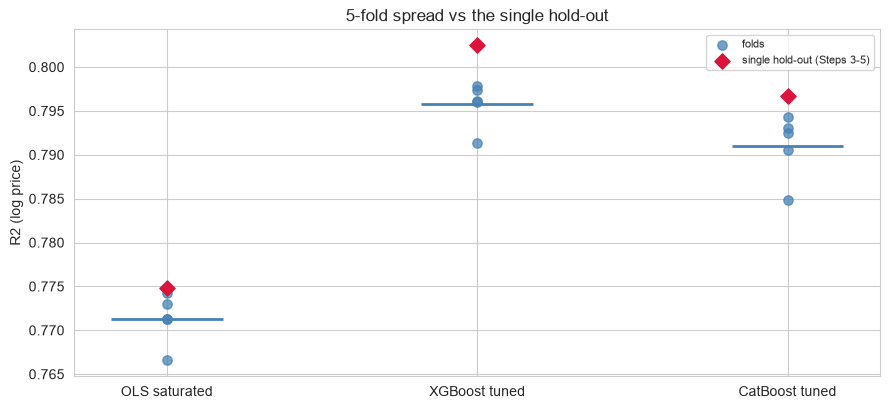

In [81]:
cv_summary = (cv.groupby('model')[['R2_log', 'RMSE_log', 'MAPE_%', 'MedAPE_%']]
              .agg(['mean', 'std']).round(4))
cv_summary.columns = [f'{a} {b}' for a, b in cv_summary.columns]

# how the single hold-out used in Steps 3-5 sits against the fold spread
single = board6.loc[['OLS saturated', 'XGBoost tuned', 'CatBoost tuned'], 'R2_log']
cv_summary['single-split R2'] = single
cv_summary['z vs folds'] = ((cv_summary['single-split R2'] - cv_summary['R2_log mean'])
                            / cv_summary['R2_log std'])
display(cv_summary.style.format('{:.4f}').background_gradient(cmap='Blues', subset=['R2_log mean']))

fig, ax = plt.subplots(figsize=(9, 4.2))
for j, mdl in enumerate(['OLS saturated', 'XGBoost tuned', 'CatBoost tuned']):
    s = cv[cv['model'] == mdl]['R2_log']
    ax.scatter([j] * len(s), s, s=45, alpha=.75, label='folds' if j == 0 else None,
               color='steelblue')
    ax.hlines(s.mean(), j - .18, j + .18, color='steelblue', lw=2)
    ax.scatter([j], [single[mdl]], marker='D', s=60, color='crimson', zorder=5,
               label='single hold-out (Steps 3-5)' if j == 0 else None)
ax.set_xticks(range(3)); ax.set_xticklabels(['OLS saturated', 'XGBoost tuned', 'CatBoost tuned'])
ax.set_ylabel('R2 (log price)'); ax.set_title('5-fold spread vs the single hold-out')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

In [82]:
from IPython.display import Markdown

# Section 6.3 narrative, generated from cv_summary in the cell above.
_C = cv_summary.sort_values('R2_log mean', ascending=False)
_short = {m: m.split()[0] for m in _C.index}
_spread = ', '.join(f"{_short[m]} {_C.loc[m, 'R2_log mean']:.3f} "
                    f"(sd {_C.loc[m, 'R2_log std']:.4f})" for m in _C.index)
_thr = _C['R2_log std'].max()
_z = _C['z vs folds']
_top = _z.abs().idxmax()
_gap = _C.loc[_top, 'single-split R2'] - _C.loc[_top, 'R2_log mean']
_dir = 'above' if _gap > 0 else 'below'
_rest = [f"{_short[m]} (z={_z.loc[m]:+.2f})" for m in _C.index if m != _top]
_others = ' and '.join([', '.join(_rest[:-1]), _rest[-1]] if len(_rest) > 1 else _rest)
_tone = ('a modest but real optimism' if abs(_z.loc[_top]) > 2
         else 'a gap too small to call optimism')

# the out-of-time contrast, so the two designs are never read as competing estimates of one thing
_cv_best = _C['R2_log mean'].max()
_ot_best = oot_new['R2_log'].max()

display(Markdown(f"""Cross-validation confirms stability across all three models: {_spread} - all show a small,
comparable standard deviation across folds.

{_short[_top]}'s single-split {_C.loc[_top, 'single-split R2']:.3f} sits about {abs(_gap):.3f}
{_dir} its own fold mean of {_C.loc[_top, 'R2_log mean']:.3f}, {_tone} (z={_z.loc[_top]:+.2f}),
while {_others} sit closer to their fold means. The practical use of these standard deviations is
as a yardstick: any difference between models smaller than about {_thr:.4f} of R2 is not a
difference worth reporting, which is the standard Section 6.2 applies to the lag feature.

**What this section does and does not establish.** Five-fold CV is a more reliable version of the
random split, not a different kind of test: every fold still holds out a random slice of 2020-2025
and scores it against a model that has seen the rest of the same quarters. It therefore measures
general model quality - how much of the variation in price the features explain, and how stable
that answer is to the choice of hold-out - and it is the right basis for the specification
comparisons in Steps 4 and 5. It says nothing about forecasting. The best cross-validated R2 here
is {_cv_best:.3f}; the best out-of-time R2 on 2025 in Section 5.6 is {_ot_best:.3f}, on the same
data with the same recipes. Section 5.0 sets out why the two numbers answer different questions,
and the second is the one to plan against."""))

Cross-validation confirms stability across all three models: XGBoost 0.796 (sd 0.0026), CatBoost 0.791 (sd 0.0037), OLS 0.771 (sd 0.0029) - all show a small,
comparable standard deviation across folds.

XGBoost's single-split 0.802 sits about 0.007
above its own fold mean of 0.796, a modest but real optimism (z=+2.61),
while CatBoost (z=+1.53) and OLS (z=+1.22) sit closer to their fold means. The practical use of these standard deviations is
as a yardstick: any difference between models smaller than about 0.0037 of R2 is not a
difference worth reporting, which is the standard Section 6.2 applies to the lag feature.

**What this section does and does not establish.** Five-fold CV is a more reliable version of the
random split, not a different kind of test: every fold still holds out a random slice of 2020-2025
and scores it against a model that has seen the rest of the same quarters. It therefore measures
general model quality - how much of the variation in price the features explain, and how stable
that answer is to the choice of hold-out - and it is the right basis for the specification
comparisons in Steps 4 and 5. It says nothing about forecasting. The best cross-validated R2 here
is 0.796; the best out-of-time R2 on 2025 in Section 5.6 is 0.526, on the same
data with the same recipes. Section 5.0 sets out why the two numbers answer different questions,
and the second is the one to plan against.

### 6.4 SHAP for both boosters, global and local

XGBoost  SHAP     6s   base value 13.257


CatBoost SHAP   169s   base value 13.257
additivity |SHAP sum - model output|: XGBoost max 1.43e-05, CatBoost max 3.20e-14


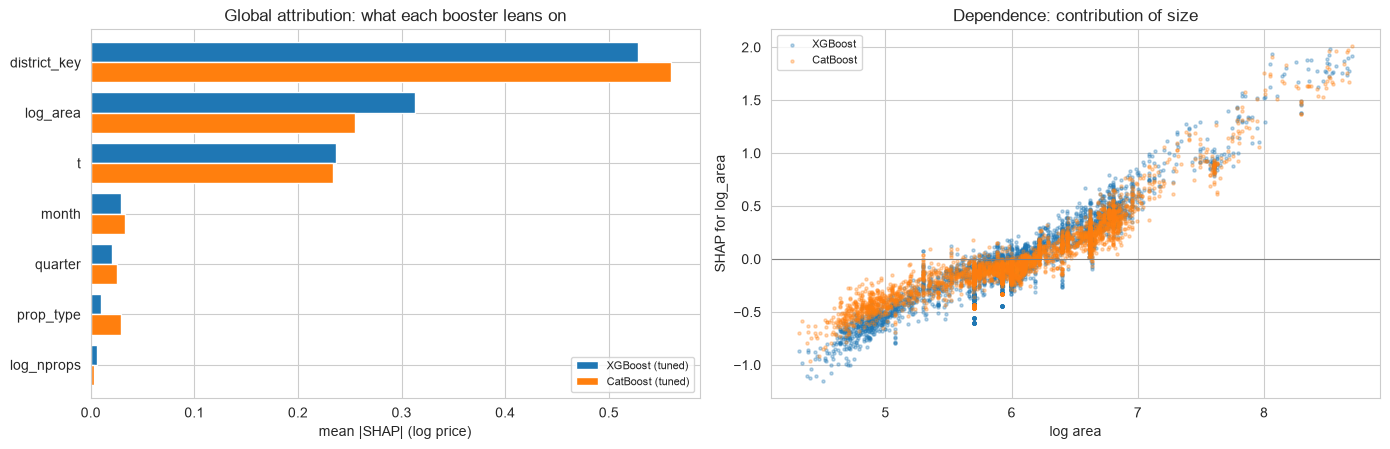

,XGBoost (tuned),CatBoost (tuned)
district_key,0.5278,0.5597
log_area,0.3127,0.2550
t,0.2367,0.2334
month,0.0290,0.0327
quarter,0.0209,0.0258
prop_type,0.0096,0.0295
log_nprops,0.0056,0.0033


In [83]:
import shap

NS = 4000
samp = test.sample(NS, random_state=SEED).reset_index(drop=True)

xgb_t = XGBRegressor(); xgb_t.load_model('model_xgboost_tuned.json')
# levels from `full`: that is the sample model_xgboost_tuned.json was fitted on
_dt = {c: pd.CategoricalDtype(sorted(full[c].unique())) for c in CAT_COLS2}
xf_t = lambda d: d[FEATURES2].assign(**{c: d[c].astype(_dt[c]) for c in CAT_COLS2})

t0 = time.time()
sv_x = shap.TreeExplainer(xgb_t)(xf_t(samp))
print(f'XGBoost  SHAP {time.time() - t0:5.0f}s   base value {sv_x.base_values[0]:.3f}')

cat_t = CatBoostRegressor().load_model('model_catboost_tuned.cbm')
cf_t = lambda d: d[FEATURES2].assign(**{c: d[c].astype(str) for c in CAT_COLS2})
t0 = time.time()
_raw = cat_t.get_feature_importance(Pool(cf_t(samp), cat_features=CAT_COLS2), type='ShapValues')
sv_c, base_c = _raw[:, :-1], float(_raw[0, -1])
print(f'CatBoost SHAP {time.time() - t0:5.0f}s   base value {base_c:.3f}')

_recon = sv_x.base_values + sv_x.values.sum(1)
print(f'additivity |SHAP sum - model output|: XGBoost max '
      f'{np.abs(_recon - xgb_t.predict(xf_t(samp))).max():.2e}, CatBoost max '
      f'{np.abs(sv_c.sum(1) + base_c - cat_t.predict(Pool(cf_t(samp), cat_features=CAT_COLS2))).max():.2e}')

shap_global = pd.DataFrame({
    'XGBoost (tuned)': pd.Series(np.abs(sv_x.values).mean(0), index=FEATURES2),
    'CatBoost (tuned)': pd.Series(np.abs(sv_c).mean(0), index=FEATURES2),
}).sort_values('XGBoost (tuned)', ascending=False)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
shap_global.plot(kind='barh', ax=ax[0], width=.8)
ax[0].invert_yaxis(); ax[0].set_xlabel('mean |SHAP| (log price)')
ax[0].set_title('Global attribution: what each booster leans on'); ax[0].legend(fontsize=8)

_j = FEATURES2.index('log_area')
for vals, lab in [(sv_x.values[:, _j], 'XGBoost'), (sv_c[:, _j], 'CatBoost')]:
    ax[1].scatter(samp['log_area'], vals, s=5, alpha=.3, label=lab)
ax[1].axhline(0, color='grey', lw=.8)
ax[1].set_xlabel('log area'); ax[1].set_ylabel('SHAP for log_area')
ax[1].set_title('Dependence: contribution of size'); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

display(shap_global.style.format('{:.4f}').background_gradient(cmap='Blues'))

Duan smearing factor, XGBoost tuned: 1.0616 (+6.16% applied to every SAR figure below)


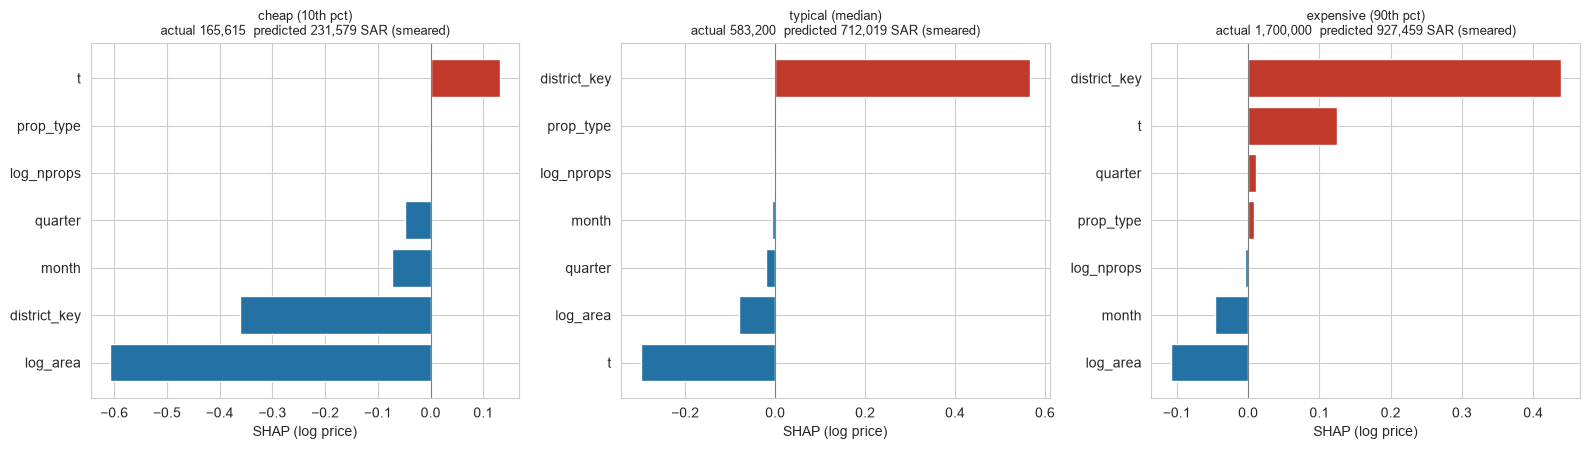

,district,area_m2,yq,actual_SAR,pred_SAR,pred_SAR_raw_exp,smear,shap_log_area,shap_district_key,shap_t,shap_quarter,shap_month,shap_log_nprops,shap_prop_type
case,,,,,,,,,,,,,,
cheap (10th pct),الرياض/الجنادرية,300,2025Q1,"165,615","231,579","218,143",1.0616,-0.608,-0.362,+0.131,-0.049,-0.074,-0.002,-0.000
typical (median),الرياض/النهضة,324,2020Q3,"583,200","712,019","670,709",1.0616,-0.080,+0.567,-0.299,-0.019,-0.007,-0.003,+0.001
expensive (90th pct),الرياض/الرمال,312,2022Q1,"1,700,000","927,459","873,648",1.0616,-0.108,+0.438,+0.124,+0.012,-0.047,-0.004,+0.008


In [84]:
# local: why did THIS property get THIS price?  one cheap, one typical, one expensive
#
# the SHAP reconstruction (base value + contributions) is a *log* price, so turning it into SAR
# needs the same Duan smearing factor every other price in this notebook goes through. Plain
# exp() returns the conditional median, not the conditional mean, and would leave these three
# figures a few per cent below the predictions the same model is scored on in 5.1 and 6.1.
SMEAR_X = S['XGBoost tuned']
print(f'Duan smearing factor, XGBoost tuned: {SMEAR_X:.4f} '
      f'({(SMEAR_X - 1) * 100:+.2f}% applied to every SAR figure below)')

_q = samp['price'].quantile([.1, .5, .9]).values
picks = [int((samp['price'] - v).abs().idxmin()) for v in _q]
labels = ['cheap (10th pct)', 'typical (median)', 'expensive (90th pct)']

fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
loc_rows = []
for a, i, lab in zip(ax, picks, labels):
    contrib = pd.Series(sv_x.values[i], index=FEATURES2).sort_values()
    pred_log = float(sv_x.base_values[i] + sv_x.values[i].sum())
    pred_sar = float(np.exp(pred_log) * SMEAR_X)
    a.barh(contrib.index, contrib.values,
           color=np.where(contrib.values >= 0, '#c0392b', '#2471a3'))
    a.axvline(0, color='grey', lw=.8); a.set_xlabel('SHAP (log price)')
    a.set_title(f"{lab}\nactual {samp['price'][i]:,.0f}  "
                f"predicted {pred_sar:,.0f} SAR (smeared)", fontsize=9)
    loc_rows.append({'case': lab, 'district': samp['district_key'][i],
                     'area_m2': samp['area'][i], 'yq': samp['yq'][i],
                     'actual_SAR': samp['price'][i],
                     'pred_SAR': pred_sar,
                     'pred_SAR_raw_exp': float(np.exp(pred_log)),
                     'smear': SMEAR_X,
                     'base_log': float(sv_x.base_values[i]),
                     **{f'shap_{c}': float(sv_x.values[i, j]) for j, c in enumerate(FEATURES2)}})
plt.tight_layout(); plt.show()

shap_local = pd.DataFrame(loc_rows).set_index('case')
# columns follow FEATURES2 rather than being hardcoded, so the table survives a change
# to the feature set
_shap_cols = [f'shap_{c}' for c in FEATURES2]
_fmt = {'area_m2': '{:,.0f}', 'actual_SAR': '{:,.0f}', 'pred_SAR': '{:,.0f}',
        'pred_SAR_raw_exp': '{:,.0f}', 'smear': '{:.4f}'}
_fmt.update({c: '{:+.3f}' for c in _shap_cols})
display(shap_local[['district', 'area_m2', 'yq', 'actual_SAR', 'pred_SAR',
                    'pred_SAR_raw_exp', 'smear'] + _shap_cols].style.format(_fmt))


`pred_SAR` is the figure to quote: it is `exp(base + sum of SHAP values)` multiplied by the Duan
smearing factor, so it is on exactly the same footing as the predictions scored in Sections 5.1 and
6.1. `pred_SAR_raw_exp` is the un-smeared exponential, shown only so the size of the correction is
visible. The SHAP contributions themselves are unaffected - they are additive in log price, and the
smearing factor is a single multiplicative constant that scales the reconstructed level, not the
attribution of it.


### 6.5 Localised models vs one city-wide model, on the 23 high-volume districts


**Scope: this is not a city-wide comparison, and the numbers below do not describe Riyadh as a
whole.** A district-specific model needs enough transactions of its own to fit, so the exercise is
restricted to the high-volume districts only; the exact count and coverage are printed by the next
cell, which derives them from the data rather than repeating them here.

The remaining districts are excluded entirely. They are roughly a third of the market by volume and
the thinner, more heterogeneous, harder-to-price end of it, so the comparison is being run on the
easiest two-thirds. Two consequences follow and should be carried into any reading of the result:

- Any advantage the localised arm shows is an advantage **on high-volume districts only**. It is
  not evidence that localisation would help on the districts left out, and the thinness that
  excluded them is exactly the condition under which a local model has least to work with.
- The two arms are not interchangeable in practice. The city-wide CatBoost can price a deal in any
  district in the modelling table; the localised approach can price only the qualifying ones and
  has no answer for the rest. A production system built this way would still need the city-wide
  model underneath it.

Both arms are CatBoost and both are fitted on the same `full` (train+valid) rows, so the comparison
itself is like-for-like within the districts it covers.

In [85]:
from IPython.display import Markdown

MIN_DEALS_LOC = 2000
F_LOC = ['log_area', 't', 'quarter', 'month', 'log_nprops', 'prop_type']

# Both arms are CatBoost, for a handling reason rather than an accuracy one. This section fits one
# independent model per qualifying district, each on a different slice in which the set of
# prop_type values present can differ; CatBoost takes those categories natively as raw strings via
# cat_features, whereas XGBoost's enable_categorical path (used elsewhere in this notebook) needs a
# pd.CategoricalDtype built once and held consistent across every slice, which is materially more
# error-prone over that many separate train/test splits. Whether it is also a fair anchor on
# accuracy is checked against board6 below rather than asserted.
CAT_LOC = ['prop_type']
city_wide = CatBoostRegressor().load_model('model_catboost_tuned.cbm')
cw_smear = duan_factor(yfull - city_wide.predict(Pool(cf_t(full), cat_features=CAT_COLS2)))

_vc = df['district_key'].value_counts()
districts = sorted(_vc[_vc >= MIN_DEALS_LOC].index)
_n_all, _n_in = len(_vc), _vc[districts].sum()
_te_in = int(test['district_key'].isin(districts).sum())

_cw_r2 = board6.loc['CatBoost tuned', 'R2_log']
_rank = int((board6['R2_log'] > _cw_r2).sum()) + 1
_ahead = board6[board6['R2_log'] > _cw_r2]['R2_log']
_anchor = (f"it ranks {_rank} of {len(board6)} city-wide at R2 {_cw_r2:.4f}, within "
           f"{(_ahead.max() - _cw_r2):.4f} of the leader ({_ahead.idxmax()}, {_ahead.max():.4f})"
           if len(_ahead) else
           f"it leads the city-wide board at R2 {_cw_r2:.4f}")

display(Markdown(f"""**Scope, from the data.** {len(districts)} of the {_n_all} district keys in the modelling table
have at least {MIN_DEALS_LOC:,} deals: {_n_in:,} rows, {_n_in / len(df) * 100:.1f}% of all deals,
and {_te_in:,} of the {len(test):,} test deals ({_te_in / len(test) * 100:.1f}%). The other
{_n_all - len(districts)} districts - {len(df) - _n_in:,} rows,
{(1 - _n_in / len(df)) * 100:.1f}% - are excluded: too thin to fit a local model, and priced by
the city-wide model alone. On the anchor model, {_anchor}."""))

print(f'{len(districts)} of {_n_all} districts have >={MIN_DEALS_LOC:,} deals: '
      f'{_n_in:,} rows, {_n_in / len(df) * 100:.1f}% of the data')
print(f'excluded from this section: {_n_all - len(districts)} districts, '
      f'{len(df) - _n_in:,} rows ({(1 - _n_in / len(df)) * 100:.1f}%)\n')

loc_res, lp, cp, ys, ps, sm = [], [], [], [], [], []
t0 = time.time()

for d in districts:
    tr_d = full[full['district_key'] == d]          # same fitting base as the city-wide model
    te_d = test[test['district_key'] == d]
    if len(te_d) < 50:
        continue

    lf = lambda x: x[F_LOC].assign(prop_type=x['prop_type'].astype(str))
    sub_d, es = train_test_split(tr_d, test_size=0.20, random_state=SEED)

    best_loc, best_r2, best_depth = None, -np.inf, None
    for depth in (4, 6, 8):
        m = CatBoostRegressor(iterations=1500, learning_rate=0.05, depth=depth, l2_leaf_reg=3.0,
                              loss_function='RMSE', random_seed=SEED, thread_count=-1,
                              boosting_type='Plain', verbose=False)
        m.fit(Pool(lf(sub_d), sub_d['log_price'], cat_features=CAT_LOC))
        _r2 = r2_log(es['log_price'].values, m.predict(Pool(lf(es), cat_features=CAT_LOC)))
        if _r2 > best_r2:
            best_loc, best_r2, best_depth = m, _r2, depth

    best_loc.fit(Pool(lf(tr_d), tr_d['log_price'], cat_features=CAT_LOC))   # refit on all of it
    s_loc = duan_factor(tr_d['log_price'].values - best_loc.predict(Pool(lf(tr_d), cat_features=CAT_LOC)))
    p_loc = best_loc.predict(Pool(lf(te_d), cat_features=CAT_LOC))
    p_cw = city_wide.predict(Pool(cf_t(te_d), cat_features=CAT_COLS2))
    a_loc = np.abs(np.exp(p_loc) * s_loc - te_d['price'].values) / te_d['price'].values
    a_cw = np.abs(np.exp(p_cw) * cw_smear - te_d['price'].values) / te_d['price'].values

    loc_res.append({'district': d, 'train_deals': len(tr_d), 'test_deals': len(te_d),
                    'depth': best_depth, 'MedAPE_local': np.median(a_loc) * 100,
                    'MedAPE_citywide': np.median(a_cw) * 100})
    lp.append(p_loc); cp.append(p_cw); sm.append(np.full(len(te_d), s_loc))
    ys.append(te_d['log_price'].values); ps.append(te_d['price'].values)

loc = pd.DataFrame(loc_res)
loc['gain_pp'] = loc['MedAPE_citywide'] - loc['MedAPE_local']       # +ve = local better
loc = loc.sort_values('gain_pp', ascending=False)
N_DISTRICTS_ALL = int(_n_all)
print(f'fitted {len(loc)} local models in {time.time() - t0:.0f}s')

**Scope, from the data.** 23 of the 208 district keys in the modelling table
have at least 2,000 deals: 149,552 rows, 67.2% of all deals,
and 30,002 of the 44,504 test deals (67.4%). The other
185 districts - 72,967 rows,
32.8% - are excluded: too thin to fit a local model, and priced by
the city-wide model alone. On the anchor model, it ranks 3 of 7 city-wide at R2 0.7967, within 0.0058 of the leader (XGBoost tuned, 0.8025).

23 of 208 districts have >=2,000 deals: 149,552 rows, 67.2% of the data
excluded from this section: 185 districts, 72,967 rows (32.8%)



fitted 23 local models in 3259s


pooled over the 30,002 test deals in those districts:


,RMSE_log,R2_log,MAPE_%,MedAPE_%,within_10%,within_20%,MAE_SAR
model,,,,,,,
Localised (per-district),0.3594,0.8215,29.5,14.6,37.0,61.5,"167,944"
City-wide (single model),0.3610,0.8199,30.5,15.2,35.4,59.8,"171,895"


local wins in 17/23 districts   median gain +0.40 pp   best +5.74 pp   worst -1.07 pp
correlation(district train deals, gain) = -0.140


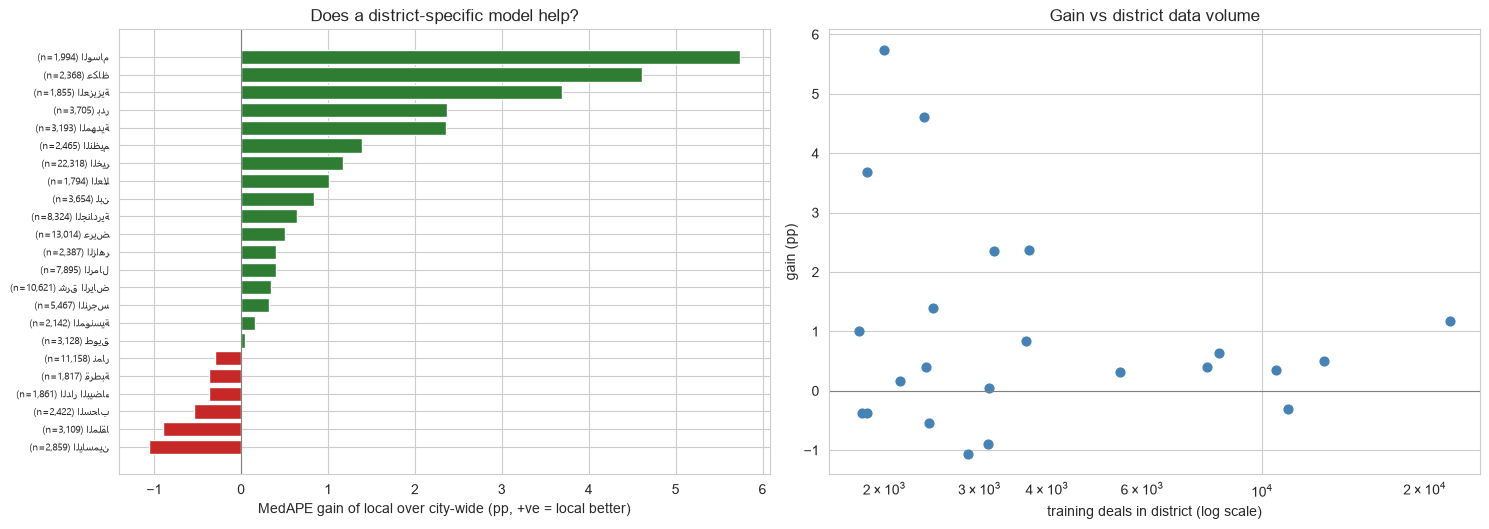

district,train_deals,test_deals,depth,MedAPE_local,MedAPE_citywide,gain_pp
الرياض/الوسام,"1,994",481,6,2.6,8.4,+5.74
الرياض/عكاظ,"2,368",667,6,11.8,16.4,+4.61
الرياض/العزيزية,"1,855",456,4,27.2,30.9,+3.69
الرياض/بدر,"3,705",971,4,18.2,20.6,+2.36
الرياض/المهدية,"3,193",815,4,20.8,23.2,+2.35
الرياض/النظيم,"2,465",613,4,15.1,16.5,+1.39


In [86]:
_y, _price = np.concatenate(ys), np.concatenate(ps)
pooled = pd.DataFrame([
    evaluate('Localised (per-district)', _y, np.concatenate(lp), _price, np.concatenate(sm)),
    evaluate('City-wide (single model)', _y, np.concatenate(cp), _price, cw_smear),
]).set_index('model')

print(f'pooled over the {len(_y):,} test deals in those districts:')
display(pooled[['RMSE_log', 'R2_log', 'MAPE_%', 'MedAPE_%', 'within_10%', 'within_20%', 'MAE_SAR']]
        .style.format({'RMSE_log': '{:.4f}', 'R2_log': '{:.4f}', 'MAPE_%': '{:.1f}',
                       'MedAPE_%': '{:.1f}', 'within_10%': '{:.1f}', 'within_20%': '{:.1f}',
                       'MAE_SAR': '{:,.0f}'}))

_w = int((loc['gain_pp'] > 0).sum())
print(f"local wins in {_w}/{len(loc)} districts   median gain {loc['gain_pp'].median():+.2f} pp   "
      f"best {loc['gain_pp'].max():+.2f} pp   worst {loc['gain_pp'].min():+.2f} pp")
print(f"correlation(district train deals, gain) = {loc['train_deals'].corr(loc['gain_pp']):+.3f}")

fig, ax = plt.subplots(1, 2, figsize=(15, 5.4))
o = loc.sort_values('gain_pp')
ax[0].barh(range(len(o)), o['gain_pp'], color=np.where(o['gain_pp'] > 0, '#2e7d32', '#c62828'))
ax[0].set_yticks(range(len(o)))
ax[0].set_yticklabels([ar(f"{d.split('/')[-1]} (n={n:,})")
                       for d, n in zip(o['district'], o['train_deals'])],
                      fontsize=7, fontfamily=AR_FONT)
ax[0].axvline(0, color='grey', lw=.8)
ax[0].set_xlabel('MedAPE gain of local over city-wide (pp, +ve = local better)')
ax[0].set_title('Does a district-specific model help?')

ax[1].scatter(loc['train_deals'], loc['gain_pp'], s=40, color='steelblue')
ax[1].axhline(0, color='grey', lw=.8); ax[1].set_xscale('log')
ax[1].set_xlabel('training deals in district (log scale)'); ax[1].set_ylabel('gain (pp)')
ax[1].set_title('Gain vs district data volume')
plt.tight_layout(); plt.show()

display(loc.head(6).style.format({'MedAPE_local': '{:.1f}', 'MedAPE_citywide': '{:.1f}',
                                  'gain_pp': '{:+.2f}', 'train_deals': '{:,.0f}',
                                  'test_deals': '{:,.0f}'}).hide(axis='index'))

In [87]:
from IPython.display import Markdown

# Section 6.5 narrative, generated from pooled and loc above. The verdict sentence is derived
# from the sign and size of the gain, so a re-run that reverses it rewrites the claim with it.
_p_loc = pooled.loc['Localised (per-district)']
_p_cw = pooled.loc['City-wide (single model)']
_dr2 = _p_loc['R2_log'] - _p_cw['R2_log']
_dmed = _p_cw['MedAPE_%'] - _p_loc['MedAPE_%']
_wins = int((loc['gain_pp'] > 0).sum())
_corr = loc['train_deals'].corr(loc['gain_pp'])
_n_te = int(loc['test_deals'].sum())
_worth = _dr2 >= 0.01 or _dmed >= 2.0
_verdict = ('**Localisation buys enough to be worth the cost, on the districts where it can be '
            'attempted.**' if _worth else
            '**Localisation buys very little, even where conditions favour it most.**')
_corr_read = ('more data does not predict a bigger win, which argues the gains are local '
              'idiosyncrasy rather than sample size' if abs(_corr) < 0.3 else
              'larger districts do tend to gain more, so sample size is part of the story')

display(Markdown(f"""{_verdict} Pooled over the {_n_te:,} test deals in the {len(loc)} districts, the per-district
models reach R2 {_p_loc['R2_log']:.4f} against {_p_cw['R2_log']:.4f} for the single city-wide
model, and MedAPE {_p_loc['MedAPE_%']:.1f}% against {_p_cw['MedAPE_%']:.1f}%. The whole gain is
{_dr2:.4f} of R2 and {_dmed:.1f} pp of MedAPE, on the part of the market with the most data to
learn from.

Per district, local wins {_wins} times out of {len(loc)}, median gain
{loc['gain_pp'].median():+.2f} pp, best {loc['gain_pp'].max():+.2f} pp, worst
{loc['gain_pp'].min():+.2f} pp. The distribution matters more than the count: most districts sit
within a fraction of a percentage point either way, and the pooled result is carried by a small
number of districts where local structure genuinely differs from the city average. The correlation
between a district's training volume and its gain is {_corr:+.2f} - {_corr_read}.

Weighed against the cost, this is not a trade worth making. The localised arm is {len(loc)}
models, each with its own depth search and refit, against one already-trained city-wide model - and
it still covers only {len(loc)} of {N_DISTRICTS_ALL} districts. **The city-wide CatBoost is the
right default:** it prices every district, it is within {_dmed:.1f} pp of MedAPE of the localised
arm on the districts where localisation can even be attempted, and it is a single artefact to
retrain each quarter. Localisation is worth revisiting only for the handful of districts with a
genuinely large, stable gain, and as a supplement to the city-wide model rather than a replacement
for it."""))

**Localisation buys very little, even where conditions favour it most.** Pooled over the 30,002 test deals in the 23 districts, the per-district
models reach R2 0.8215 against 0.8199 for the single city-wide
model, and MedAPE 14.6% against 15.2%. The whole gain is
0.0016 of R2 and 0.6 pp of MedAPE, on the part of the market with the most data to
learn from.

Per district, local wins 17 times out of 23, median gain
+0.40 pp, best +5.74 pp, worst
-1.07 pp. The distribution matters more than the count: most districts sit
within a fraction of a percentage point either way, and the pooled result is carried by a small
number of districts where local structure genuinely differs from the city average. The correlation
between a district's training volume and its gain is -0.14 - more data does not predict a bigger win, which argues the gains are local idiosyncrasy rather than sample size.

Weighed against the cost, this is not a trade worth making. The localised arm is 23
models, each with its own depth search and refit, against one already-trained city-wide model - and
it still covers only 23 of 208 districts. **The city-wide CatBoost is the
right default:** it prices every district, it is within 0.6 pp of MedAPE of the localised
arm on the districts where localisation can even be attempted, and it is a single artefact to
retrain each quarter. Localisation is worth revisiting only for the handful of districts with a
genuinely large, stable gain, and as a supplement to the city-wide model rather than a replacement
for it.

In [88]:
import json

board6.to_csv('model_comparison_all_with_mape.csv', encoding='utf-8-sig')
lag_board.to_csv('step6_lag_effect.csv', encoding='utf-8-sig')
lag_reps.to_csv('step6_lag_seeds.csv', index=False, encoding='utf-8-sig')
lag_summary.to_csv('step6_lag_seed_summary.csv', encoding='utf-8-sig')
cv.to_csv('step6_cv_folds.csv', index=False, encoding='utf-8-sig')
cv_summary.to_csv('step6_cv_summary.csv', encoding='utf-8-sig')
shap_global.to_csv('step6_shap_global.csv', encoding='utf-8-sig')
shap_local.to_csv('step6_shap_local.csv', encoding='utf-8-sig')
loc.to_csv('step6_localised_vs_citywide.csv', index=False, encoding='utf-8-sig')
pooled.to_csv('step6_localised_pooled.csv', encoding='utf-8-sig')

# ---------------------------------------------------------------------------
# results_manifest.json - one machine-readable record of every number the write-up
# quotes, so the chapter, the figures and the notebook can be checked against a single
# source rather than against each other. check_consistency.py reads this file.
# ---------------------------------------------------------------------------
_hx = hedonic_index.set_index('yq')
_lad = ladder_df[~ladder_df.index.str.startswith('X')]

manifest = {
    'sample': {
        'clean_rows': int(len(pd.read_csv('riyadh_clean.csv', usecols=['ref']))),
        'model_rows': int(len(df)),
        'train': int(len(train)), 'valid': int(len(valid)), 'test': int(len(test)),
        'full_train_valid': int(len(full)),
        'districts': int(df['district_key'].nunique()),
        'oot_train': int((df['year'] <= 2023).sum()), 'oot_test': int((df['year'] == 2025).sum()),
    },
    'models': {
        'ols_parsimonious_k': int(ols_p['k']),
        'ols_saturated_k': int(k_ols),
        'ols_ladder_final_k_train_only': int(_lad['k'].iloc[-1]),
        'ols_ladder_final_test_r2_train_only': float(_lad['test_R2'].iloc[-1]),
        'xgb_baseline_depth': int(xgb.get_params()['max_depth']),
        'xgb_tuned_depth': int(BEST_DEPTH),
        'xgb_tuned_min_child_weight': int(BEST_MCW),
        'xgb_tuned_rounds': int(BEST_ROUNDS),
        'xgb_tuned_fitted_on': 'train+valid',
        'cat_baseline_depth': int(cat.get_params()['depth']),
        'cat_tuned_depth': int(cb_best['depth']),
        'cat_tuned_l2': float(cb_best['l2_leaf_reg']),
        'cat_tuned_iterations': 6000,
        'cat_tuned_fitted_on': 'train+valid',
        'ols_saturated_fitted_on': 'train+valid',
    },
    'smearing_factors': {k: float(v) for k, v in S.items()},
    'random_split': board6.round(6).to_dict(orient='index'),
    'out_of_time_baseline': oot_old.round(6).to_dict(orient='index'),
    'out_of_time_tuned': oot_new.round(6).to_dict(orient='index'),
    'out_of_time_price_level_bias_pct': {k: float(v) for k, v
                                         in oot_bias.iloc[:, 0].round(4).items()},
    'cross_validation': cv_summary.round(6).to_dict(orient='index'),
    'lag_seeds': lag_summary.drop(columns=['sign_holds']).round(6).to_dict(orient='index'),
    'lag_sign_holds': {k: bool(v) for k, v in lag_summary['sign_holds'].items()},
    'lag_seed_list': list(LAG_SEEDS),
    'localised': {
        'min_deals': int(MIN_DEALS_LOC),
        'n_districts_modelled': int(len(loc)),
        'n_districts_total': int(N_DISTRICTS_ALL),
        'test_deals_covered': int(loc['test_deals'].sum()),
        'wins': int((loc['gain_pp'] > 0).sum()),
        'median_gain_pp': float(loc['gain_pp'].median()),
        'best_gain_pp': float(loc['gain_pp'].max()),
        'worst_gain_pp': float(loc['gain_pp'].min()),
        'corr_deals_gain': float(loc['train_deals'].corr(loc['gain_pp'])),
        'pooled': pooled.round(6).to_dict(orient='index'),
    },
    'hedonic_index': {
        'peak_quarter': str(_hx['index'].idxmax()),
        'peak_value': float(_hx['index'].max()),
        'raw_peak_quarter': str(_hx['raw_index'].idxmax()),
        'raw_peak_value': float(_hx['raw_index'].max()),
    },
    'shap_global': shap_global.round(6).to_dict(orient='index'),
    'spec_ladder': ladder_df.round(6).to_dict(orient='index'),
    'xgb_depth_sweep': sweep_df.round(6).to_dict(orient='records'),
    'cat_depth_sweep': cb_sweep_df.round(6).to_dict(orient='records'),
}
with open('results_manifest.json', 'w', encoding='utf-8') as fh:
    json.dump(manifest, fh, ensure_ascii=False, indent=2, default=float)


# --- derived quantities the write-up quotes in prose rather than in a table. They are
# recomputed here rather than left to be retyped, so check_consistency.py can verify them.
_lad_p = ladder_df[~ladder_df.index.str.startswith('X')]
_rs, _ob, _on = board6, oot_old, oot_new
_pl, _pc = pooled.loc['Localised (per-district)'], pooled.loc['City-wide (single model)']

manifest['derived'] = {
    'records_before_area_trim': int(len(pd.read_csv('riyadh_clean.csv', usecols=['ref']))),
    'ladder_delta_k': {i: int(v) for i, v in _lad_p['k'].diff().dropna().items()},
    'ladder_delta_test_r2': {i: float(v) for i, v in _lad_p['test_R2'].diff().dropna().items()},
    'r2_gap_xgb_minus_ols': float(_rs.loc['XGBoost tuned', 'R2_log']
                                  - _rs.loc['OLS saturated', 'R2_log']),
    'medape_gap_ols_minus_xgb': float(_rs.loc['OLS saturated', 'MedAPE_%']
                                      - _rs.loc['XGBoost tuned', 'MedAPE_%']),
    'r2_gap_xgb_minus_cat': float(_rs.loc['XGBoost tuned', 'R2_log']
                                  - _rs.loc['CatBoost tuned', 'R2_log']),
    'oot_r2_fall': {k: float(_rs.loc[r, 'R2_log'] - _on.loc[o, 'R2_log'])
                    for k, r, o in [('XGBoost', 'XGBoost tuned', 'XGBoost tuned'),
                                    ('CatBoost', 'CatBoost tuned', 'CatBoost tuned'),
                                    ('OLS', 'OLS saturated', 'OLS trend (tuned-era)')]},
    'oot_tuning_effect': {
        'XGBoost': float(_on.loc['XGBoost tuned', 'R2_log'] - _ob.loc['XGBoost', 'R2_log']),
        'CatBoost': float(_on.loc['CatBoost tuned', 'R2_log'] - _ob.loc['CatBoost', 'R2_log'])},
    'district_fe_with_se': int(len(ols['levels'])),
    'localised_min_deals': int(MIN_DEALS_LOC),
    'localised_rows_covered': int(_vc[districts].sum()),
    'localised_rows_pct': float(_vc[districts].sum() / len(df) * 100),
    'localised_test_deals': int(loc['test_deals'].sum()),
    'localised_test_pct': float(loc['test_deals'].sum() / len(test) * 100),
    'localised_r2_gain': float(_pl['R2_log'] - _pc['R2_log']),
    'localised_medape_gain_pp': float(_pc['MedAPE_%'] - _pl['MedAPE_%']),
    'hedonic_peak_multiple': float(_hx['index'].max() / 100),
    'hedonic_raw_at_hedonic_peak': float(_hx.loc[_hx['index'].idxmax(), 'raw_index'] / 100),
    'raw_peak_multiple': float(_hx['raw_index'].max() / 100),
    'hedonic_at_raw_peak': float(_hx.loc[_hx['raw_index'].idxmax(), 'index'] / 100),
    'cv_sd_max': float(cv_summary['R2_log std'].max()),
    'cv_sd_min': float(cv_summary['R2_log std'].min()),
}

# --- every results CSV, embedded verbatim. This is what lets check_consistency.py tell a
# number the code produced from one that was typed into the document and never revisited.
manifest['csv'] = {}
for _f in ['model_comparison_all_with_mape.csv', 'model_significance_tests.csv',
           'error_by_price_band.csv', 'error_by_property_type.csv',
           'oot_price_level_bias.csv', 'model_comparison_out_of_time.csv',
           'step6_cv_folds.csv', 'step6_cv_summary.csv', 'step6_lag_seeds.csv',
           'step6_lag_seed_summary.csv', 'step6_shap_global.csv',
           'step6_localised_vs_citywide.csv', 'step6_localised_pooled.csv',
           'hedonic_price_index.csv', 'ols_spec_ladder.csv', 'xgb_depth_sweep.csv',
           'catboost_depth_sweep.csv']:
    if os.path.exists(_f):
        manifest['csv'][_f] = pd.read_csv(_f, encoding='utf-8-sig').to_dict(orient='records')

with open('results_manifest.json', 'w', encoding='utf-8') as fh:
    json.dump(manifest, fh, ensure_ascii=False, indent=2, default=float)
print(f"results_manifest.json rewritten with {len(manifest['derived'])} derived values "
      f"and {len(manifest['csv'])} embedded tables")

print('saved: model_comparison_all_with_mape.csv, step6_lag_effect.csv,')
print('       step6_lag_seeds.csv, step6_lag_seed_summary.csv,')
print('       step6_cv_folds.csv, step6_cv_summary.csv, step6_shap_global.csv,')
print('       step6_shap_local.csv, step6_localised_vs_citywide.csv, step6_localised_pooled.csv')
print('       results_manifest.json  <- single source of truth for the chapter and figures')

results_manifest.json rewritten with 22 derived values and 17 embedded tables
saved: model_comparison_all_with_mape.csv, step6_lag_effect.csv,
       step6_lag_seeds.csv, step6_lag_seed_summary.csv,
       step6_cv_folds.csv, step6_cv_summary.csv, step6_shap_global.csv,
       step6_shap_local.csv, step6_localised_vs_citywide.csv, step6_localised_pooled.csv
       results_manifest.json  <- single source of truth for the chapter and figures


## Closing summary

In [89]:
from IPython.display import Markdown

# Closing summary, generated from the tables the notebook has already produced: board (5.1),
# cv_summary (6.3), oot_new (5.6), lag_summary (6.2), pooled and loc (6.5), hedonic_index (3.1)
# and shap_global (6.4). Every figure below is read from one of those objects rather than typed,
# for the same reason the section narratives are - a hand-written summary is the one cell that can
# quietly fall out of step after a re-run, and being the last thing a reader sees it is the worst
# place for that to happen. The verdicts in points 4 and 6 are derived from the numbers too, so a
# re-run that reverses a sign rewrites the claim with it rather than leaving it stranded.

# --- 1. in period
_RS_MAP = {'XGBoost tuned': 'XGBoost', 'CatBoost tuned': 'CatBoost',
           'OLS saturated': 'saturated OLS'}
_RS = list(_RS_MAP)
_rs_txt = ', '.join(f"{board.loc[k, 'R2_log']:.3f} ({v})" for k, v in _RS_MAP.items())
_blend = board.loc['Blend (3 tuned)', 'R2_log']
_cv_sd = cv_summary['R2_log std'].max()
_cv_mean = cv_summary['R2_log mean'].max()

# --- 2. out of time (same out-of-time -> random-split pairing Section 5.6 uses)
_PAIRS2 = [('XGBoost tuned', 'XGBoost tuned'), ('CatBoost tuned', 'CatBoost tuned'),
           ('OLS trend (tuned-era)', 'OLS saturated')]
_ot_txt = ', '.join(f"{oot_new.loc[o, 'R2_log']:.3f} ({o.split('(')[0].strip()})"
                    for o, _ in _PAIRS2)
_fall = [board.loc[r, 'R2_log'] - oot_new.loc[o, 'R2_log'] for o, r in _PAIRS2]
_BOOST = ['XGBoost tuned', 'CatBoost tuned']
_med_rs = board.loc[_RS, 'MedAPE_%'].min()
_med_ot = oot_new.loc[_BOOST, 'MedAPE_%'].min()
_w20_rs = board.loc[_RS, 'within_20%'].max()
_w20_ot = oot_new.loc[_BOOST, 'within_20%'].max()

# --- 3. operating envelope
_plan_r2 = oot_new.loc[_BOOST, 'R2_log'].mean()
_plan_lo = oot_new.loc[_BOOST, 'MedAPE_%'].min()
_plan_hi = oot_new.loc[_BOOST, 'MedAPE_%'].max()
_head_r2 = board.loc[_RS, 'R2_log'].max()

# --- 4. the two Step 6 extensions
_lr, _lo = lag_summary.loc['random split'], lag_summary.loc['out of time']
_fold_sd = cv_summary.loc['XGBoost tuned', 'R2_log std']
_ratio = _fold_sd / max(abs(_lr['dR2_mean']), 1e-9)
_rs_verdict = ('consistent in sign across the seeds' if _lr['sign_holds']
               else 'not even consistent in sign across the seeds')
_ot_dir = 'an increase' if _lo['dR2_mean'] > 0 else 'a decrease'
_ot_verdict = ('a change that survives the seed spread' if
               (_lo['|dR2|/noise'] >= 1.0 and _lo['sign_holds'])
               else f'{_ot_dir} that cannot be told apart from run-to-run variation')
_loc_r2 = (pooled.loc['Localised (per-district)', 'R2_log']
           - pooled.loc['City-wide (single model)', 'R2_log'])
_loc_med = (pooled.loc['City-wide (single model)', 'MedAPE_%']
            - pooled.loc['Localised (per-district)', 'MedAPE_%'])
_n_loc, _n_dist = len(loc), df['district_key'].nunique()

# --- 5. reproducibility floor
_seed_sd = lag_summary['R2_base_sd'].max()

# --- 6. what holds up
_h = hedonic_index.set_index('yq')
_hq = _h['index'].idxmax()          # the hedonic index's own peak quarter
_rq = _h['raw_index'].idxmax()      # the raw median's peak quarter - not necessarily the same one
_shap2 = shap_global.mean(axis=1).sort_values(ascending=False).head(2).index.tolist()
_agree = all(set(shap_global[c].nlargest(2).index) == set(_shap2) for c in shap_global.columns)
_shap_txt = (f"confirms both boosters lean on the same two features, `{_shap2[0]}` and "
             f"`{_shap2[1]}`, in the same direction, which is what a hedonic reading would predict."
             if _agree else
             f"puts `{_shap2[0]}` and `{_shap2[1]}` top on average, but the two boosters do not "
             f"pick the same pair, so the attribution is less clean than a hedonic reading "
             f"would predict.")
_peak_txt = (f"(The raw median peaks higher still, at {_h.loc[_rq, 'raw_index'] / 100:.2f}x in "
             f"{_rq}, a quarter in which the hedonic index has already fallen back to "
             f"{_h.loc[_rq, 'index'] / 100:.2f}x - the two series do not even peak in the same "
             f"place.) " if _rq != _hq else
             f"(Both series peak in the same quarter, {_hq}, so the gap is a level difference "
             f"rather than a timing one.) ")

display(Markdown(f"""**1. In period, the three model families end up close together, and further tuning is hitting a
data ceiling.** On the random 80/20 split - with all three fitted on the same train+validation
sample, so the comparison reflects the models rather than how much data each was given - the tuned
models reach R2 {_rs_txt}, with a three-model blend at {_blend:.3f}. Five-fold CV in 6.3 puts the
best fold mean at {_cv_mean:.3f} and shows these are stable to about +/-{_cv_sd:.3f}. The
remaining error is dominated by what the MOJ file does not record - no subtype, rooms, age or
condition - so a bare plot and a finished villa of the same size in the same district are the same
row to every model here.

**2. Out of time, performance drops sharply, and this is the result the project should be judged
on.** Trained on 2020-23 and asked to price 2025, the same recipes fall to R2 {_ot_txt} - a loss of
{min(_fall):.3f} to {max(_fall):.3f} of R2. MedAPE rises from about {_med_rs:.0f}% to about
{_med_ot:.0f}%, and the share of deals priced within 20% falls from ~{_w20_rs:.0f}% to
~{_w20_ot:.0f}%. The failure is one of *level*, not scatter: the tree models under-price 2025
because they cannot split past the largest `t` they were trained on, while the one specification
that can extrapolate overshoots. The 2024 gap in the source data makes this materially worse than a
normal one-year-ahead task would be.

**3. The two findings together set the operating envelope - and they answer different questions.**
The random split and the five-fold CV both hold out a random slice of a period the model has
already seen, so they measure general model quality: how much of the variation in price the
features explain, and how stable that answer is. They are the right basis for choosing between
specifications, and that is all they are used for here. The 2025 out-of-time test is the only
design in the notebook that reproduces what a deployed model faces - pricing deals that all
happened after everything it learned from - so it is the one to read as a forecasting expectation.
Section 5.0 sets the distinction out in full. In practice: quote R2 ~{_plan_r2:.1f} and MedAPE
~{_plan_lo:.0f}-{_plan_hi:.0f}% for a year the model has not seen, not the ~{_head_r2:.2f} and
~{_med_rs:.0f}% from the headline table; retrain every quarter so the extrapolation distance stays
at one quarter; and treat the model as a comparator against recent local evidence rather than as a
standalone forecaster of the market level.

**4. Both robustness extensions in Step 6 came back negative, and are reported as such.** The
district median price lag (6.2) changes random-split R2 by {_lr['dR2_mean']:+.4f} +/-
{_lr['dR2_sd']:.4f} over {int(_lr['n'])} seeds - {_rs_verdict}, and about {_ratio:.0f}x smaller
than the fold-to-fold sd - and out of time changes it by {_lo['dR2_mean']:+.4f} +/-
{_lo['dR2_sd']:.4f}, {_ot_verdict}. Those are stability figures, not significance tests:
{int(_lr['n'])} refits of one model on one dataset cannot support a hypothesis test, and are not
asked to. Per-district localisation (6.5) gains {_loc_r2:.4f} of R2 and {_loc_med:.1f} pp of
MedAPE, and only on the {_n_loc} of {_n_dist} districts with enough deals to fit a local model.
Neither is carried into a headline model.

**5. A methodological caution the numbers forced.** XGBoost's `hist` builder is not
bit-deterministic, and on the out-of-time task refitting the identical configuration moves R2 by
sd {_seed_sd:.4f}. Several comparisons in this notebook are smaller than that, so single-fit
differences at the third decimal place mean nothing. Section 6.2 uses repeated seeds and reports a
mean and spread for this reason, and Section 4.4 breaks near-ties in the depth sweep towards the
shallower tree rather than letting an unstable argmax pick the reported hyperparameter. CatBoost
and the OLS path reproduce exactly and need no such treatment.

**6. What does hold up.** The constant-quality hedonic index (3.1) separates
{_h.loc[_hq, 'index'] / 100:.2f}x of genuine price growth to the {_hq} peak from the
{_h.loc[_hq, 'raw_index'] / 100:.2f}x the raw median shows in that same quarter - that gap is
composition, and it is the most defensible output in the notebook. {_peak_txt}District premiums come
with standard errors. SHAP (6.4) {_shap_txt}"""))

**1. In period, the three model families end up close together, and further tuning is hitting a
data ceiling.** On the random 80/20 split - with all three fitted on the same train+validation
sample, so the comparison reflects the models rather than how much data each was given - the tuned
models reach R2 0.802 (XGBoost), 0.797 (CatBoost), 0.775 (saturated OLS), with a three-model blend at 0.801. Five-fold CV in 6.3 puts the
best fold mean at 0.796 and shows these are stable to about +/-0.004. The
remaining error is dominated by what the MOJ file does not record - no subtype, rooms, age or
condition - so a bare plot and a finished villa of the same size in the same district are the same
row to every model here.

**2. Out of time, performance drops sharply, and this is the result the project should be judged
on.** Trained on 2020-23 and asked to price 2025, the same recipes fall to R2 0.526 (XGBoost tuned), 0.458 (CatBoost tuned), 0.454 (OLS trend) - a loss of
0.276 to 0.339 of R2. MedAPE rises from about 17% to about
29%, and the share of deals priced within 20% falls from ~57% to
~35%. The failure is one of *level*, not scatter: the tree models under-price 2025
because they cannot split past the largest `t` they were trained on, while the one specification
that can extrapolate overshoots. The 2024 gap in the source data makes this materially worse than a
normal one-year-ahead task would be.

**3. The two findings together set the operating envelope - and they answer different questions.**
The random split and the five-fold CV both hold out a random slice of a period the model has
already seen, so they measure general model quality: how much of the variation in price the
features explain, and how stable that answer is. They are the right basis for choosing between
specifications, and that is all they are used for here. The 2025 out-of-time test is the only
design in the notebook that reproduces what a deployed model faces - pricing deals that all
happened after everything it learned from - so it is the one to read as a forecasting expectation.
Section 5.0 sets the distinction out in full. In practice: quote R2 ~0.5 and MedAPE
~29-31% for a year the model has not seen, not the ~0.80 and
~17% from the headline table; retrain every quarter so the extrapolation distance stays
at one quarter; and treat the model as a comparator against recent local evidence rather than as a
standalone forecaster of the market level.

**4. Both robustness extensions in Step 6 came back negative, and are reported as such.** The
district median price lag (6.2) changes random-split R2 by +0.0005 +/-
0.0003 over 5 seeds - consistent in sign across the seeds, and about 6x smaller
than the fold-to-fold sd - and out of time changes it by -0.0051 +/-
0.0150, a decrease that cannot be told apart from run-to-run variation. Those are stability figures, not significance tests:
5 refits of one model on one dataset cannot support a hypothesis test, and are not
asked to. Per-district localisation (6.5) gains 0.0016 of R2 and 0.6 pp of
MedAPE, and only on the 23 of 208 districts with enough deals to fit a local model.
Neither is carried into a headline model.

**5. A methodological caution the numbers forced.** XGBoost's `hist` builder is not
bit-deterministic, and on the out-of-time task refitting the identical configuration moves R2 by
sd 0.0073. Several comparisons in this notebook are smaller than that, so single-fit
differences at the third decimal place mean nothing. Section 6.2 uses repeated seeds and reports a
mean and spread for this reason, and Section 4.4 breaks near-ties in the depth sweep towards the
shallower tree rather than letting an unstable argmax pick the reported hyperparameter. CatBoost
and the OLS path reproduce exactly and need no such treatment.

**6. What does hold up.** The constant-quality hedonic index (3.1) separates
2.69x of genuine price growth to the 2025Q2 peak from the
3.98x the raw median shows in that same quarter - that gap is
composition, and it is the most defensible output in the notebook. (The raw median peaks higher still, at 4.12x in 2025Q4, a quarter in which the hedonic index has already fallen back to 2.35x - the two series do not even peak in the same place.) District premiums come
with standard errors. SHAP (6.4) confirms both boosters lean on the same two features, `district_key` and `log_area`, in the same direction, which is what a hedonic reading would predict.